In [1]:
# ============================================================
# PASO 1. INSTALAR LIBRERÍAS, IMPORTAR PAQUETES Y CARGAR ONTOLOGÍA
# ============================================================

# Instalar solo si estás en Colab
!pip install rdflib sentence-transformers tqdm openpyxl -q

import pandas as pd
import re
import os
from pathlib import Path

from rdflib import Graph, RDF, OWL, Namespace
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm

# ------------------------------------------------------------
# 1. Configurar rutas del proyecto
# ------------------------------------------------------------

BASE_DIR = Path("/content")

ontology_path = BASE_DIR / "ontologyv4.rdf"

output_dir = BASE_DIR / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Cargar ontología OWL/RDF
# ------------------------------------------------------------

g = Graph()

try:
    g.parse(str(ontology_path))
    print("Ontología cargada correctamente.")
    print("Total de triples en la ontología:", len(g))

except FileNotFoundError:
    raise FileNotFoundError(
        f"No se encontró el archivo de ontología en la ruta: {ontology_path}"
    )

except Exception as e:
    raise RuntimeError(
        f"Error inesperado al cargar la ontología: {e}"
    )

# ------------------------------------------------------------
# 3. Namespace principal de la ontología
# ------------------------------------------------------------

NS = Namespace("http://www.example.org/ontosocialdebt#")

print("Namespace configurado:", NS)
print("Carpeta de salida:", output_dir)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 3.9 MB/s eta 0:00:00
Ontología cargada correctamente.
Total de triples en la ontología: 4884
Namespace configurado: http://www.example.org/ontosocialdebt#
Carpeta de salida: /content/outputs


In [2]:
# ============================================================
# PASO 2. VALIDAR ESTRUCTURA DE CLASES DE LA ONTOLOGÍA
# ============================================================

classes = sorted(
    set(
        str(c).split("#")[-1]
        for c in g.subjects(RDF.type, OWL.Class)
    )
)

print("Total de clases OWL encontradas:", len(classes))

print("\nClases OWL detectadas:")

for c in classes:
    print("-", c)

Total de clases OWL encontradas: 46

Clases OWL detectadas:
- AdministrativeCause
- AdministrativeEffect
- AdministrativePStrategy
- AdministrativeStrategy
- Cause
- CollaborationCause
- CollaborationMode
- CollaborationStrategy
- CommunicationCause
- CommunicationStrategy
- CongruenceCause
- CongruenceStrategy
- CoordinationCause
- CoordinationStrategy
- CorrectiveStrategy
- Effect
- Group
- GroupEffect
- GroupStrategy
- Indicator
- IndividualEffect
- IndividualStrategy
- IntervalScale
- LevelExperience
- Location
- Measure
- MeasurementProcess
- Metric
- NominalScale
- OrdinalScale
- Organization
- OrganizationalUnit
- PerformsRole
- Person
- PreventiveStrategy
- ProjectManagementEffect
- ProjectManagementStrategy
- RatioScale
- Risk
- Role
- Scale
- ScaleType
- Strategy
- SubOrganization
- TechnicalEffect
- TechnicalStrategy


In [3]:
# ============================================================
# PASO 3. EXTRAER MICROCAUSAS ONTOLÓGICAS
# ============================================================

def normalize(text):
    """
    Normaliza textos para su posterior comparación semántica.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ------------------------------------------------------------
# 1. Definir tipos OWL válidos de microcausa
# ------------------------------------------------------------

CAUSE_TYPES = {
    "AdministrativeCause",
    "CommunicationCause",
    "CoordinationCause",
    "CollaborationCause",
    "CongruenceCause"
}

rows = []

# ------------------------------------------------------------
# 2. Recorrer individuos RDF de tipo causa
# ------------------------------------------------------------

for subject, _, rdf_type in g.triples(
    (None, RDF.type, None)
):

    type_name = str(rdf_type).split("#")[-1]

    # Ignorar individuos que no sean causas
    if type_name not in CAUSE_TYPES:
        continue

    ontology_uri = str(subject)
    ontology_id = ontology_uri.split("#")[-1]

    # --------------------------------------------------------
    # 3. Recuperar propiedades ontológicas
    # --------------------------------------------------------

    cause_id = next(
        g.objects(subject, NS.hasCauseID),
        None
    )

    cause_name = next(
        g.objects(subject, NS.hasCauseName),
        None
    )

    cause_description = next(
        g.objects(subject, NS.hasCauseDescription),
        None
    )

    # --------------------------------------------------------
    # 4. Asignar valores por defecto
    # --------------------------------------------------------

    cause_id = (
        str(cause_id)
        if cause_id is not None
        else ontology_id
    )

    cause_name = (
        str(cause_name)
        if cause_name is not None
        else ontology_id.replace("_", " ")
    )

    cause_description = (
        str(cause_description)
        if cause_description is not None
        else ""
    )

    # --------------------------------------------------------
    # 5. Agregar microcausa al catálogo
    # --------------------------------------------------------

    rows.append({
        "ontology_uri": ontology_uri,
        "ontology_id": ontology_id,
        "cause_id": cause_id,
        "cause_name": cause_name,
        "cause_description": cause_description,
        "cause_type": type_name,
        "cause_name_clean": normalize(cause_name),
        "cause_description_clean": normalize(
            cause_description
        )
    })


# ------------------------------------------------------------
# 6. Crear catálogo de microcausas ontológicas
# ------------------------------------------------------------

ontology_causes_df = (
    pd.DataFrame(rows)
    .drop_duplicates(
        subset=["ontology_id"]
    )
    .sort_values(
        by=["cause_type", "ontology_id"]
    )
    .reset_index(drop=True)
)

print(
    "Total de microcausas ontológicas extraídas:",
    len(ontology_causes_df)
)


# ------------------------------------------------------------
# 7. Mostrar distribución por tipo de microcausa
# ------------------------------------------------------------

print("\nDistribución por tipo de microcausa:")

cause_type_distribution = (
    ontology_causes_df["cause_type"]
    .value_counts()
    .rename_axis("cause_type")
    .reset_index(name="count")
)

display(
    cause_type_distribution
)


# ------------------------------------------------------------
# 8. Mostrar vista previa del catálogo
# ------------------------------------------------------------

print("\nVista previa del catálogo de microcausas:")

display(
    ontology_causes_df.head(20)
)

Total de microcausas ontológicas extraídas: 47

Distribución por tipo de microcausa:


,cause_type,count
0,AdministrativeCause,14
1,CongruenceCause,10
2,CollaborationCause,9
3,CoordinationCause,8
4,CommunicationCause,6



Vista previa del catálogo de microcausas:


,ontology_uri,ontology_id,cause_id,cause_name,cause_description,cause_type,cause_name_clean,cause_description_clean
0,http://www.example.org/ontosocialdebt#ADM-002_...,ADM-002_LackOfDocumentation,ADM-002,Lack of Documentation,"Lack of Documentation occurs when project, pro...",AdministrativeCause,lack of documentation,lack of documentation occurs when project proc...
1,http://www.example.org/ontosocialdebt#ADM-003_...,ADM-003_LackOfStandardsOrBestPractices,ADM-003,Lack of standards or best practices,Lack of Standards or Best Practices occurs whe...,AdministrativeCause,lack of standards or best practices,lack of standards or best practices occurs whe...
2,http://www.example.org/ontosocialdebt#CA-001_L...,CA-001_LackOfCommunicationPlan,CA-001,Lack of Communication Plan,The absence or poor design of a communication ...,AdministrativeCause,lack of communication plan,the absence or poor design of a communication ...
3,http://www.example.org/ontosocialdebt#CA-003_L...,CA-003_LackOfFeedbackChannels,CA-003,Lack of Feedback Channels in Communication Act...,The absence of established and accessible feed...,AdministrativeCause,lack of feedback channels in communication act...,the absence of established and accessible feed...
4,http://www.example.org/ontosocialdebt#CA-004_N...,CA-004_NoKnowledgeTransferPolicy,CA-004,No Knowledge Transfer Policy in Communication ...,The lack of a formal knowledge transfer policy...,AdministrativeCause,no knowledge transfer policy in communication ...,the lack of a formal knowledge transfer policy...
5,http://www.example.org/ontosocialdebt#CA-005_B...,CA-005_BlockageDueToApprovalRequirements,CA-005,Blockage due to approval requirements,Work blockage caused by approval requirements ...,AdministrativeCause,blockage due to approval requirements,work blockage caused by approval requirements ...
6,http://www.example.org/ontosocialdebt#CA-006_U...,CA-006_UnclearRolesAndResponsibilities,CA-006,Unclear roles and responsibilities,"Lack of clarity regarding team roles, responsi...",AdministrativeCause,unclear roles and responsibilities,lack of clarity regarding team roles responsib...
7,http://www.example.org/ontosocialdebt#CA-007_I...,CA-007_InefficientOrganizationalProcesses,CA-007,Inefficient organizational processes,"Inefficient organizational procedures, workflo...",AdministrativeCause,inefficient organizational processes,inefficient organizational procedures workflow...
8,http://www.example.org/ontosocialdebt#CA-008_L...,CA-008_LackOfResources,CA-008,"Lack of resources (time, people, budget)","Insufficient availability of time, personnel, ...",AdministrativeCause,lack of resources time people budget,insufficient availability of time personnel bu...
9,http://www.example.org/ontosocialdebt#CA-009_C...,CA-009_ConstraintDueToTicketStatusForReview,CA-009,Constraint due to ticket status for review,Work progress is constrained because the ticke...,AdministrativeCause,constraint due to ticket status for review,work progress is constrained because the ticke...


In [4]:
# ============================================================
# PASO 4. CARGAR Y PREPARAR EL DATASET BASE
# ============================================================

dataset_path = BASE_DIR / "dataset_mapeo_limpio.xlsx"

# ------------------------------------------------------------
# 1. Cargar dataset
# ------------------------------------------------------------

try:
    df = pd.read_excel(dataset_path)

except FileNotFoundError:
    raise FileNotFoundError(
        f"No se encontró el dataset en la ruta: {dataset_path}"
    )

except Exception as e:
    raise RuntimeError(
        f"Error inesperado al cargar el dataset: {e}"
    )

# ------------------------------------------------------------
# 2. Revisar y eliminar columnas duplicadas
# ------------------------------------------------------------

duplicated_cols = (
    df.columns[
        df.columns.duplicated()
    ]
    .tolist()
)

print(
    "Columnas duplicadas detectadas:",
    duplicated_cols
)

if duplicated_cols:

    df = (
        df.loc[
            :,
            ~df.columns.duplicated()
        ]
        .copy()
    )

    print("Columnas duplicadas eliminadas.")

# ------------------------------------------------------------
# 3. Validar estructura mínima
# ------------------------------------------------------------

print("\nFilas del dataset:", len(df))

print("\nColumnas del dataset:")
print(df.columns.tolist())

required_cols = [
    "comment_body_clean_final",
    "final_cause_code",
    "final_cause_for_analysis"
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        "Faltan columnas necesarias en el dataset: "
        f"{missing_cols}"
    )

# ------------------------------------------------------------
# 4. Preparar macrocausa normalizada
# ------------------------------------------------------------

df["macro_cause_clean"] = (
    df["final_cause_for_analysis"]
    .apply(normalize)
)

# ------------------------------------------------------------
# 5. Revisar macrocausas presentes
# ------------------------------------------------------------

macrocausas_dataset = (
    df["final_cause_for_analysis"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

print(
    "\nTotal de macrocausas únicas en el dataset:",
    len(macrocausas_dataset)
)

for macrocausa in macrocausas_dataset:
    print("-", macrocausa)

# ------------------------------------------------------------
# 6. Mostrar distribución inicial de macrocausas
# ------------------------------------------------------------

print("\nDistribución inicial de macrocausas:")

display(
    df["final_cause_for_analysis"]
    .value_counts()
)

Columnas duplicadas detectadas: []

Filas del dataset: 4610

Columnas del dataset:
['repo', 'issue_number', 'comment_id', 'comment_author', 'comment_created_at', 'comment_body_raw', 'comment_body_clean_final', 'true_code', 'evaluable', 'match', 'final_cause_code', 'final_cause_for_analysis', 'predicted_code', 'predicted_label', 'Code_cause_llm', 'predicted_label_llm', 'Confidence_llm', 'Confidence', 'Requires_revision', 'State_prediction', 'Priority_rule_applied', 'rule_changed_llm']

Total de macrocausas únicas en el dataset: 8
- Technical complexity, compatibility, and system constraints
- No identifiable sociotechnical cause
- Communication and shared understanding breakdowns
- Knowledge, documentation, and standards deficiencies
- Coordination and workflow misalignment
- Resource, tooling, access, and validation dependencies
- Organizational and procedural workflow constraints
- Collaboration and interpersonal tensions

Distribución inicial de macrocausas:


,count
final_cause_for_analysis,
"Technical complexity, compatibility, and system constraints",1127
Coordination and workflow misalignment,1013
No identifiable sociotechnical cause,849
Communication and shared understanding breakdowns,564
"Resource, tooling, access, and validation dependencies",457
Organizational and procedural workflow constraints,293
"Knowledge, documentation, and standards deficiencies",234
Collaboration and interpersonal tensions,73


In [5]:
# ============================================================
# PASO 4.1. EXCLUIR CAUSAS NO IDENTIFICABLES
# ============================================================

# ------------------------------------------------------------
# 1. Normalizar código de macrocausa
# ------------------------------------------------------------

codigo_normalizado = (
    df["final_cause_code"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

# ------------------------------------------------------------
# 2. Normalizar etiqueta de macrocausa
# ------------------------------------------------------------

etiqueta_normalizada = (
    df["final_cause_for_analysis"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# 3. Identificar registros sin causa sociotécnica
# ------------------------------------------------------------

mask_no_identifiable = (
    codigo_normalizado.eq("H")
    |
    etiqueta_normalizada.eq(
        "no identifiable sociotechnical cause"
    )
)

# ------------------------------------------------------------
# 4. Separar registros excluidos y válidos
# ------------------------------------------------------------

df_no_identifiable = (
    df[
        mask_no_identifiable
    ]
    .copy()
    .reset_index(drop=True)
)

df_limpio = (
    df[
        ~mask_no_identifiable
    ]
    .copy()
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Mostrar resumen
# ------------------------------------------------------------

print("Registros originales:", len(df))
print(
    "No identificables excluidos:",
    len(df_no_identifiable)
)
print(
    "Registros válidos para el modelo:",
    len(df_limpio)
)

# ------------------------------------------------------------
# 6. Validar que no queden registros H
# ------------------------------------------------------------

remaining_h = (
    df_limpio["final_cause_code"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("H")
    .sum()
)

print(
    "Registros H restantes en df_limpio:",
    remaining_h
)

if remaining_h > 0:
    raise ValueError(
        "Todavía existen registros con código H en df_limpio."
    )

Registros originales: 4610
No identificables excluidos: 849
Registros válidos para el modelo: 3761
Registros H restantes en df_limpio: 0


In [6]:
# ============================================================
# PASO 4.2. ANÁLISIS EXPLORATORIO INICIAL DEL DATASET LIMPIO
# ============================================================

# ------------------------------------------------------------
# 1. Dimensiones del dataset limpio
# ------------------------------------------------------------

print("Dimensiones del dataset limpio:")
print(df_limpio.shape)

# ------------------------------------------------------------
# 2. Vista previa de columnas críticas
# ------------------------------------------------------------

preview_cols = [
    "comment_body_clean_final",
    "final_cause_for_analysis",
    "macro_cause_clean"
]

display(
    df_limpio[preview_cols]
    .head(10)
)

# ------------------------------------------------------------
# 3. Valores nulos en columnas críticas
# ------------------------------------------------------------

print("\nValores nulos en columnas críticas:")

display(
    df_limpio[preview_cols]
    .isnull()
    .sum()
)

# ------------------------------------------------------------
# 4. Distribución de macrocausas
# ------------------------------------------------------------

print("\nDistribución de macrocausas:")

display(
    df_limpio["final_cause_for_analysis"]
    .value_counts()
)

# ------------------------------------------------------------
# 5. Longitud de los comentarios
# ------------------------------------------------------------

df_limpio["comment_length"] = (
    df_limpio["comment_body_clean_final"]
    .fillna("")
    .astype(str)
    .str.len()
)

print("\nEstadísticas de longitud de comentarios:")

display(
    df_limpio["comment_length"]
    .describe()
)

# ------------------------------------------------------------
# 6. Duplicados por comment_id
# ------------------------------------------------------------

if "comment_id" in df_limpio.columns:

    print("\nDuplicados por comment_id:")

    print(
        df_limpio["comment_id"]
        .duplicated()
        .sum()
    )

else:

    print("\nNo existe la columna comment_id.")

Dimensiones del dataset limpio:
(3761, 23)


,comment_body_clean_final,final_cause_for_analysis,macro_cause_clean
0,yea\nvscode doesnt close the document for 3min...,"Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...
1,Diagnostics are computed by extensions and pus...,"Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...
2,"based on the quotation: ""It's up to the extens...","Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...
3,There is /inline_code which represents the sta...,"Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...
4,"based on the quotation: ""yea""\nbased on the qu...",Communication and shared understanding breakdowns,communication and shared understanding breakdowns
5,Also I don't understand why issue is closed. I...,Communication and shared understanding breakdowns,communication and shared understanding breakdowns
6,"based on the quotation: ""but in general, the f...","Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...
7,A GitHub user is mentioned.\nbased on the quot...,"Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...
8,"based on the quotation: ""these events doesn't ...","Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...
9,"based on the quotation: ""For c) and d) I can't...",Communication and shared understanding breakdowns,communication and shared understanding breakdowns



Valores nulos en columnas críticas:


,0
comment_body_clean_final,0
final_cause_for_analysis,0
macro_cause_clean,0



Distribución de macrocausas:


,count
final_cause_for_analysis,
"Technical complexity, compatibility, and system constraints",1127
Coordination and workflow misalignment,1013
Communication and shared understanding breakdowns,564
"Resource, tooling, access, and validation dependencies",457
Organizational and procedural workflow constraints,293
"Knowledge, documentation, and standards deficiencies",234
Collaboration and interpersonal tensions,73



Estadísticas de longitud de comentarios:


,comment_length
count,3761.000000
mean,444.980058
std,540.681094
min,13.000000
25%,150.000000
50%,282.000000
75%,555.000000
max,10890.000000



Duplicados por comment_id:
0


In [7]:
# ============================================================
# PASO 5. MAPEAR MACROCAUSAS A MICROCAUSAS CANDIDATAS OWL
# ============================================================

MACRO_TO_CANDIDATE_INDIVIDUALS = {

    "technical complexity compatibility and system constraints": [
        "COG-006_LackOfInterfaceClarification",
        "COG-007_TechnicalComplexityDueToDependencies",
        "COG-008_CompatibilityConstraints",
        "COG-010_PreservationOfPriorSystemBehavior",
        "COG-011_SystemConfigurationConstraints",
    ],

    "resource tooling access and validation dependencies": [
        "CA-008_LackOfResources",
        "CA-011_RequestForTechnicalValidationSupport",
        "CA-012_RepositoryAccessLimitation",
        "CA-013_InefficientOrInadequateTools",
    ],

    "organizational and procedural workflow constraints": [
        "CA-005_BlockageDueToApprovalRequirements",
        "CA-009_ConstraintDueToTicketStatusForReview",
        "CA-010_BlockageDueToTriageProcess",
        "CA-006_UnclearRolesAndResponsibilities",
        "CA-007_InefficientOrganizationalProcesses",
        "CA-001_LackOfCommunicationPlan",
        "CA-003_LackOfFeedbackChannels",
    ],

    "knowledge documentation and standards deficiencies": [
        "CA-004_NoKnowledgeTransferPolicy",
        "ADM-003_LackOfStandardsOrBestPractices",
        "COG-009_LackOfTechnicalDocumentation",
    ],

    "collaboration and interpersonal tensions": [
        "COL-003_InsufficientPeerSupport",
        "COL-004_LackOfCollaborationOrTeamwork",
        "COL-006_LackOfTrustAmongTeamMembers",
        "CL-001_LowSocialization",
        "CO-006_PerceivedUnfairnessInInteraction",
        "COG-004_LackOfPeerAcknowledgement",
        "COL-005_LackOfKnowledgeSharing",
    ],

    "coordination and workflow misalignment": [
        "COO-001_CentralizedDecisionMaking",
        "COO-002_RestrictedInformationFlow",
        "COO-003_UnilateralTaskAssignment",
        "COO-004_FrequentLeadershipConflicts",
        "COO-006_MiscommunicationInTaskHandover",
        "COO-008_CoordinationMisalignmentForTechnicalValidation",
        "COO-009_TaskReworkDueToMisalignment",
        "CR-001_LackOfTaskDiscussion",
    ],

    "communication and shared understanding breakdowns": [
        "CO-001_LanguageBarriers",
        "CO-002_DelayedCommunication",
        "CO-003_UnclearOrAmbiguousCommunication",
        "CO-004_LackOfTimelyFeedbackOrResponse",
        "CO-005_MisinterpretationOfInformation",
    ],
}

# ------------------------------------------------------------
# 1. Validar cobertura de macrocausas del dataset limpio
# ------------------------------------------------------------

dataset_macro_keys = set(
    df_limpio["macro_cause_clean"]
    .dropna()
    .astype(str)
    .tolist()
)

dictionary_macro_keys = set(
    MACRO_TO_CANDIDATE_INDIVIDUALS.keys()
)

missing_macro_keys = sorted(
    dataset_macro_keys - dictionary_macro_keys
)

print(
    "Total de macrocausas en el dataset:",
    len(dataset_macro_keys)
)

print(
    "Total de macrocausas en el diccionario:",
    len(dictionary_macro_keys)
)

print(
    "Macrocausas del dataset sin mapeo:",
    len(missing_macro_keys)
)

if missing_macro_keys:

    print("\nMacrocausas sin mapeo:")

    for key in missing_macro_keys:
        print("-", key)

else:

    print(
        "\nTodas las macrocausas del dataset "
        "tienen microcausas candidatas."
    )

# ------------------------------------------------------------
# 2. Validar existencia de microcausas candidatas en ontología
# ------------------------------------------------------------

ontology_ids = set(
    ontology_causes_df["ontology_id"]
    .astype(str)
    .tolist()
)

candidate_ids = set()

for ids in MACRO_TO_CANDIDATE_INDIVIDUALS.values():
    candidate_ids.update(ids)

missing_ids = sorted(
    candidate_ids - ontology_ids
)

print(
    "\nTotal de microcausas candidatas en el diccionario:",
    len(candidate_ids)
)

print(
    "Microcausas candidatas no encontradas en la ontología:",
    len(missing_ids)
)

if missing_ids:

    print("\nIDs no encontrados en la ontología:")

    for microcause_id in missing_ids:
        print("-", microcause_id)

else:

    print(
        "\nTodas las microcausas candidatas "
        "existen en la ontología."
    )

Total de macrocausas en el dataset: 7
Total de macrocausas en el diccionario: 7
Macrocausas del dataset sin mapeo: 0

Todas las macrocausas del dataset tienen microcausas candidatas.

Total de microcausas candidatas en el diccionario: 39
Microcausas candidatas no encontradas en la ontología: 0

Todas las microcausas candidatas existen en la ontología.


In [8]:
# ============================================================
# PASO 6. DEFINIR PALABRAS CLAVE SEMÁNTICAS POR MICROCAUSA
# ============================================================

CAUSE_KEYWORDS = {

    # --------------------------------------------------------
    # Recursos, herramientas, acceso y validación
    # --------------------------------------------------------

    "CA-008_LackOfResources":
        "resources capacity availability people time budget bandwidth "
        "unavailable insufficient shortage",

    "CA-011_RequestForTechnicalValidationSupport":
        "validation support expert review maintainer approval confirmation "
        "technical authority external validation blocked progress cannot continue",

    "CA-012_RepositoryAccessLimitation":
        "repository access repo permission permissions fork branch pull request "
        "access denied cannot push cannot trigger ci restricted access",

    "CA-013_InefficientOrInadequateTools":
        "tool tooling inadequate tools ci logs buildbot automation infrastructure "
        "dashboard monitoring test runner flaky tooling limitation",

    # --------------------------------------------------------
    # Comunicación
    # --------------------------------------------------------

    "CO-001_LanguageBarriers":
        "language dialect terminology vocabulary translation wording naming "
        "non native speaker unclear term linguistic barrier",

    "CO-002_DelayedCommunication":
        "delayed communication late update late reply waiting information "
        "delay response delay slow communication asynchronous delay",

    "CO-003_UnclearOrAmbiguousCommunication":
        "unclear ambiguous incomplete imprecise vague confusing lack context "
        "clarification not clear not sure what mean unclear instruction",

    "CO-004_LackOfTimelyFeedbackOrResponse":
        "feedback response reply no response unanswered follow up waiting review "
        "feedback missing response timely feedback",

    "CO-005_MisinterpretationOfInformation":
        "misinterpretation misunderstood wrong understanding interpreted differently "
        "intended meaning incorrect assumption misunderstood requirement",

    # --------------------------------------------------------
    # Conocimiento, documentación y estándares
    # --------------------------------------------------------

    "CA-004_NoKnowledgeTransferPolicy":
        "knowledge transfer policy knowledge retention handover policy onboarding "
        "policy knowledge management no transfer process",

    "ADM-003_LackOfStandardsOrBestPractices":
        "standards best practices guidelines conventions procedures coding standards "
        "review practices governance criteria consistency",

    "COG-009_LackOfTechnicalDocumentation":
        "technical documentation architecture component specification interface "
        "definition dependency information configuration details technical design decisions",

    # --------------------------------------------------------
    # Organización y flujo de trabajo
    # --------------------------------------------------------

    "CA-001_LackOfCommunicationPlan":
        "communication plan communication policy planned communication channels "
        "communication responsibilities communication process",

    "CA-003_LackOfFeedbackChannels":
        "feedback channels feedback loop feedback mechanism accessible feedback "
        "channel open communication early issue detection",

    "CA-005_BlockageDueToApprovalRequirements":
        "approval required approve blocked waiting approval merge permission "
        "authorization approval gate cannot proceed",

    "CA-006_UnclearRolesAndResponsibilities":
        "unclear roles unclear responsibilities ownership responsibility owner "
        "accountable role ambiguity who owns who responsible",

    "CA-007_InefficientOrganizationalProcesses":
        "inefficient process organizational process bureaucracy procedural delay "
        "process inefficiency administrative workflow slow process",

    "CA-009_ConstraintDueToTicketStatusForReview":
        "ticket status review status needs review needs tests needs improvement "
        "patch status blocked by status",

    "CA-010_BlockageDueToTriageProcess":
        "triage process awaiting triage accepted needs triage priority label "
        "triage blocked workflow",

    # --------------------------------------------------------
    # Complejidad técnica, compatibilidad y congruencia
    # --------------------------------------------------------

    "COG-006_LackOfInterfaceClarification":
        "interface clarification contract inputs outputs responsibilities component "
        "interaction api contract integration specification interface definition",

    "COG-007_TechnicalComplexityDueToDependencies":
        "dependencies dependency component module service tool external system "
        "technical complexity integration dependency chain coupling",

    "COG-008_CompatibilityConstraints":
        "compatibility backward compatibility backwards compatible api version "
        "platform database browser external component environment legacy behavior",

    "COG-010_PreservationOfPriorSystemBehavior":
        "preserve behavior prior behavior existing behavior expected functionality "
        "backward compatibility regression behavior change preserve expected behavior",

    "COG-011_SystemConfigurationConstraints":
        "configuration settings environment differences system behavior infrastructure "
        "dependency deployment configuration environment specific behavior config",

    # --------------------------------------------------------
    # Coordinación
    # --------------------------------------------------------

    "COO-001_CentralizedDecisionMaking":
        "centralized decision making leaders small group decision authority "
        "limited autonomy distributed coordination decision centralization",

    "COO-002_RestrictedInformationFlow":
        "restricted information flow limited information distribution information "
        "access visibility select members hidden information coordination",

    "COO-003_UnilateralTaskAssignment":
        "unilateral task assignment reassigned without consultation assigned "
        "without discussion task ownership imposed assignment",

    "COO-004_FrequentLeadershipConflicts":
        "leadership conflict leadership disputes disagreement leaders key positions "
        "project planning friction leadership tension",

    "COO-006_MiscommunicationInTaskHandover":
        "handover task handover ownership transfer responsibility transfer transition "
        "work item transfer incomplete handoff missing information during handover "
        "communication breakdown during handover coordination during handover",

    "COO-008_CoordinationMisalignmentForTechnicalValidation":
        "technical validation coordination validation timing validation criteria "
        "validation procedure validation responsibility misalignment",

    "COO-009_TaskReworkDueToMisalignment":
        "task execution inconsistent agreements misaligned expectations coordination "
        "decisions rework revise repeated work inconsistent responsibilities",

    "CR-001_LackOfTaskDiscussion":
        "task discussion requirements discussion responsibilities discussion "
        "implementation approach",

    # --------------------------------------------------------
    # Colaboración y tensiones interpersonales
    # --------------------------------------------------------

    "COL-003_InsufficientPeerSupport":
        "peer support help assistance support from peers teammate support "
        "insufficient support blocked without help",

    "COL-004_LackOfCollaborationOrTeamwork":
        "collaboration collaborative work isolated contributors independent work "
        "silos knowledge exchange joint activities shared decision making "
        "collaborative problem solving",

    "COL-005_LackOfKnowledgeSharing":
        "knowledge sharing exchange knowledge experience lessons learned technical "
        "information collective understanding sharing expertise",

    "COL-006_LackOfTrustAmongTeamMembers":
        "trust distrust reliability confidence skeptical hostile passive aggressive "
        "aggressive good faith bad faith intentions competence",

    "CL-001_LowSocialization":
        "rare interaction little interaction few discussions isolated contributors "
        "weak social ties low engagement minimal participation lack of regular communication",

    "CO-006_PerceivedUnfairnessInInteraction":
        "unfair unfairness unequal treatment bias biased double standard exclusion "
        "favoritism not fair unfair process",

    "COG-004_LackOfPeerAcknowledgement":
        "recognition acknowledgement appreciation credit credited contribution "
        "contributions effort achievements ideas not valued not recognized",
}

# ------------------------------------------------------------
# 1. Obtener todas las microcausas candidatas
# ------------------------------------------------------------

candidate_ids = set()

for microcause_ids in MACRO_TO_CANDIDATE_INDIVIDUALS.values():
    candidate_ids.update(microcause_ids)

# ------------------------------------------------------------
# 2. Validar cobertura de palabras clave
# ------------------------------------------------------------

ids_without_keywords = sorted(
    candidate_ids - set(CAUSE_KEYWORDS.keys())
)

unused_keyword_ids = sorted(
    set(CAUSE_KEYWORDS.keys()) - candidate_ids
)

print(
    "Total de microcausas candidatas OWL:",
    len(candidate_ids)
)

print(
    "Microcausas candidatas sin palabras clave:",
    len(ids_without_keywords)
)

if ids_without_keywords:

    print("\nMicrocausas candidatas sin palabras clave:")

    for microcause_id in ids_without_keywords:
        print("-", microcause_id)

else:

    print(
        "\nTodas las microcausas candidatas "
        "tienen palabras clave semánticas."
    )

print(
    "\nEntradas de palabras clave que no son candidatas:",
    len(unused_keyword_ids)
)

if unused_keyword_ids:

    for microcause_id in unused_keyword_ids:
        print("-", microcause_id)

Total de microcausas candidatas OWL: 39
Microcausas candidatas sin palabras clave: 0

Todas las microcausas candidatas tienen palabras clave semánticas.

Entradas de palabras clave que no son candidatas: 0


In [9]:
# ============================================================
# PASO 7. RECUPERAR MICROCAUSAS CANDIDATAS POR MACROCAUSA
# ============================================================

def get_candidate_causes(macro_label):
    """
    Recupera desde el catálogo ontológico las microcausas
    candidatas asociadas a una macrocausa.
    """

    # --------------------------------------------------------
    # 1. Validar macrocausa
    # --------------------------------------------------------

    if pd.isna(macro_label):
        return ontology_causes_df.iloc[0:0].copy()

    macro_key = normalize(macro_label)

    # --------------------------------------------------------
    # 2. Obtener IDs candidatos según el mapeo
    # --------------------------------------------------------

    candidate_ids = MACRO_TO_CANDIDATE_INDIVIDUALS.get(
        macro_key,
        []
    )

    if not candidate_ids:
        return ontology_causes_df.iloc[0:0].copy()

    # --------------------------------------------------------
    # 3. Recuperar candidatas desde el catálogo ontológico
    # --------------------------------------------------------

    candidate_df = (
        ontology_causes_df[
            ontology_causes_df["ontology_id"]
            .isin(candidate_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 4. Validar que todas las candidatas fueron recuperadas
    # --------------------------------------------------------

    found_ids = set(
        candidate_df["ontology_id"]
        .astype(str)
        .tolist()
    )

    expected_ids = set(candidate_ids)

    missing_runtime_ids = sorted(
        expected_ids - found_ids
    )

    if missing_runtime_ids:

        print(
            f"Advertencia: microcausas candidatas no recuperadas "
            f"para '{macro_label}':"
        )

        for microcause_id in missing_runtime_ids:
            print("-", microcause_id)

    # --------------------------------------------------------
    # 5. Ordenar resultado
    # --------------------------------------------------------

    candidate_df = (
        candidate_df
        .sort_values(
            by=["cause_type", "ontology_id"]
        )
        .reset_index(drop=True)
    )

    return candidate_df


print("PASO 7 cargado correctamente.")

PASO 7 cargado correctamente.


In [10]:
# ============================================================
# PASO 8. CARGAR MODELO SENTENCE-BERT
# ============================================================

MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

print("Cargando modelo Sentence-BERT...")

model = SentenceTransformer(MODEL_NAME)

print("Modelo cargado correctamente.")
print("Modelo utilizado:", MODEL_NAME)

# ------------------------------------------------------------
# Información del modelo
# ------------------------------------------------------------

embedding_dimension = model.get_sentence_embedding_dimension()

print("\nDimensión de los embeddings:", embedding_dimension)

Cargando modelo Sentence-BERT...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado correctamente.
Modelo utilizado: paraphrase-multilingual-MiniLM-L12-v2

Dimensión de los embeddings: 384


/tmp/ipykernel_6904/711260500.py:18: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dimension = model.get_sentence_embedding_dimension()


In [11]:
# ============================================================
# PASO 9. MODELO BASELINE (SBERT)
# Selección de una única microcausa mediante embeddings
# ============================================================

# ------------------------------------------------------------
# 1. Descripciones enriquecidas de cada macrocausa
# ------------------------------------------------------------

MACRO_CAUSE_DESCRIPTIONS = {

    "communication and shared understanding breakdowns": (
        "Communication and shared understanding breakdowns. "
        "This category refers to language barriers, delayed communication, unclear or ambiguous messages, "
        "missing feedback, lack of timely responses, and misinterpretation of shared information."
    ),

    "coordination and workflow misalignment": (
        "Coordination and workflow misalignment. "
        "This category refers to centralized decisions, restricted information flow, unilateral task assignment, "
        "leadership conflicts, lack of cross-team meetings, poor task handover, validation coordination problems, "
        "task execution based on inconsistent agreements, and lack of task discussion."
    ),

    "technical complexity, compatibility, and system constraints": (
        "Technical complexity, compatibility, and system constraints. "
        "This category refers to unclear interfaces, technical dependencies, compatibility constraints, "
        "preservation of prior system behavior, configuration settings, environment differences, and system-specific constraints."
    ),

    "organizational and procedural workflow constraints": (
        "Organizational and procedural workflow constraints. "
        "This category refers to approval requirements, ticket status constraints, triage bottlenecks, unclear roles, "
        "inefficient organizational processes, lack of communication planning, and missing feedback channels."
    ),

    "collaboration and interpersonal tensions": (
        "Collaboration and interpersonal tensions. "
        "This category refers to interpersonal friction, weak mutual support, limited joint work, "
        "reduced knowledge exchange, low trust, perceived unfairness, poor recognition of contributions, "
        "and reduced social participation among contributors."
    ),

    "knowledge, documentation, and standards deficiencies": (
        "Knowledge, documentation, and standards deficiencies. "
        "This category refers to lack of knowledge transfer policies, missing project or process documentation, "
        "lack of standards or best practices, and missing technical documentation about architecture, interfaces, "
        "dependencies, or technical decisions."
    ),

    "resource, tooling, access, and validation dependencies": (
        "Resource, tooling, access, and validation dependencies. "
        "This category refers to lack of resources, dependency on technical validation support, repository access limitations, "
        "inefficient or inadequate tools, and collaboration constraints due to repository access."
    ),


}


# ------------------------------------------------------------
# 2. Construir texto semántico de macrocausa
# ------------------------------------------------------------

def build_macro_semantic_text(macro_label):
    """
    Construye el texto semántico de la macrocausa.
    """
    macro_clean = normalize(macro_label)

    if macro_clean in MACRO_CAUSE_DESCRIPTIONS:
        return MACRO_CAUSE_DESCRIPTIONS[macro_clean]

    return str(macro_label)


# ------------------------------------------------------------
# 3. Limpiar comentario
# ------------------------------------------------------------

def clean_short_text(text, max_words=60):
    """
    Reduce el comentario a una evidencia textual breve.
    Evita contaminar el embedding con ruido, código o textos demasiado largos.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Eliminar URLs
    text = re.sub(r"http\S+", " ", text)

    # Eliminar comandos tipo /label, /retest, /workflow
    text = re.sub(r"/\w+", " ", text)

    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    return " ".join(words[:max_words])


# ------------------------------------------------------------
# 4. Construir texto híbrido comentario + macrocausa
# ------------------------------------------------------------

def build_comment_macro_semantic_text(comment_text, macro_label):
    """
    Construye una consulta semántica híbrida:
    comentario limpio + contexto de macrocausa.
    """

    short_comment = clean_short_text(comment_text)

    macro_text = build_macro_semantic_text(macro_label)

    return (
        "GitHub comment evidence:\n"
        f"{short_comment}\n\n"
        "Macro cause context:\n"
        f"{macro_text}"
    )


# ------------------------------------------------------------
# 5. Construir texto semántico de microcausa candidata
# ------------------------------------------------------------

def build_candidate_cause_text(candidate_row):
    """
    Construye el texto semántico de una microcausa candidata OWL.
    Combina nombre, descripción y keywords refinadas.
    """

    ontology_id = candidate_row["ontology_id"]

    keywords = CAUSE_KEYWORDS.get(
        ontology_id,
        ""
    )

    return " ".join([
        str(candidate_row["cause_name"]),
        str(candidate_row["cause_description"]),
        keywords
    ])


# ------------------------------------------------------------
# 6. Clasificador BASELINE macrocausa/comentario → microcausa
# ------------------------------------------------------------

def classify_specific_cause(macro_label, comment_text=None, threshold=0.50):
    """
    Selecciona la microcausa OWL más cercana usando embeddings.

    Si comment_text está disponible:
        comentario + macrocausa -> microcausa

    Si comment_text no está disponible:
        macrocausa -> microcausa

    Esto mantiene compatibilidad con pruebas macro-level,
    pero permite mayor discriminación cuando se procesan comentarios reales.
    """

    # Obtener candidatas según macrocausa
    candidates_df = get_candidate_causes(
        macro_label
    )

    if candidates_df.empty:

        return {
            "specific_cause_id": None,
            "specific_cause_name": None,
            "specific_cause_type": None,
            "similarity_score": 0.0,
            "classification_status": "no_candidates"
        }

    # Texto de consulta
    if comment_text is None:

        query_text = build_macro_semantic_text(
            macro_label
        )

    else:

        query_text = build_comment_macro_semantic_text(
            comment_text=comment_text,
            macro_label=macro_label
        )

    # Textos candidatos
    candidate_texts = [
        build_candidate_cause_text(candidate_row)
        for _, candidate_row in candidates_df.iterrows()
    ]

    # Embeddings
    query_embedding = model.encode(
        query_text,
        convert_to_tensor=True
    )

    candidate_embeddings = model.encode(
        candidate_texts,
        convert_to_tensor=True
    )

    # Similitud coseno
    scores = util.cos_sim(
        query_embedding,
        candidate_embeddings
    )[0]

    best_idx = scores.argmax().item()
    best_score = float(scores[best_idx].item())
    best_row = candidates_df.iloc[best_idx]

    # Baja confianza
    if best_score < threshold:

        return {
            "specific_cause_id": best_row["ontology_id"],
            "specific_cause_name": best_row["cause_name"],
            "specific_cause_type": best_row["cause_type"],
            "similarity_score": best_score,
            "classification_status": "mapped_low_confidence"
        }

    # Mapeo normal
    return {
        "specific_cause_id": best_row["ontology_id"],
        "specific_cause_name": best_row["cause_name"],
        "specific_cause_type": best_row["cause_type"],
        "similarity_score": best_score,
        "classification_status": "mapped"
    }


# ------------------------------------------------------------
# 7. Verificación rápida
# ------------------------------------------------------------

print("PASO 10 cargado correctamente.")

print("\nTexto semántico usado para Collaboration:")

print(
    build_macro_semantic_text(
        "Collaboration and interpersonal tensions"
    )
)

PASO 10 cargado correctamente.

Texto semántico usado para Collaboration:
Collaboration and interpersonal tensions. This category refers to interpersonal friction, weak mutual support, limited joint work, reduced knowledge exchange, low trust, perceived unfairness, poor recognition of contributions, and reduced social participation among contributors.


In [12]:
# ============================================================
# PASO 10. DEFINIR EL MODELO ADAPTATIVO TOP-K
# Embeddings SBERT, señales léxicas y selección de microcausas
# ============================================================


import re
import pandas as pd
from sentence_transformers import util

# ------------------------------------------------------------
# Parámetros globales del modelo
# ------------------------------------------------------------

DEFAULT_THRESHOLD = 0.28
DEFAULT_TOP_K = 3

DEFAULT_ALPHA = 0.10
DEFAULT_LEXICAL_WEIGHT = 0.20

MAX_SCORE_GAP = 0.18


# ------------------------------------------------------------
# Penalización suave para microcausas demasiado generales
# ------------------------------------------------------------

GENERIC_CAUSE_PENALTY = {

    "CL-001_LowSocialization": 0.020,

    "COL-004_LackOfCollaborationOrTeamwork": 0.020,

    "COG-007_TechnicalComplexityDueToDependencies": 0.015,

    "CO-003_UnclearOrAmbiguousCommunication": 0.015,

    "CA-005_BlockageDueToApprovalRequirements": 0.015,
}


# ------------------------------------------------------------
# Señales léxicas expertas
# ------------------------------------------------------------

LEXICAL_SIGNALS = {

    # --------------------------------------------------------
    # Communication
    # --------------------------------------------------------

    "CO-001_LanguageBarriers":[
        "language","translation","terminology","wording",
        "vocabulary","non native","mother tongue",
        "dialect","term"
    ],

    "CO-002_DelayedCommunication":[
        "late","delay","delayed","waiting",
        "no update","slow response",
        "sorry for the delay"
    ],

    "CO-003_UnclearOrAmbiguousCommunication":[
        "unclear","ambiguous","confusing",
        "not clear","clarify","clarification",
        "what do you mean","don't understand"
    ],

    "CO-005_MisinterpretationOfInformation":[
        "misunderstood",
        "misinterpret",
        "wrong understanding",
        "incorrect assumption"
    ],

    # --------------------------------------------------------
    # Technical
    # --------------------------------------------------------

    "COG-007_TechnicalComplexityDueToDependencies":[
        "dependency",
        "dependencies",
        "depends on",
        "component",
        "module",
        "integration",
        "external system"
    ],

    "COG-008_CompatibilityConstraints":[
        "compatibility",
        "backward compatibility",
        "backwards compatible",
        "version mismatch",
        "legacy",
        "api version",
        "browser",
        "database"
    ],

    "COG-011_SystemConfigurationConstraints":[
        "configuration",
        "config",
        "environment",
        "settings",
        "deployment",
        "runtime",
        "variable"
    ],

    # --------------------------------------------------------
    # Resource
    # --------------------------------------------------------

    "CA-011_RequestForTechnicalValidationSupport":[
        "validate",
        "validation",
        "review",
        "expert review",
        "maintainer",
        "confirm"
    ],

    "CA-012_RepositoryAccessLimitation":[
        "repository access",
        "access denied",
        "permission",
        "cannot push",
        "cannot trigger",
        "fork"
    ],

    "CA-013_InefficientOrInadequateTools":[
        "ci",
        "tool",
        "tooling",
        "dashboard",
        "logs",
        "buildbot",
        "automation",
        "flaky",
        "test failed",
        "job failed"
    ],

    # --------------------------------------------------------
    # Organizational
    # --------------------------------------------------------

    "CA-005_BlockageDueToApprovalRequirements":[
        "approval",
        "approve",
        "approved",
        "waiting approval",
        "cannot merge",
        "required review"
    ],

    "CA-007_InefficientOrganizationalProcesses":[
        "process",
        "workflow",
        "bureaucracy",
        "release process",
        "slow process"
    ],

    "CA-009_ConstraintDueToTicketStatusForReview":[
        "needs review",
        "ticket",
        "review status",
        "needs tests",
        "needs improvement"
    ],

    # --------------------------------------------------------
    # Coordination
    # --------------------------------------------------------

    "COO-002_RestrictedInformationFlow":[
        "restricted information",
        "hidden information",
        "information access",
        "not visible"
    ],

    "COO-006_MiscommunicationInTaskHandover":[
        "handover",
        "handoff",
        "transfer",
        "passed to",
        "take over"
    ],

    "COO-008_CoordinationMisalignmentForTechnicalValidation":[
        "technical validation",
        "validation responsibility",
        "validation timing",
        "approval criteria"
    ],

    "COO-009_TaskReworkDueToMisalignment":[
        "rework",
        "redo",
        "repeat",
        "revert",
        "reimplemented",
        "change requests",
        "rebase"
    ],

    "CR-001_LackOfTaskDiscussion":[
        "needs discussion",
        "task discussion",
        "requirements discussion"
    ],

    # --------------------------------------------------------
    # Collaboration
    # --------------------------------------------------------

    "CL-001_LowSocialization":[
        "little interaction",
        "rarely interact",
        "low engagement",
        "few discussions"
    ],

    "COL-003_InsufficientPeerSupport":[
        "need help",
        "help me",
        "assistance",
        "guidance",
        "mentor"
    ],

    "COL-004_LackOfCollaborationOrTeamwork":[
        "collaboration",
        "work together",
        "shared decision",
        "joint work",
        "working alone"
    ],

    "COL-005_LackOfKnowledgeSharing":[
        "knowledge sharing",
        "share knowledge",
        "knowledge transfer",
        "lessons learned"
    ],

    "COL-006_LackOfTrustAmongTeamMembers":[
        "trust",
        "distrust",
        "hostile",
        "skeptical",
        "good faith"
    ],

    "CO-006_PerceivedUnfairnessInInteraction":[
        "unfair",
        "not fair",
        "bias",
        "biased",
        "double standard",
        "favoritism"
    ],

    "COG-004_LackOfPeerAcknowledgement":[
        "credit",
        "recognition",
        "acknowledge",
        "not recognized",
        "appreciation",
        "thank you"
    ],
}

# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def normalize_for_match(text):
    """
    Normaliza texto para búsqueda léxica.
    """

    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ------------------------------------------------------------

def clean_comment_for_embedding(text, max_words=120):
    """
    Limpia el comentario eliminando ruido de GitHub,
    manteniendo únicamente la evidencia textual.
    """

    if text is None or pd.isna(text):
        return ""

    text = str(text)

    # URLs
    text = re.sub(r"http\S+", " ", text)

    # Referencias generadas por GitHub
    text = re.sub(r"/url_reference", " ", text)
    text = re.sub(r"/hash_reference", " ", text)
    text = re.sub(r"/html_details_block", " ", text)
    text = re.sub(r"/html_image_reference", " ", text)

    # Bloques especiales
    text = re.sub(r"/inline_code", " inline_code ", text)
    text = re.sub(r"/code_block_attached", " code_block ", text)
    text = re.sub(r"/diff_attached", " diff_block ", text)

    # Mensajes automáticos
    text = re.sub(
        r"A GitHub user is mentioned",
        " ",
        text,
        flags=re.I
    )

    text = re.sub(
        r"based on the quotation:",
        " ",
        text,
        flags=re.I
    )

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    return " ".join(words[:max_words])


# ------------------------------------------------------------

def lexical_signal_score(comment_text, ontology_id):
    """
    Calcula un bonus según las palabras clave
    presentes explícitamente en el comentario.
    """

    if comment_text is None:
        return 0.0

    text = normalize_for_match(comment_text)

    signals = LEXICAL_SIGNALS.get(
        ontology_id,
        []
    )

    if len(signals) == 0:
        return 0.0

    hits = 0

    for signal in signals:

        signal = normalize_for_match(signal)

        if signal in text:
            hits += 1

    if hits == 0:
        return 0.0

    return min(
        1.0,
        hits / 3
    )



# ------------------------------------------------------------
# Señales específicas para Language Barriers
# ------------------------------------------------------------

LANGUAGE_TERMS = {

    "language",
    "translation",
    "translate",
    "translator",
    "english",
    "spanish",
    "french",
    "german",
    "polish",
    "chinese",
    "japanese",
    "italian",
    "portuguese",
    "dialect",
    "terminology",
    "vocabulary",
    "non native",
    "non-native",
    "mother tongue",
    "linguistic",
    "multilingual"

}


def has_explicit_language_signal(comment_text):
    """
    Detecta si realmente existe evidencia
    de barreras idiomáticas.
    """

    if comment_text is None:
        return False

    text = normalize_for_match(comment_text)

    return any(
        term in text
        for term in LANGUAGE_TERMS
    )

    # ------------------------------------------------------------
# Clasificador TOP-K
# ------------------------------------------------------------

def classify_specific_causes_topk(
    macro_label,
    comment_text=None,
    threshold=DEFAULT_THRESHOLD,
    top_k=DEFAULT_TOP_K,
    alpha=DEFAULT_ALPHA,
    lexical_weight=DEFAULT_LEXICAL_WEIGHT,
):

    # --------------------------------------------------------
    # Recuperar candidatas de la macrocausa
    # --------------------------------------------------------

    candidates_df = get_candidate_causes(macro_label).copy()

    if candidates_df.empty:

        return {

            "primary_microcause_id": None,
            "primary_microcause_name": None,
            "primary_microcause_type": None,

            "primary_similarity_score": 0.0,

            "top_microcause_ids": [],
            "top_microcause_names": [],
            "top_microcause_types": [],
            "top_microcause_scores": [],
            "top_microcause_count": 0,

            "classification_status_topk": "no_candidates",

            "debug_comment_text": "",
            "debug_best_comment_score": 0.0,
            "debug_best_macro_score": 0.0,
            "debug_best_lex_bonus": 0.0,
            "debug_second_score": 0.0,
            "debug_score_gap": 0.0,
        }

    # --------------------------------------------------------
    # Construcción de embeddings
    # --------------------------------------------------------

    macro_semantic_text = build_macro_semantic_text(
        macro_label
    )

    comment_semantic_text = clean_comment_for_embedding(
        comment_text,
        max_words=120
    )

    if comment_semantic_text.strip() == "":
        comment_semantic_text = macro_semantic_text

    candidate_texts = [

        build_candidate_cause_text(candidate_row)

        for _, candidate_row
        in candidates_df.iterrows()

    ]

    macro_embedding = model.encode(
        macro_semantic_text,
        convert_to_tensor=True
    )

    comment_embedding = model.encode(
        comment_semantic_text,
        convert_to_tensor=True
    )

    candidate_embeddings = model.encode(
        candidate_texts,
        convert_to_tensor=True
    )

    scores_macro = util.cos_sim(
        macro_embedding,
        candidate_embeddings
    )[0]

    scores_comment = util.cos_sim(
        comment_embedding,
        candidate_embeddings
    )[0]

    # --------------------------------------------------------
    # Señal específica para Language Barriers
    # --------------------------------------------------------

    has_language_signal = has_explicit_language_signal(
        comment_text
    )

    # --------------------------------------------------------
    # Calcular score final
    # --------------------------------------------------------

    all_candidates = []

    for i in range(len(candidates_df)):

        candidate_row = candidates_df.iloc[i]

        ontology_id = candidate_row["ontology_id"]

        macro_score = float(
            scores_macro[i].item()
        )

        comment_score = float(
            scores_comment[i].item()
        )

        base_score = (

            alpha * macro_score

            +

            (1 - alpha) * comment_score

        )

        lex_bonus = (

            lexical_weight

            *

            lexical_signal_score(
                comment_text,
                ontology_id
            )

        )

        penalty = GENERIC_CAUSE_PENALTY.get(
            ontology_id,
            0.0
        )

        # Penalización adicional
        # Evita clasificar Language Barriers
        # cuando el comentario no habla de idioma.

        if (
            ontology_id == "CO-001_LanguageBarriers"
            and not has_language_signal
        ):

            penalty += 0.10

        final_score = (
            base_score
            +
            lex_bonus
            -
            penalty
        )

        final_score = max(
            0.0,
            min(
                1.0,
                final_score
            )
        )

        all_candidates.append({

            "id": ontology_id,

            "name": candidate_row["cause_name"],

            "type": candidate_row["cause_type"],

            "score": final_score,

            "score_macro": macro_score,

            "score_comment": comment_score,

            "lex_bonus": lex_bonus,

            "penalty": penalty,

        })

    # --------------------------------------------------------
    # Ordenar candidatas
    # --------------------------------------------------------

    all_candidates = sorted(

        all_candidates,

        key=lambda x: x["score"],

        reverse=True

    )

    best = all_candidates[0]

    if len(all_candidates) > 1:

        second_best_score = all_candidates[1]["score"]

    else:

        second_best_score = 0.0

    # --------------------------------------------------------
    # Calcular diferencia entre el mejor y segundo score
    # --------------------------------------------------------

    score_gap = (
        best["score"]
        -
        second_best_score
    )

    # --------------------------------------------------------
    # Selección TOP-K
    # --------------------------------------------------------

    selected = [
        candidate
        for candidate in all_candidates
        if candidate["score"] >= threshold
    ]

    if len(selected) == 0:

        selected = [best]
        status = "mapped_low_confidence"

    else:

        status = "mapped_topk"

    # --------------------------------------------------------
    # Limitar a diferencias pequeñas respecto al mejor score
    # --------------------------------------------------------

    if len(selected) > 1:

        best_score = selected[0]["score"]

        selected = [
            candidate
            for candidate in selected
            if (
                best_score
                -
                candidate["score"]
            ) <= MAX_SCORE_GAP
        ]

    # Limitar al número máximo de microcausas
    selected = selected[:top_k]

    # Validación defensiva
    if len(selected) == 0:
        selected = [best]
        status = "mapped_low_confidence"

    primary = selected[0]

    # --------------------------------------------------------
    # Resultado final
    # --------------------------------------------------------

    return {
        # ---------- Microcausa principal ----------

        "primary_microcause_id":
            primary["id"],

        "primary_microcause_name":
            primary["name"],

        "primary_microcause_type":
            primary["type"],

        "primary_similarity_score":
            round(primary["score"], 6),

        # ---------- TOP-K ----------

        "top_microcause_ids":
            [candidate["id"] for candidate in selected],

        "top_microcause_names":
            [candidate["name"] for candidate in selected],

        "top_microcause_types":
            [candidate["type"] for candidate in selected],

        "top_microcause_scores":
            [
                round(candidate["score"], 6)
                for candidate in selected
            ],

        "top_microcause_count":
            len(selected),

        # ---------- Estado ----------

        "classification_status_topk":
            status,

        # ---------- Depuración ----------

        "debug_comment_text":
            comment_semantic_text,

        "debug_best_comment_score":
            round(primary["score_comment"], 6),

        "debug_best_macro_score":
            round(primary["score_macro"], 6),

        "debug_best_lex_bonus":
            round(primary["lex_bonus"], 6),

        "debug_second_score":
            round(second_best_score, 6),

        "debug_score_gap":
            round(score_gap, 6),
    }


# ------------------------------------------------------------
# Fin del Paso 10
# ------------------------------------------------------------

print("=" * 60)
print("PASO 10 cargado correctamente")
print("Modelo adaptativo TOP-K listo")
print(f"Threshold   : {DEFAULT_THRESHOLD}")
print(f"Top-K       : {DEFAULT_TOP_K}")
print(f"Alpha       : {DEFAULT_ALPHA}")
print(f"Peso léxico : {DEFAULT_LEXICAL_WEIGHT}")
print(f"Gap máximo  : {MAX_SCORE_GAP}")
print("=" * 60)

PASO 10 cargado correctamente
Modelo adaptativo TOP-K listo
Threshold   : 0.28
Top-K       : 3
Alpha       : 0.1
Peso léxico : 0.2
Gap máximo  : 0.18


In [13]:
# ============================================================
# PASO 11A. VALIDACIÓN SEMÁNTICA CONTROLADA POR MACROCAUSA
# Modelo TOP-K sin comentarios reales
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Parámetros de la validación
# Se reutilizan los parámetros globales del modelo adaptativo
# ------------------------------------------------------------

CONTROLLED_THRESHOLD = DEFAULT_THRESHOLD
CONTROLLED_TOP_K = DEFAULT_TOP_K
CONTROLLED_ALPHA = DEFAULT_ALPHA
CONTROLLED_LEXICAL_WEIGHT = DEFAULT_LEXICAL_WEIGHT

# ------------------------------------------------------------
# 2. Macrocausas de prueba controlada
# ------------------------------------------------------------

test_macros = [
    "Technical complexity, compatibility, and system constraints",
    "Coordination and workflow misalignment",
    "Communication and shared understanding breakdowns",
    "Resource, tooling, access, and validation dependencies",
    "Organizational and procedural workflow constraints",
    "Knowledge, documentation, and standards deficiencies",
    "Collaboration and interpersonal tensions"
]

# ------------------------------------------------------------
# 3. Ejecutar validación controlada
# Solo se utiliza la macrocausa; no hay comentario real
# ------------------------------------------------------------

controlled_topk_results = []

for macro in test_macros:

    result = classify_specific_causes_topk(
        macro_label=macro,
        comment_text=None,
        threshold=CONTROLLED_THRESHOLD,
        top_k=CONTROLLED_TOP_K,
        alpha=CONTROLLED_ALPHA,
        lexical_weight=CONTROLLED_LEXICAL_WEIGHT
    )

    controlled_topk_results.append({
        "macrocausa": macro,
        "microcausa_principal":
            result["primary_microcause_name"],
        "score_principal":
            result["primary_similarity_score"],
        "top_microcausas":
            result["top_microcause_names"],
        "top_scores":
            result["top_microcause_scores"],
        "cantidad_microcausas":
            result["top_microcause_count"],
        "estado":
            result["classification_status_topk"]
    })

# ------------------------------------------------------------
# 4. Crear DataFrame de resultados
# ------------------------------------------------------------

controlled_topk_df = pd.DataFrame(
    controlled_topk_results
)

# ------------------------------------------------------------
# 5. Mostrar configuración utilizada
# ------------------------------------------------------------

print("Threshold TOP-K:", CONTROLLED_THRESHOLD)
print("Valor K:", CONTROLLED_TOP_K)
print("Alpha:", CONTROLLED_ALPHA)
print("Peso léxico:", CONTROLLED_LEXICAL_WEIGHT)

# ------------------------------------------------------------
# 6. Distribución de estados
# ------------------------------------------------------------

print("\nDistribución de estados TOP-K:")

display(
    controlled_topk_df["estado"]
    .value_counts()
)

# ------------------------------------------------------------
# 7. Resultados controlados
# ------------------------------------------------------------

print("\nResultados controlados TOP-K:")

display(
    controlled_topk_df
)

# ------------------------------------------------------------
# 8. Resumen estadístico
# ------------------------------------------------------------

print("\nPromedio del score principal:")

print(
    round(
        controlled_topk_df["score_principal"]
        .mean(),
        4
    )
)

print("\nPromedio de microcausas recuperadas:")

print(
    round(
        controlled_topk_df["cantidad_microcausas"]
        .mean(),
        2
    )
)

Threshold TOP-K: 0.28
Valor K: 3
Alpha: 0.1
Peso léxico: 0.2

Distribución de estados TOP-K:


,count
estado,
mapped_topk,7



Resultados controlados TOP-K:


,macrocausa,microcausa_principal,score_principal,top_microcausas,top_scores,cantidad_microcausas,estado
0,"Technical complexity, compatibility, and syste...",Technical complexity due to dependencies,0.719125,"[Technical complexity due to dependencies, Com...","[0.719125, 0.619885, 0.55381]",3,mapped_topk
1,Coordination and workflow misalignment,Miscommunication In Task Handover,0.717657,"[Miscommunication In Task Handover, Task rewor...","[0.717657, 0.715551, 0.671575]",3,mapped_topk
2,Communication and shared understanding breakdowns,Unclear or ambiguous communication,0.636671,"[Unclear or ambiguous communication, Delayed C...","[0.636671, 0.626824, 0.589671]",3,mapped_topk
3,"Resource, tooling, access, and validation depe...",Inefficient or inadequate tools,0.548390,"[Inefficient or inadequate tools, Request for ...","[0.54839, 0.483148, 0.397803]",3,mapped_topk
4,Organizational and procedural workflow constra...,Inefficient organizational processes,0.610447,"[Inefficient organizational processes, Blockag...","[0.610447, 0.600879, 0.506784]",3,mapped_topk
5,"Knowledge, documentation, and standards defici...",Lack of standards or best practices,0.643004,"[Lack of standards or best practices, Lack of ...","[0.643004, 0.614429]",2,mapped_topk
6,Collaboration and interpersonal tensions,Lack of collaboration or teamwork,0.647132,"[Lack of collaboration or teamwork, Low Social...","[0.647132, 0.608443, 0.521251]",3,mapped_topk



Promedio del score principal:
0.6461

Promedio de microcausas recuperadas:
2.86


In [15]:
# ============================================================
# PASO 11B. VALIDACIÓN DEL MODELO TOP-K SOBRE UNA MUESTRA
# Clasificación con comentarios reales
# ============================================================

from tqdm.auto import tqdm
import pandas as pd

# ------------------------------------------------------------
# 1. Definir tamaño de la muestra
# ------------------------------------------------------------

SAMPLE_SIZE = min(
    200,
    len(df_limpio)
)

# ------------------------------------------------------------
# 2. Crear muestra reproducible desde el dataset limpio
# ------------------------------------------------------------

df_sample = (
    df_limpio
    .sample(
        n=SAMPLE_SIZE,
        random_state=42
    )
    .copy()
    .reset_index(drop=True)
)

print("Muestra creada:", df_sample.shape)

# ------------------------------------------------------------
# 3. Ejecutar el modelo TOP-K sobre la muestra
# ------------------------------------------------------------

topk_sample_results = []

for _, row in tqdm(
    df_sample.iterrows(),
    total=len(df_sample),
    desc="Clasificando muestra TOP-K"
):

    result = classify_specific_causes_topk(
        macro_label=row["final_cause_for_analysis"],
        comment_text=row["comment_body_clean_final"],
        threshold=DEFAULT_THRESHOLD,
        top_k=DEFAULT_TOP_K,
        alpha=DEFAULT_ALPHA,
        lexical_weight=DEFAULT_LEXICAL_WEIGHT
    )

    topk_sample_results.append(result)

# ------------------------------------------------------------
# 4. Convertir resultados en DataFrame
# ------------------------------------------------------------

topk_sample_df = (
    pd.DataFrame(topk_sample_results)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Unir resultados con la muestra
# ------------------------------------------------------------

df_sample = pd.concat(
    [
        df_sample,
        topk_sample_df
    ],
    axis=1
)

print("\nClasificación completada.")
print("Registros procesados:", len(df_sample))

# ------------------------------------------------------------
# 6. Distribución de estados
# ------------------------------------------------------------

print("\nDistribución de estados TOP-K:")

display(
    df_sample["classification_status_topk"]
    .value_counts()
)

# ------------------------------------------------------------
# 7. Frecuencia de microcausas principales
# ------------------------------------------------------------

print("\nMicrocausas principales:")

display(
    df_sample["primary_microcause_name"]
    .value_counts()
)

# ------------------------------------------------------------
# 8. Estadísticas del score principal
# ------------------------------------------------------------

print("\nEstadísticas del score principal:")

display(
    df_sample["primary_similarity_score"]
    .describe()
)

# ------------------------------------------------------------
# 9. Estadísticas de separación entre las dos mejores causas
# ------------------------------------------------------------

print("\nEstadísticas del score gap:")

display(
    df_sample["debug_score_gap"]
    .describe()
)

print("\nEstadísticas del segundo mejor score:")

display(
    df_sample["debug_second_score"]
    .describe()
)

# ------------------------------------------------------------
# 10. Cantidad de microcausas recuperadas
# ------------------------------------------------------------

print("\nCantidad de microcausas recuperadas:")

display(
    df_sample["top_microcause_count"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 11. Nivel descriptivo del score
# ------------------------------------------------------------

df_sample["confidence_level"] = pd.cut(
    df_sample["primary_similarity_score"],
    bins=[
        -0.001,
        0.30,
        0.50,
        0.70,
        1.00
    ],
    labels=[
        "Muy baja",
        "Baja",
        "Media",
        "Alta"
    ],
    include_lowest=True
)

print("\nNivel descriptivo del score:")

display(
    df_sample["confidence_level"]
    .value_counts()
    .sort_index()
)

print("\nMacrocausa vs. nivel descriptivo del score:")

display(
    pd.crosstab(
        df_sample["final_cause_for_analysis"],
        df_sample["confidence_level"]
    )
)

# ------------------------------------------------------------
# 12. Comentarios con baja separación entre las dos mejores
# ------------------------------------------------------------

print("\nComentarios con score_gap menor que 0.05:")

display(
    df_sample[
        df_sample["debug_score_gap"] < 0.05
    ][
        [
            "comment_body_clean_final",
            "final_cause_for_analysis",
            "primary_microcause_name",
            "top_microcause_names",
            "debug_second_score",
            "debug_score_gap"
        ]
    ]
    .head(20)
)

# ------------------------------------------------------------
# 13. Variabilidad de combinaciones TOP-K por macrocausa
# ------------------------------------------------------------

print("\nVariabilidad de combinaciones TOP-K por macrocausa:")

variabilidad_topk = (
    df_sample
    .groupby(
        "final_cause_for_analysis"
    )["top_microcause_ids"]
    .apply(
        lambda values:
            values.astype(str).nunique()
    )
    .sort_values(ascending=False)
)

display(
    variabilidad_topk
)

# ------------------------------------------------------------
# 14. Consistencia interna del TOP-K
# ------------------------------------------------------------

topk_count_inconsistencies = (
    df_sample["top_microcause_count"]
    !=
    df_sample["top_microcause_ids"]
    .apply(
        lambda value:
            len(value)
            if isinstance(value, list)
            else 0
    )
).sum()

print("\nConsistencia del TOP-K:")

print(
    "Registros donde top_microcause_count no coincide "
    "con el tamaño real de la lista:",
    topk_count_inconsistencies
)

# ------------------------------------------------------------
# 15. Verificar que COO-007 no aparezca
# ------------------------------------------------------------

topk_check_cols = [
    "primary_microcause_id",
    "top_microcause_ids",
    "top_microcause_names"
]

contains_removed = (
    df_sample[topk_check_cols]
    .astype(str)
    .apply(
        lambda column:
            column.str.contains(
                "COO-007",
                case=False,
                na=False
            )
    )
    .any()
    .any()
)

print(
    "\n¿Aparece COO-007 en los resultados TOP-K?:",
    contains_removed
)

if contains_removed:

    display(
        df_sample[
            df_sample[topk_check_cols]
            .astype(str)
            .apply(
                lambda column:
                    column.str.contains(
                        "COO-007",
                        case=False,
                        na=False
                    )
            )
            .any(axis=1)
        ]
    )

print("\nPASO 11B completado correctamente.")

Muestra creada: (200, 24)


Clasificando muestra TOP-K:   0%|          | 0/200 [00:00<?, ?it/s]


Clasificación completada.
Registros procesados: 200

Distribución de estados TOP-K:


,count
classification_status_topk,
mapped_topk,143
mapped_low_confidence,57



Microcausas principales:


...


Comentarios con score_gap menor que 0.05:


,comment_body_clean_final,final_cause_for_analysis,primary_microcause_name,top_microcause_names,debug_second_score,debug_score_gap
2,I would prefer kubelet was told what to set it...,"Technical complexity, compatibility, and syste...",System configuration constraints,[System configuration constraints],0.259767,0.037787
3,maybe someone (who doesn't work on v8 normally...,Coordination and workflow misalignment,Coordination misalignment for technical valida...,[Coordination misalignment for technical valid...,0.233273,0.005508
4,"Extra review points are fixed. Now, I'm just w...",Coordination and workflow misalignment,Coordination misalignment for technical valida...,[Coordination misalignment for technical valid...,0.328080,0.009275
7,I think we need to merge /url_reference first....,Coordination and workflow misalignment,Restricted Information Flow,"[Restricted Information Flow, Centralized Deci...",0.288802,0.015993
8,"Could you please rebase? Also, /url_reference ...",Coordination and workflow misalignment,Task rework due to misalignment,[Task rework due to misalignment],0.270030,0.028801
9,I'm not sure why there's a rush to land someth...,Collaboration and interpersonal tensions,Lack of trust among team members,[Lack of trust among team members],0.200611,0.033127
10,Multiple GitHub users are mentioned. I don't t...,Coordination and workflow misalignment,Restricted Information Flow,[Restricted Information Flow],0.255225,0.022852
11,"(citing: ""a GitHub user a GitHub user I think ...",Coordination and workflow misalignment,Restricted Information Flow,"[Restricted Information Flow, Task rework due ...",0.292139,0.008880
14,Thinking more about the heuristics mentioned a...,"Technical complexity, compatibility, and syste...",Lack of Interface Clarification,[Lack of Interface Clarification],0.272078,0.043094
15,retry and rebuild are the different thing? ok ...,Communication and shared understanding breakdowns,Unclear or ambiguous communication,[Unclear or ambiguous communication],0.195361,0.014282



Variabilidad de combinaciones TOP-K por macrocausa:


,top_microcause_ids
final_cause_for_analysis,
Coordination and workflow misalignment,24
"Technical complexity, compatibility, and system constraints",22
Organizational and procedural workflow constraints,9
"Resource, tooling, access, and validation dependencies",9
Communication and shared understanding breakdowns,6
Collaboration and interpersonal tensions,4
"Knowledge, documentation, and standards deficiencies",4



Consistencia del TOP-K:
Registros donde top_microcause_count no coincide con el tamaño real de la lista: 0

¿Aparece COO-007 en los resultados TOP-K?: False

PASO 11B completado correctamente.


In [16]:
# ============================================================
# PASO 11C. VALIDACIÓN ESTRATIFICADA DEL MODELO TOP-K
# Comentario + macrocausa: 5 ejemplos por macrocausa
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Definir cantidad de ejemplos por macrocausa
# ------------------------------------------------------------

SAMPLES_PER_MACRO = 5

# ------------------------------------------------------------
# 2. Validar dataset limpio
# ------------------------------------------------------------

if "df_limpio" not in globals():
    raise NameError(
        "No existe df_limpio. "
        "Ejecuta primero el paso de preparación del dataset."
    )

required_columns = [
    "comment_body_clean_final",
    "final_cause_code",
    "final_cause_for_analysis"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_limpio.columns
]

if missing_columns:
    raise ValueError(
        "Faltan columnas necesarias en df_limpio: "
        f"{missing_columns}"
    )

# ------------------------------------------------------------
# 3. Seleccionar columnas necesarias
# ------------------------------------------------------------

df_test_base = (
    df_limpio[
        required_columns
    ]
    .copy()
)

# ------------------------------------------------------------
# 4. Tomar 5 ejemplos por macrocausa
# ------------------------------------------------------------

test_df = (
    df_test_base
    .groupby(
        "final_cause_for_analysis",
        group_keys=False
    )
    .apply(
        lambda group:
            group.sample(
                n=min(
                    SAMPLES_PER_MACRO,
                    len(group)
                ),
                random_state=42
            )
    )
    .reset_index(drop=True)
)

print(
    "Registros de la muestra estratificada:",
    len(test_df)
)

print("\nRegistros por macrocausa:")

display(
    test_df[
        "final_cause_for_analysis"
    ]
    .value_counts()
)

# ------------------------------------------------------------
# 5. Aplicar modelo TOP-K
# ------------------------------------------------------------

stratified_results = []

for _, row in test_df.iterrows():

    result = classify_specific_causes_topk(
        macro_label=row[
            "final_cause_for_analysis"
        ],
        comment_text=row[
            "comment_body_clean_final"
        ],
        threshold=DEFAULT_THRESHOLD,
        top_k=DEFAULT_TOP_K,
        alpha=DEFAULT_ALPHA,
        lexical_weight=DEFAULT_LEXICAL_WEIGHT
    )

    stratified_results.append({
        "comment":
            row["comment_body_clean_final"],

        "final_cause_code":
            row["final_cause_code"],

        "final_cause_for_analysis":
            row["final_cause_for_analysis"],

        "primary_microcause_name":
            result["primary_microcause_name"],

        "primary_similarity_score":
            result["primary_similarity_score"],

        "top_microcause_names":
            result["top_microcause_names"],

        "top_microcause_scores":
            result["top_microcause_scores"],

        "top_microcause_count":
            result["top_microcause_count"],

        "classification_status_topk":
            result["classification_status_topk"],

        "debug_second_score":
            result["debug_second_score"],

        "debug_score_gap":
            result["debug_score_gap"]
    })

test_results_topk = pd.DataFrame(
    stratified_results
)

# ------------------------------------------------------------
# 6. Mostrar resultados completos
# ------------------------------------------------------------

print("\nResultados de la validación estratificada:")

display(
    test_results_topk
)

# ------------------------------------------------------------
# 7. Distribución de estados
# ------------------------------------------------------------

print("\nDistribución de estados TOP-K:")

display(
    test_results_topk[
        "classification_status_topk"
    ]
    .value_counts()
)

# ------------------------------------------------------------
# 8. Estadísticas del score principal
# ------------------------------------------------------------

print("\nEstadísticas de similitud principal:")

display(
    test_results_topk[
        "primary_similarity_score"
    ]
    .describe()
)

print("\nPromedio de similitud por macrocausa:")

display(
    test_results_topk
    .groupby(
        "final_cause_for_analysis"
    )["primary_similarity_score"]
    .mean()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# 9. Cantidad promedio de microcausas
# ------------------------------------------------------------

print("\nPromedio de microcausas por macrocausa:")

display(
    test_results_topk
    .groupby(
        "final_cause_for_analysis"
    )["top_microcause_count"]
    .mean()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# 10. Frecuencia de microcausas principales
# ------------------------------------------------------------

print("\nFrecuencia de microcausas principales:")

display(
    test_results_topk[
        "primary_microcause_name"
    ]
    .value_counts()
)

# ------------------------------------------------------------
# 11. Cruce macrocausa × microcausa principal
# ------------------------------------------------------------

print("\nMicrocausas principales por macrocausa:")

display(
    pd.crosstab(
        test_results_topk[
            "final_cause_for_analysis"
        ],
        test_results_topk[
            "primary_microcause_name"
        ]
    )
)

# ------------------------------------------------------------
# 12. Estadísticas del score gap
# ------------------------------------------------------------

print("\nEstadísticas del score gap:")

display(
    test_results_topk[
        "debug_score_gap"
    ]
    .describe()
)

# ------------------------------------------------------------
# 13. Combinaciones TOP-K diferentes
# ------------------------------------------------------------

print("\nCantidad de combinaciones TOP-K encontradas:")

print(
    test_results_topk[
        "top_microcause_names"
    ]
    .astype(str)
    .nunique()
)

print("\nPASO 11C completado correctamente.")

Registros de la muestra estratificada: 35

Registros por macrocausa:


/tmp/ipykernel_6904/2809109087.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,count
final_cause_for_analysis,
Collaboration and interpersonal tensions,5
Communication and shared understanding breakdowns,5
Coordination and workflow misalignment,5
"Knowledge, documentation, and standards deficiencies",5
Organizational and procedural workflow constraints,5
"Resource, tooling, access, and validation dependencies",5
"Technical complexity, compatibility, and system constraints",5



Resultados de la validación estratificada:


,comment,final_cause_code,final_cause_for_analysis,primary_microcause_name,primary_similarity_score,top_microcause_names,top_microcause_scores,top_microcause_count,classification_status_topk,debug_second_score,debug_score_gap
0,/uncc\nbad bot. I'm only in 1 of the 17 OWNERS...,E,Collaboration and interpersonal tensions,Lack of collaboration or teamwork,0.220216,[Lack of collaboration or teamwork],[0.220216],1,mapped_low_confidence,0.198718,0.021498
1,"based on the quotation: ""why so passive aggres...",E,Collaboration and interpersonal tensions,Perceived unfairness in interaction,0.387907,"[Perceived unfairness in interaction, Lack of ...","[0.387907, 0.323166]",2,mapped_topk,0.323166,0.064741
2,"Ok, I understand how it came across as aggress...",E,Collaboration and interpersonal tensions,Perceived unfairness in interaction,0.293451,[Perceived unfairness in interaction],[0.293451],1,mapped_topk,0.207753,0.085698
3,A GitHub user is mentioned. you cannot LGTM yo...,E,Collaboration and interpersonal tensions,Lack of trust among team members,0.216545,[Lack of trust among team members],[0.216545],1,mapped_low_confidence,0.197267,0.019278
4,"Thanks for notifying me.\n\nThis ""chrisbbreuer...",E,Collaboration and interpersonal tensions,Lack of Peer Acknowledgement,0.314164,"[Lack of Peer Acknowledgement, Low Socializati...","[0.314164, 0.301676, 0.286886]",3,mapped_topk,0.301676,0.012487
5,"based on the quotation: ""Wouldn't /inline_code...",A,Communication and shared understanding breakdowns,Unclear or ambiguous communication,0.331408,[Unclear or ambiguous communication],[0.331408],1,mapped_topk,0.256650,0.074758
6,Super weird\nIs it ok to drop that commit? a G...,A,Communication and shared understanding breakdowns,Misinterpretation of information,0.158918,[Misinterpretation of information],[0.158918],1,mapped_low_confidence,0.113861,0.045057
7,"I'm late here, but thank you for this! Quite a...",A,Communication and shared understanding breakdowns,Delayed Communication,0.265131,[Delayed Communication],[0.265131],1,mapped_low_confidence,0.179922,0.085209
8,"But, at the same time, the contract for /inlin...",A,Communication and shared understanding breakdowns,Unclear or ambiguous communication,0.279784,[Unclear or ambiguous communication],[0.279784],1,mapped_low_confidence,0.222547,0.057237
9,"based on the quotation: ""its pretty much there...",A,Communication and shared understanding breakdowns,Unclear or ambiguous communication,0.291708,[Unclear or ambiguous communication],[0.291708],1,mapped_topk,0.247125,0.044583


...


Microcausas principales por macrocausa:


primary_microcause_name,Blockage due to approval requirements,Blockage due to triage process,Compatibility Constraints,Constraint due to ticket status for review,Coordination misalignment for technical validation,Delayed Communication,Inefficient or inadequate tools,Lack of Feedback Channels in Communication Activities,Lack of Interface Clarification,Lack of Peer Acknowledgement,...,Lack of standards or best practices,Lack of technical documentation,Lack of trust among team members,Misinterpretation of information,No Knowledge Transfer Policy in Communication Activities,Perceived unfairness in interaction,Request for Technical Validation Support,Restricted Information Flow,Task rework due to misalignment,Unclear or ambiguous communication
final_cause_for_analysis,,,,,,,,,,,,,,,,,,,,,
Collaboration and interpersonal tensions,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,2,0,0,0,0
Communication and shared understanding breakdowns,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,3
Coordination and workflow misalignment,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
"Knowledge, documentation, and standards deficiencies",0,0,0,0,0,0,0,0,0,0,...,1,3,0,0,1,0,0,0,0,0
Organizational and procedural workflow constraints,2,1,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
"Resource, tooling, access, and validation dependencies",0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,3,0,0,0
"Technical complexity, compatibility, and system constraints",0,0,3,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0



Estadísticas del score gap:


,debug_score_gap
count,35.000000
mean,0.048876
std,0.045279
min,0.001349
25%,0.014989
50%,0.033037
75%,0.077110
max,0.158019



Cantidad de combinaciones TOP-K encontradas:
30

PASO 11C completado correctamente.


In [17]:
# ============================================================
# PASO 11D. REPROCESAR DATASET CON EL MODELO BASELINE
# Macrocausa + comentario → una única microcausa principal
# ============================================================

from tqdm.auto import tqdm
import pandas as pd

# ------------------------------------------------------------
# 1. Parámetro del modelo baseline
# ------------------------------------------------------------

BASELINE_THRESHOLD = 0.50

# ------------------------------------------------------------
# 2. Validaciones previas
# ------------------------------------------------------------

if "df_limpio" not in globals():
    raise NameError(
        "No existe df_limpio. "
        "Ejecuta primero la preparación del dataset."
    )

if "classify_specific_cause" not in globals():
    raise NameError(
        "No existe la función classify_specific_cause. "
        "Ejecuta primero el PASO 9."
    )

required_columns = [
    "final_cause_for_analysis",
    "comment_body_clean_final"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_limpio.columns
]

if missing_columns:
    raise ValueError(
        "Faltan columnas necesarias en df_limpio: "
        f"{missing_columns}"
    )

# ------------------------------------------------------------
# 3. Crear copia independiente del dataset limpio
# ------------------------------------------------------------

df_baseline = (
    df_limpio
    .copy()
    .reset_index(drop=True)
)

baseline_results = []

print(
    "Dataset para modelo baseline:",
    df_baseline.shape
)

# ------------------------------------------------------------
# 4. Ejecutar modelo baseline
# ------------------------------------------------------------

for _, row in tqdm(
    df_baseline.iterrows(),
    total=len(df_baseline),
    desc="Clasificando con modelo baseline"
):

    result = classify_specific_cause(
        macro_label=row["final_cause_for_analysis"],
        comment_text=row["comment_body_clean_final"],
        threshold=BASELINE_THRESHOLD
    )

    baseline_results.append(result)

# ------------------------------------------------------------
# 5. Convertir resultados a DataFrame
# ------------------------------------------------------------

baseline_df = (
    pd.DataFrame(baseline_results)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Validar cantidad de resultados
# ------------------------------------------------------------

if len(baseline_df) != len(df_baseline):
    raise ValueError(
        "La cantidad de resultados baseline no coincide "
        "con la cantidad de registros del dataset."
    )

baseline_columns = [
    "specific_cause_id",
    "specific_cause_name",
    "specific_cause_type",
    "similarity_score",
    "classification_status"
]

missing_baseline_columns = [
    column
    for column in baseline_columns
    if column not in baseline_df.columns
]

if missing_baseline_columns:
    raise ValueError(
        "Faltan columnas en los resultados baseline: "
        f"{missing_baseline_columns}"
    )

# ------------------------------------------------------------
# 7. Eliminar resultados anteriores si existen
# ------------------------------------------------------------

existing_baseline_columns = [
    column
    for column in baseline_columns
    if column in df_baseline.columns
]

if existing_baseline_columns:
    df_baseline = df_baseline.drop(
        columns=existing_baseline_columns
    )

# ------------------------------------------------------------
# 8. Agregar resultados al dataset baseline
# ------------------------------------------------------------

for column in baseline_columns:
    df_baseline[column] = baseline_df[column].values

# ------------------------------------------------------------
# 9. Mostrar resumen
# ------------------------------------------------------------

print("\nReprocesamiento BASELINE completado.")
print("Threshold:", BASELINE_THRESHOLD)
print("Registros procesados:", len(df_baseline))

print("\nDistribución de estados BASELINE:")

display(
    df_baseline["classification_status"]
    .value_counts()
)

print("\nEstadísticas del score BASELINE:")

display(
    df_baseline["similarity_score"]
    .describe()
)

print("\nFrecuencia de microcausas principales BASELINE:")

display(
    df_baseline["specific_cause_name"]
    .value_counts()
)

print("\nMicrocausas principales BASELINE por macrocausa:")

display(
    pd.crosstab(
        df_baseline["final_cause_for_analysis"],
        df_baseline["specific_cause_name"]
    )
)

print("\nMicrocausas principales activas en el BASELINE:")

print(
    df_baseline["specific_cause_name"]
    .nunique()
)

print("\nPASO 11D completado correctamente.")

Dataset para modelo baseline: (3761, 24)


Clasificando con modelo baseline:   0%|          | 0/3761 [00:00<?, ?it/s]


Reprocesamiento BASELINE completado.
Threshold: 0.5
Registros procesados: 3761

Distribución de estados BASELINE:


,count
classification_status,
mapped_low_confidence,2427
mapped,1334



Estadísticas del score BASELINE:


...


Frecuencia de microcausas principales BASELINE:


,count
specific_cause_name,
Task rework due to misalignment,506
Technical complexity due to dependencies,500
Compatibility Constraints,301
Request for Technical Validation Support,281
Language Barriers,267
Restricted Information Flow,243
Lack of technical documentation,213
Lack of Interface Clarification,195
Blockage due to approval requirements,191



Microcausas principales BASELINE por macrocausa:


specific_cause_name,Blockage due to approval requirements,Blockage due to triage process,Compatibility Constraints,Constraint due to ticket status for review,Coordination misalignment for technical validation,Delayed Communication,Frequent Leadership Conflicts,Inefficient or inadequate tools,Inefficient organizational processes,Lack of Communication Plan,...,Preservation of prior system behavior,Repository access limitation,Request for Technical Validation Support,Restricted Information Flow,System configuration constraints,Task rework due to misalignment,Technical complexity due to dependencies,Unclear or ambiguous communication,Unclear roles and responsibilities,Unilateral Task Assignment
final_cause_for_analysis,,,,,,,,,,,,,,,,,,,,,
Collaboration and interpersonal tensions,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Communication and shared understanding breakdowns,0,0,0,0,0,54,0,0,0,0,...,0,0,0,0,0,0,0,136,0,0
Coordination and workflow misalignment,0,0,0,0,165,0,2,0,0,0,...,0,0,0,243,0,506,0,0,0,29
"Knowledge, documentation, and standards deficiencies",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Organizational and procedural workflow constraints,191,4,0,79,0,0,0,0,8,4,...,0,0,0,0,0,0,0,0,3,0
"Resource, tooling, access, and validation dependencies",0,0,0,0,0,0,0,119,0,0,...,0,57,281,0,0,0,0,0,0,0
"Technical complexity, compatibility, and system constraints",0,0,301,0,0,0,0,0,0,0,...,8,0,0,0,123,0,500,0,0,0



Microcausas principales activas en el BASELINE:
36

PASO 11D completado correctamente.


In [19]:
# ============================================================
# PASO 12. APLICAR EL MODELO TOP-K AL DATASET COMPLETO
# Comentario + macrocausa → microcausas candidatas ponderadas
# ============================================================

from tqdm.auto import tqdm
import pandas as pd


# ------------------------------------------------------------
# 0. Validaciones previas
# ------------------------------------------------------------

if "df_limpio" not in globals():
    raise NameError(
        "No existe df_limpio. "
        "Ejecuta primero el paso de exclusión de la clase H."
    )

if "classify_specific_causes_topk" not in globals():
    raise NameError(
        "No existe la función classify_specific_causes_topk. "
        "Ejecuta primero el paso del modelo adaptativo TOP-K."
    )

required_input_columns = [
    "final_cause_for_analysis",
    "comment_body_clean_final"
]

missing_input_columns = [
    column
    for column in required_input_columns
    if column not in df_limpio.columns
]

if missing_input_columns:
    raise ValueError(
        "Faltan columnas necesarias en df_limpio: "
        f"{missing_input_columns}"
    )

required_parameters = [
    "DEFAULT_THRESHOLD",
    "DEFAULT_TOP_K",
    "DEFAULT_ALPHA",
    "DEFAULT_LEXICAL_WEIGHT"
]

missing_parameters = [
    parameter
    for parameter in required_parameters
    if parameter not in globals()
]

if missing_parameters:
    raise NameError(
        "Faltan parámetros del modelo TOP-K: "
        f"{missing_parameters}"
    )

if DEFAULT_TOP_K != 3:
    raise ValueError(
        "Este bloque crea tres posiciones independientes. "
        "DEFAULT_TOP_K debe ser igual a 3."
    )


# ------------------------------------------------------------
# 1. Crear copia independiente del dataset limpio
# ------------------------------------------------------------

df_topk_full = (
    df_limpio
    .copy()
    .reset_index(drop=True)
)

print(
    "Dataset completo para clasificación TOP-K:",
    df_topk_full.shape
)


# ------------------------------------------------------------
# 2. Ejecutar clasificación TOP-K
# ------------------------------------------------------------

topk_full_results = []

for _, row in tqdm(
    df_topk_full.iterrows(),
    total=len(df_topk_full),
    desc="Clasificando dataset completo"
):

    result = classify_specific_causes_topk(
        macro_label=row["final_cause_for_analysis"],
        comment_text=row["comment_body_clean_final"],
        threshold=DEFAULT_THRESHOLD,
        top_k=DEFAULT_TOP_K,
        alpha=DEFAULT_ALPHA,
        lexical_weight=DEFAULT_LEXICAL_WEIGHT
    )

    topk_full_results.append(result)


# ------------------------------------------------------------
# 3. Convertir resultados a DataFrame
# ------------------------------------------------------------

topk_full_df = (
    pd.DataFrame(topk_full_results)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Validar cantidad de resultados
# ------------------------------------------------------------

if len(topk_full_df) != len(df_topk_full):
    raise ValueError(
        "La cantidad de resultados TOP-K no coincide "
        "con la cantidad de registros del dataset."
    )

print("\nCantidad de registros validada correctamente.")
print("Registros base:", len(df_topk_full))
print("Resultados TOP-K:", len(topk_full_df))


# ------------------------------------------------------------
# 5. Validar columnas generadas por el modelo
# ------------------------------------------------------------

topk_columns = [
    "primary_microcause_id",
    "primary_microcause_name",
    "primary_microcause_type",
    "primary_similarity_score",
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_types",
    "top_microcause_scores",
    "top_microcause_count",
    "classification_status_topk",
    "debug_comment_text",
    "debug_best_comment_score",
    "debug_best_macro_score",
    "debug_best_lex_bonus",
    "debug_second_score",
    "debug_score_gap"
]

missing_topk_columns = [
    column
    for column in topk_columns
    if column not in topk_full_df.columns
]

if missing_topk_columns:
    raise ValueError(
        "Faltan columnas en los resultados TOP-K: "
        f"{missing_topk_columns}"
    )

print("\nColumnas generadas por el modelo validadas correctamente.")


# ------------------------------------------------------------
# 6. Eliminar resultados TOP-K anteriores, si existen
# ------------------------------------------------------------

columns_to_remove = [
    column
    for column in topk_columns
    if column in df_topk_full.columns
]

expanded_columns_to_remove = [
    f"microcause_{position}_{field}"
    for position in range(1, DEFAULT_TOP_K + 1)
    for field in ["id", "name", "type", "score"]
    if f"microcause_{position}_{field}" in df_topk_full.columns
]

columns_to_remove.extend(
    expanded_columns_to_remove
)

if columns_to_remove:
    df_topk_full = df_topk_full.drop(
        columns=columns_to_remove
    )

    print(
        "\nColumnas TOP-K anteriores eliminadas:",
        len(columns_to_remove)
    )


# ------------------------------------------------------------
# 7. Agregar resultados TOP-K al dataset completo
# ------------------------------------------------------------

df_topk_full = pd.concat(
    [
        df_topk_full.reset_index(drop=True),
        topk_full_df[topk_columns].reset_index(drop=True)
    ],
    axis=1
)

print("\nResultados TOP-K agregados al dataset completo.")


# ------------------------------------------------------------
# 8. Validar que las columnas TOP-K sean listas reales
# ------------------------------------------------------------

topk_list_columns = [
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_types",
    "top_microcause_scores"
]

for column in topk_list_columns:

    invalid_values = (
        ~df_topk_full[column]
        .apply(
            lambda value:
                isinstance(value, list)
        )
    ).sum()

    print(
        f"{column}: valores no-lista = {invalid_values}"
    )

    if invalid_values > 0:
        raise TypeError(
            f"La columna '{column}' contiene "
            f"{invalid_values} valores que no son listas."
        )


# ------------------------------------------------------------
# 9. Validar coherencia entre listas TOP-K
# ------------------------------------------------------------

def topk_lists_are_consistent(row):
    """
    Verifica que las cuatro listas TOP-K tengan
    exactamente la misma cantidad de elementos.
    """

    lengths = [
        len(row["top_microcause_ids"]),
        len(row["top_microcause_names"]),
        len(row["top_microcause_types"]),
        len(row["top_microcause_scores"])
    ]

    return len(set(lengths)) == 1


list_inconsistencies = (
    ~df_topk_full
    .apply(
        topk_lists_are_consistent,
        axis=1
    )
).sum()

print(
    "\nRegistros con longitudes TOP-K inconsistentes:",
    list_inconsistencies
)

if list_inconsistencies > 0:
    raise ValueError(
        "Existen registros cuyas listas de IDs, nombres, "
        "tipos y scores TOP-K tienen longitudes diferentes."
    )


# ------------------------------------------------------------
# 10. Validar top_microcause_count
# ------------------------------------------------------------

topk_count_inconsistencies = (
    df_topk_full["top_microcause_count"]
    !=
    df_topk_full["top_microcause_ids"]
    .apply(len)
).sum()

print(
    "Registros donde top_microcause_count no coincide "
    "con la cantidad de IDs:",
    topk_count_inconsistencies
)

if topk_count_inconsistencies > 0:
    raise ValueError(
        "Existen inconsistencias entre "
        "top_microcause_count y top_microcause_ids."
    )


# ------------------------------------------------------------
# 11. Expandir TOP-K en columnas independientes
# ------------------------------------------------------------

MAX_TOP_K = DEFAULT_TOP_K

for index in range(MAX_TOP_K):

    position = index + 1

    df_topk_full[f"microcause_{position}_id"] = (
        df_topk_full["top_microcause_ids"]
        .apply(
            lambda value, idx=index:
                value[idx]
                if isinstance(value, list)
                and len(value) > idx
                else None
        )
    )

    df_topk_full[f"microcause_{position}_name"] = (
        df_topk_full["top_microcause_names"]
        .apply(
            lambda value, idx=index:
                value[idx]
                if isinstance(value, list)
                and len(value) > idx
                else None
        )
    )

    df_topk_full[f"microcause_{position}_type"] = (
        df_topk_full["top_microcause_types"]
        .apply(
            lambda value, idx=index:
                value[idx]
                if isinstance(value, list)
                and len(value) > idx
                else None
        )
    )

    df_topk_full[f"microcause_{position}_score"] = (
        df_topk_full["top_microcause_scores"]
        .apply(
            lambda value, idx=index:
                value[idx]
                if isinstance(value, list)
                and len(value) > idx
                else None
        )
    )

print("\nColumnas individuales TOP-K creadas correctamente.")


# ------------------------------------------------------------
# 12. Validar columnas independientes TOP-K
# ------------------------------------------------------------

expanded_topk_columns = [
    f"microcause_{position}_{field}"
    for position in range(1, MAX_TOP_K + 1)
    for field in ["id", "name", "type", "score"]
]

missing_expanded_columns = [
    column
    for column in expanded_topk_columns
    if column not in df_topk_full.columns
]

if missing_expanded_columns:
    raise ValueError(
        "Faltan columnas TOP-K expandidas: "
        f"{missing_expanded_columns}"
    )

# La primera microcausa siempre debe existir
first_microcause_nulls = (
    df_topk_full["microcause_1_id"]
    .isna()
    .sum()
)

print(
    "Registros sin microcause_1_id:",
    first_microcause_nulls
)

if first_microcause_nulls > 0:
    raise ValueError(
        "Existen registros sin una primera microcausa."
    )


# ------------------------------------------------------------
# 13. Validar equivalencia entre microcausa principal y TOP-1
# ------------------------------------------------------------

primary_id_inconsistencies = (
    df_topk_full["primary_microcause_id"]
    !=
    df_topk_full["microcause_1_id"]
).sum()

primary_name_inconsistencies = (
    df_topk_full["primary_microcause_name"]
    !=
    df_topk_full["microcause_1_name"]
).sum()

primary_score_inconsistencies = (
    (
        df_topk_full["primary_similarity_score"]
        -
        df_topk_full["microcause_1_score"]
    )
    .abs()
    .fillna(0)
    >
    1e-9
).sum()

print(
    "\nInconsistencias primary_microcause_id vs microcause_1_id:",
    primary_id_inconsistencies
)

print(
    "Inconsistencias primary_microcause_name vs microcause_1_name:",
    primary_name_inconsistencies
)

print(
    "Inconsistencias primary_similarity_score vs microcause_1_score:",
    primary_score_inconsistencies
)

if (
    primary_id_inconsistencies > 0
    or primary_name_inconsistencies > 0
    or primary_score_inconsistencies > 0
):
    raise ValueError(
        "La microcausa principal no coincide "
        "con la primera posición del TOP-K."
    )


# ------------------------------------------------------------
# 14. Validar correspondencia de posiciones vacías
# ------------------------------------------------------------

position_inconsistencies = 0

for position in range(1, MAX_TOP_K + 1):

    should_exist = (
        df_topk_full["top_microcause_count"]
        >= position
    )

    id_exists = (
        df_topk_full[f"microcause_{position}_id"]
        .notna()
    )

    name_exists = (
        df_topk_full[f"microcause_{position}_name"]
        .notna()
    )

    type_exists = (
        df_topk_full[f"microcause_{position}_type"]
        .notna()
    )

    score_exists = (
        df_topk_full[f"microcause_{position}_score"]
        .notna()
    )

    position_inconsistencies += (
        should_exist != id_exists
    ).sum()

    position_inconsistencies += (
        should_exist != name_exists
    ).sum()

    position_inconsistencies += (
        should_exist != type_exists
    ).sum()

    position_inconsistencies += (
        should_exist != score_exists
    ).sum()

print(
    "\nInconsistencias en columnas individuales TOP-K:",
    position_inconsistencies
)

if position_inconsistencies > 0:
    raise ValueError(
        "Las columnas individuales TOP-K no coinciden "
        "con top_microcause_count."
    )


# ------------------------------------------------------------
# 15. Validar rango de scores
# ------------------------------------------------------------

invalid_primary_scores = df_topk_full[
    (
        df_topk_full["primary_similarity_score"] < 0
    )
    |
    (
        df_topk_full["primary_similarity_score"] > 1
    )
]

invalid_position_scores = 0

for position in range(1, MAX_TOP_K + 1):

    score_column = (
        df_topk_full[f"microcause_{position}_score"]
    )

    invalid_position_scores += (
        score_column
        .dropna()
        .apply(
            lambda value:
                value < 0
                or value > 1
        )
        .sum()
    )

print(
    "\nScores principales fuera del rango [0,1]:",
    len(invalid_primary_scores)
)

print(
    "Scores individuales fuera del rango [0,1]:",
    invalid_position_scores
)

if (
    len(invalid_primary_scores) > 0
    or invalid_position_scores > 0
):
    raise ValueError(
        "Existen scores fuera del rango válido [0,1]."
    )


# ------------------------------------------------------------
# 16. Mostrar resumen general
# ------------------------------------------------------------

print("\nClasificación TOP-K completada.")

print(
    "Registros procesados:",
    len(df_topk_full)
)

print(
    "Threshold:",
    DEFAULT_THRESHOLD
)

print(
    "Top-K máximo:",
    DEFAULT_TOP_K
)

print(
    "Alpha:",
    DEFAULT_ALPHA
)

print(
    "Peso léxico:",
    DEFAULT_LEXICAL_WEIGHT
)

if "MAX_SCORE_GAP" in globals():
    print(
        "Gap máximo:",
        MAX_SCORE_GAP
    )


# ------------------------------------------------------------
# 17. Distribución de estados
# ------------------------------------------------------------

print("\nDistribución de estados TOP-K:")

display(
    df_topk_full[
        "classification_status_topk"
    ]
    .value_counts()
)


# ------------------------------------------------------------
# 18. Estadísticas del score principal
# ------------------------------------------------------------

print("\nEstadísticas del score principal:")

display(
    df_topk_full[
        "primary_similarity_score"
    ]
    .describe()
)


# ------------------------------------------------------------
# 19. Cantidad de microcausas por registro
# ------------------------------------------------------------

print("\nCantidad de microcausas por registro:")

display(
    df_topk_full[
        "top_microcause_count"
    ]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 20. Frecuencia de microcausas principales
# ------------------------------------------------------------

print("\nFrecuencia de microcausas principales:")

display(
    df_topk_full[
        "primary_microcause_name"
    ]
    .value_counts()
)


# ------------------------------------------------------------
# 21. Microcausas principales por macrocausa
# ------------------------------------------------------------

print("\nMicrocausas principales por macrocausa:")

display(
    pd.crosstab(
        df_topk_full[
            "final_cause_for_analysis"
        ],
        df_topk_full[
            "primary_microcause_name"
        ]
    )
)


# ------------------------------------------------------------
# 22. Estadísticas del score gap
# ------------------------------------------------------------

print("\nEstadísticas del score gap:")

display(
    df_topk_full[
        "debug_score_gap"
    ]
    .describe()
)


# ------------------------------------------------------------
# 23. Cobertura por posición TOP-K
# ------------------------------------------------------------

print("\nCobertura de posiciones TOP-K:")

for position in range(1, MAX_TOP_K + 1):

    non_empty_count = (
        df_topk_full[
            f"microcause_{position}_id"
        ]
        .notna()
        .sum()
    )

    print(
        f"Microcausa {position}: "
        f"{non_empty_count} de {len(df_topk_full)} registros"
    )


# ------------------------------------------------------------
# 24. Vista previa de las columnas individuales
# ------------------------------------------------------------

preview_columns = [
    "comment_body_clean_final",
    "final_cause_for_analysis",
    "top_microcause_count",

    "microcause_1_id",
    "microcause_1_name",
    "microcause_1_score",

    "microcause_2_id",
    "microcause_2_name",
    "microcause_2_score",

    "microcause_3_id",
    "microcause_3_name",
    "microcause_3_score"
]

print("\nVista previa del TOP-K expandido:")

display(
    df_topk_full[
        preview_columns
    ]
    .head(20)
)


# ------------------------------------------------------------
# 25. Resultado final
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PASO 12 completado correctamente")
print("Dataset TOP-K creado:", df_topk_full.shape)
print("Columnas individuales TOP-1, TOP-2 y TOP-3 disponibles")
print("=" * 60)

Dataset completo para clasificación TOP-K: (3761, 24)


Clasificando dataset completo:   0%|          | 0/3761 [00:00<?, ?it/s]


Cantidad de registros validada correctamente.
Registros base: 3761
Resultados TOP-K: 3761

Columnas generadas por el modelo validadas correctamente.

Resultados TOP-K agregados al dataset completo.
top_microcause_ids: valores no-lista = 0
top_microcause_names: valores no-lista = 0
top_microcause_types: valores no-lista = 0
top_microcause_scores: valores no-lista = 0

Registros con longitudes TOP-K inconsistentes: 0
Registros donde top_microcause_count no coincide con la cantidad de IDs: 0

Columnas individuales TOP-K creadas correctamente.
Registros sin microcause_1_id: 0

Inconsistencias primary_microcause_id vs microcause_1_id: 0
Inconsistencias primary_microcause_name vs microcause_1_name: 0
Inconsistencias primary_similarity_score vs microcause_1_score: 0

Inconsistencias en columnas individuales TOP-K: 0

Scores principales fuera del rango [0,1]: 0
Scores individuales fuera del rango [0,1]: 0

Clasificación TOP-K completada.
Registros procesados: 3761
Threshold: 0.28
Top-K máximo

,count
classification_status_topk,
mapped_topk,2664
mapped_low_confidence,1097



Estadísticas del score principal:


...


Estadísticas del score gap:


,debug_score_gap
count,3761.000000
mean,0.053358
std,0.048123
min,0.000000
25%,0.017509
50%,0.040489
75%,0.075604
max,0.331198



Cobertura de posiciones TOP-K:
Microcausa 1: 3761 de 3761 registros
Microcausa 2: 1783 de 3761 registros
Microcausa 3: 1000 de 3761 registros

Vista previa del TOP-K expandido:


,comment_body_clean_final,final_cause_for_analysis,top_microcause_count,microcause_1_id,microcause_1_name,microcause_1_score,microcause_2_id,microcause_2_name,microcause_2_score,microcause_3_id,microcause_3_name,microcause_3_score
0,yea\nvscode doesnt close the document for 3min...,"Technical complexity, compatibility, and syste...",2,COG-008_CompatibilityConstraints,Compatibility Constraints,0.312909,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,0.306751,None,None,NaN
1,Diagnostics are computed by extensions and pus...,"Technical complexity, compatibility, and syste...",3,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,0.375113,COG-011_SystemConfigurationConstraints,System configuration constraints,0.327420,COG-008_CompatibilityConstraints,Compatibility Constraints,0.319257
2,"based on the quotation: ""It's up to the extens...","Technical complexity, compatibility, and syste...",3,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,0.308349,COG-008_CompatibilityConstraints,Compatibility Constraints,0.300198,COG-011_SystemConfigurationConstraints,System configuration constraints,0.289076
3,There is /inline_code which represents the sta...,"Technical complexity, compatibility, and syste...",1,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,0.309537,None,None,NaN,None,None,NaN
4,"based on the quotation: ""yea""\nbased on the qu...",Communication and shared understanding breakdowns,1,CO-003_UnclearOrAmbiguousCommunication,Unclear or ambiguous communication,0.357613,None,None,NaN,None,None,NaN
5,Also I don't understand why issue is closed. I...,Communication and shared understanding breakdowns,2,CO-003_UnclearOrAmbiguousCommunication,Unclear or ambiguous communication,0.317873,CO-002_DelayedCommunication,Delayed Communication,0.301675,None,None,NaN
6,"based on the quotation: ""but in general, the f...","Technical complexity, compatibility, and syste...",3,COG-011_SystemConfigurationConstraints,System configuration constraints,0.328026,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,0.293908,COG-008_CompatibilityConstraints,Compatibility Constraints,0.284420
7,A GitHub user is mentioned.\nbased on the quot...,"Technical complexity, compatibility, and syste...",3,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,0.375702,COG-008_CompatibilityConstraints,Compatibility Constraints,0.349728,COG-010_PreservationOfPriorSystemBehavior,Preservation of prior system behavior,0.329044
8,"based on the quotation: ""these events doesn't ...","Technical complexity, compatibility, and syste...",3,COG-008_CompatibilityConstraints,Compatibility Constraints,0.389949,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,0.346736,COG-011_SystemConfigurationConstraints,System configuration constraints,0.307615
9,"based on the quotation: ""For c) and d) I can't...",Communication and shared understanding breakdowns,2,CO-003_UnclearOrAmbiguousCommunication,Unclear or ambiguous communication,0.362004,CO-002_DelayedCommunication,Delayed Communication,0.291653,None,None,NaN



PASO 12 completado correctamente
Dataset TOP-K creado: (3761, 52)
Columnas individuales TOP-1, TOP-2 y TOP-3 disponibles


Carpeta de salida: /content/outputs
Relaciones macrocausa-microcausa: 6544
Microcausas distintas recuperadas: 39

Dimensiones de la matriz:
(39, 7)

Vista previa de la matriz:


macro_code,TC,COOR,COMM,RES,ORG,KNOW,COLLAB
microcausa,,,,,,,
Constraint due to ticket status for review,0.000000,0.000000,0.0,0.000000,0.381641,0.0,0.000000
Inefficient or inadequate tools,0.000000,0.000000,0.0,0.359023,0.000000,0.0,0.000000
System configuration constraints,0.358392,0.000000,0.0,0.000000,0.000000,0.0,0.000000
Compatibility Constraints,0.352671,0.000000,0.0,0.000000,0.000000,0.0,0.000000
Technical complexity due to dependencies,0.350902,0.000000,0.0,0.000000,0.000000,0.0,0.000000
Task rework due to misalignment,0.000000,0.346060,0.0,0.000000,0.000000,0.0,0.000000
Request for Technical Validation Support,0.000000,0.000000,0.0,0.344785,0.000000,0.0,0.000000
Low Socialization,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.339529
Frequent Leadership Conflicts,0.000000,0.334546,0.0,0.000000,0.000000,0.0,0.000000



Heatmap guardado en:
/content/outputs/heatmap_macro_micro_topk_dataset_completo.png


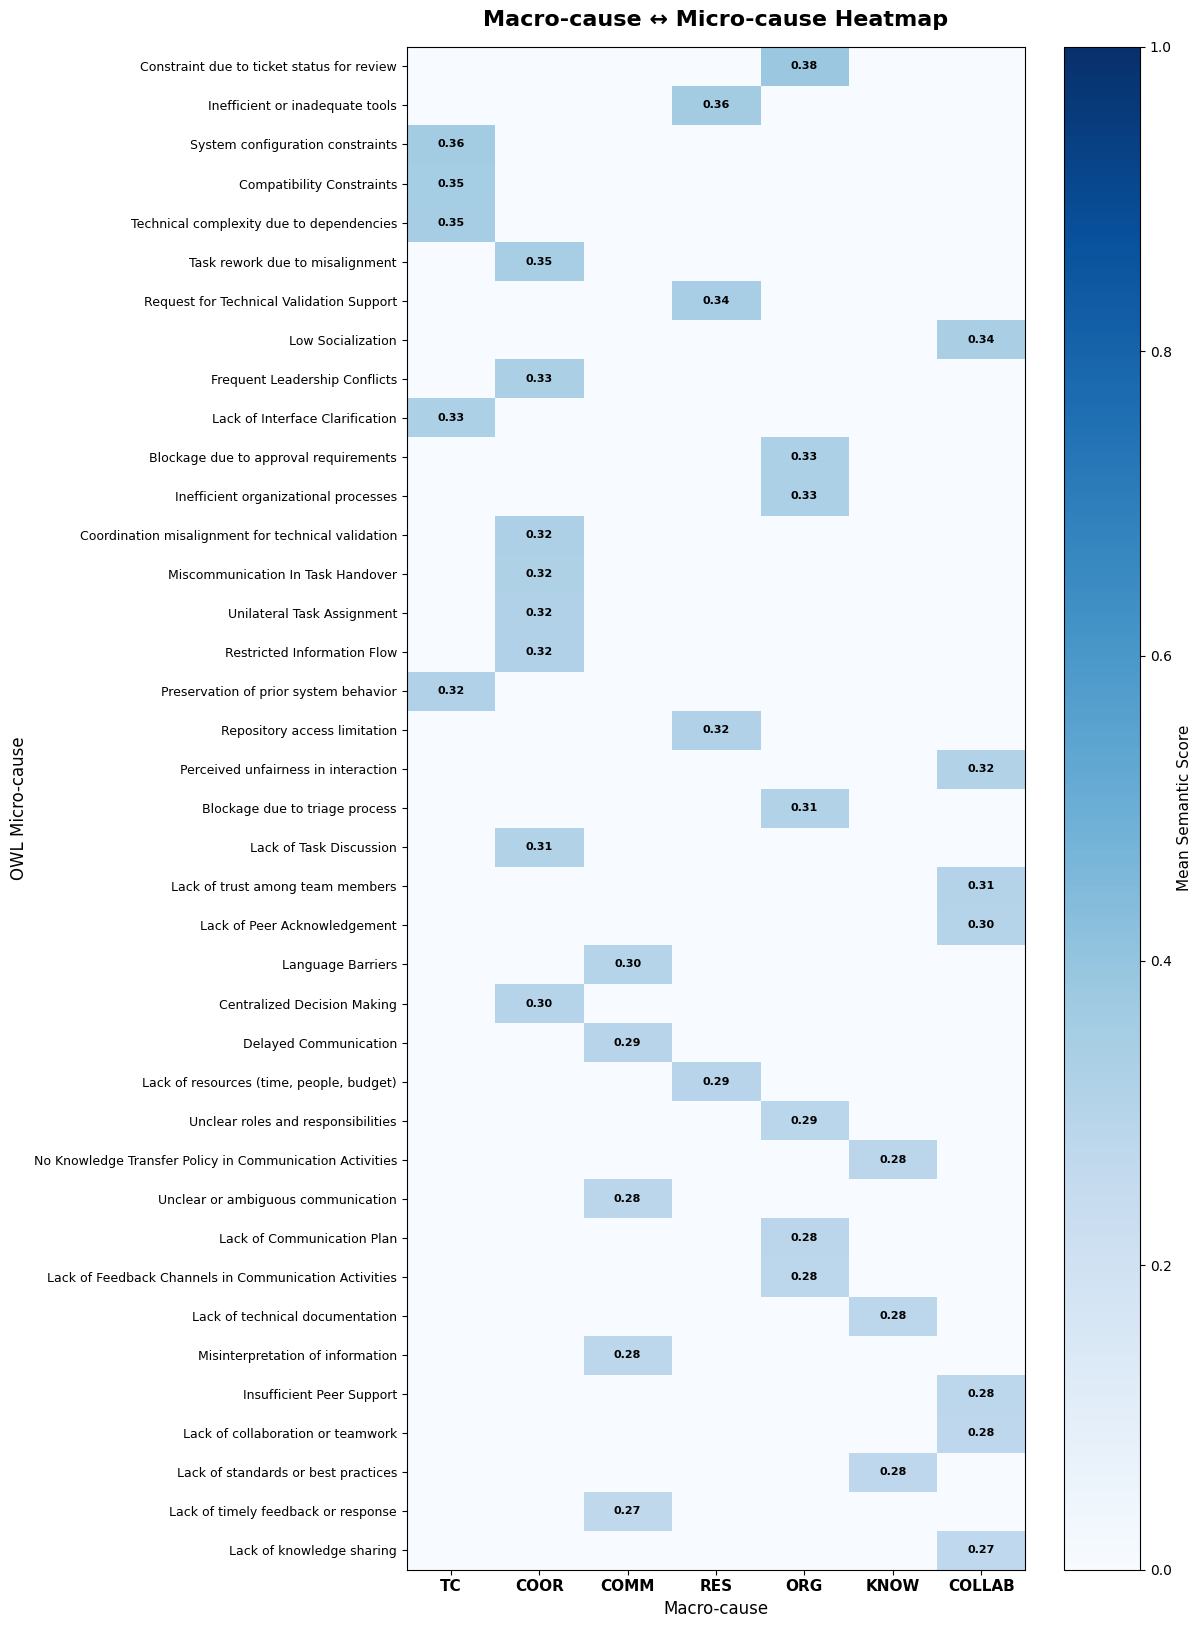


Matriz del heatmap guardada en:
/content/outputs/heatmap_macro_micro_topk_dataset_completo.xlsx

PASO 13 completado correctamente.


In [20]:
# ============================================================
# PASO 13. GENERAR MATRIZ Y HEATMAP MACROCAUSA ↔ MICROCAUSA
# Basado en las clasificaciones TOP-K del dataset completo
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 0. Validaciones previas
# ------------------------------------------------------------

if "df_topk_full" not in globals():
    raise NameError(
        "No existe df_topk_full. "
        "Ejecuta primero el PASO 12."
    )

required_columns = [
    "final_cause_for_analysis",
    "top_microcause_names",
    "top_microcause_scores"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_topk_full.columns
]

if missing_columns:
    raise ValueError(
        "Faltan columnas TOP-K en df_topk_full: "
        f"{missing_columns}"
    )

# ------------------------------------------------------------
# 1. Crear carpeta de salida
# ------------------------------------------------------------

if "output_dir" not in globals():
    output_dir = Path("/content/outputs")
else:
    output_dir = Path(output_dir)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Carpeta de salida:", output_dir)

# ------------------------------------------------------------
# 2. Expandir resultados TOP-K
# ------------------------------------------------------------

heatmap_rows = []

for _, row in df_topk_full.iterrows():

    macrocausa = row["final_cause_for_analysis"]
    microcausas = row["top_microcause_names"]
    scores = row["top_microcause_scores"]

    if not isinstance(microcausas, list):
        continue

    if not isinstance(scores, list):
        continue

    if len(microcausas) != len(scores):
        continue

    for microcausa, score in zip(
        microcausas,
        scores
    ):

        try:
            score = float(score)

        except (TypeError, ValueError):
            continue

        heatmap_rows.append({
            "macrocausa": macrocausa,
            "microcausa": microcausa,
            "score": score
        })

heatmap_df = pd.DataFrame(
    heatmap_rows
)

if heatmap_df.empty:
    raise ValueError(
        "No se generaron relaciones macrocausa-microcausa. "
        "Revisa las columnas top_microcause_names "
        "y top_microcause_scores."
    )

print(
    "Relaciones macrocausa-microcausa:",
    len(heatmap_df)
)

print(
    "Microcausas distintas recuperadas:",
    heatmap_df["microcausa"].nunique()
)

# ------------------------------------------------------------
# 3. Definir códigos de macrocausas
# ------------------------------------------------------------

MACROCAUSE_CODES = {
    "Technical complexity, compatibility, and system constraints":
        "TC",

    "Coordination and workflow misalignment":
        "COOR",

    "Communication and shared understanding breakdowns":
        "COMM",

    "Resource, tooling, access, and validation dependencies":
        "RES",

    "Organizational and procedural workflow constraints":
        "ORG",

    "Knowledge, documentation, and standards deficiencies":
        "KNOW",

    "Collaboration and interpersonal tensions":
        "COLLAB"
}

heatmap_df["macro_code"] = (
    heatmap_df["macrocausa"]
    .map(MACROCAUSE_CODES)
)

# ------------------------------------------------------------
# 4. Validar macrocausas no reconocidas
# ------------------------------------------------------------

unmapped_macros = (
    heatmap_df.loc[
        heatmap_df["macro_code"].isna(),
        "macrocausa"
    ]
    .dropna()
    .unique()
    .tolist()
)

if unmapped_macros:

    print("\nAdvertencia: macrocausas sin código:")

    for macrocausa in unmapped_macros:
        print("-", macrocausa)

# Conservar únicamente macrocausas reconocidas

heatmap_df = (
    heatmap_df[
        heatmap_df["macro_code"].notna()
    ]
    .copy()
)

if heatmap_df.empty:
    raise ValueError(
        "No quedaron relaciones válidas después de mapear "
        "los códigos de macrocausa."
    )

# ------------------------------------------------------------
# 5. Crear matriz de scores promedio
# ------------------------------------------------------------

pivot_df = heatmap_df.pivot_table(
    index="microcausa",
    columns="macro_code",
    values="score",
    aggfunc="mean",
    fill_value=0
)

if pivot_df.empty:
    raise ValueError(
        "La matriz macrocausa-microcausa quedó vacía."
    )

# ------------------------------------------------------------
# 6. Ordenar columnas de macrocausas
# ------------------------------------------------------------

macro_order = [
    "TC",
    "COOR",
    "COMM",
    "RES",
    "ORG",
    "KNOW",
    "COLLAB"
]

existing_macro_order = [
    code
    for code in macro_order
    if code in pivot_df.columns
]

pivot_df = pivot_df[
    existing_macro_order
]

# ------------------------------------------------------------
# 7. Ordenar microcausas por score máximo
# ------------------------------------------------------------

pivot_df["max_score_aux"] = (
    pivot_df.max(axis=1)
)

pivot_df = (
    pivot_df
    .sort_values(
        by="max_score_aux",
        ascending=False
    )
    .drop(
        columns="max_score_aux"
    )
)

print("\nDimensiones de la matriz:")
print(pivot_df.shape)

print("\nVista previa de la matriz:")

display(
    pivot_df.head(20)
)

# ------------------------------------------------------------
# 8. Crear heatmap
# ------------------------------------------------------------

figure_height = max(
    8,
    len(pivot_df.index) * 0.42
)

plt.figure(
    figsize=(
        12,
        figure_height
    )
)

image = plt.imshow(
    pivot_df.values,
    aspect="auto",
    cmap="Blues",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.xticks(
    range(
        len(pivot_df.columns)
    ),
    pivot_df.columns,
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    range(
        len(pivot_df.index)
    ),
    pivot_df.index,
    fontsize=9
)

# ------------------------------------------------------------
# 9. Mostrar scores dentro del heatmap
# ------------------------------------------------------------

for row_index in range(
    len(pivot_df.index)
):

    for column_index in range(
        len(pivot_df.columns)
    ):

        value = pivot_df.iloc[
            row_index,
            column_index
        ]

        if value <= 0:
            continue

        text_color = (
            "white"
            if value >= 0.60
            else "black"
        )

        plt.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
            fontweight="bold"
        )

# ------------------------------------------------------------
# 10. Títulos y formato
# ------------------------------------------------------------

plt.title(
    "Macro-cause ↔ Micro-cause Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Macro-cause",
    fontsize=12
)

plt.ylabel(
    "OWL Micro-cause",
    fontsize=12
)

colorbar = plt.colorbar(
    image
)

colorbar.set_label(
    "Mean Semantic Score",
    fontsize=11
)

plt.tight_layout()

# ------------------------------------------------------------
# 11. Guardar imagen del heatmap
# ------------------------------------------------------------

heatmap_output_path = (
    output_dir
    / "heatmap_macro_micro_topk_dataset_completo.png"
)

plt.savefig(
    heatmap_output_path,
    dpi=300,
    bbox_inches="tight"
)

print("\nHeatmap guardado en:")
print(heatmap_output_path)

plt.show()

# ------------------------------------------------------------
# 12. Exportar matriz del heatmap
# ------------------------------------------------------------

pivot_output_path = (
    output_dir
    / "heatmap_macro_micro_topk_dataset_completo.xlsx"
)

pivot_df.to_excel(
    pivot_output_path,
    engine="openpyxl"
)

print("\nMatriz del heatmap guardada en:")
print(pivot_output_path)

# ------------------------------------------------------------
# 13. Verificar archivos generados
# ------------------------------------------------------------

if not heatmap_output_path.exists():
    raise FileNotFoundError(
        "No se generó la imagen del heatmap."
    )

if not pivot_output_path.exists():
    raise FileNotFoundError(
        "No se generó el archivo Excel de la matriz."
    )

print("\nPASO 13 completado correctamente.")

In [21]:
# ============================================================
# PASO 14. DEFINIR FUNCIÓN DE ENRIQUECIMIENTO ONTOLÓGICO
# ============================================================

import pandas as pd
from rdflib import URIRef


def local_name(value):
    """
    Devuelve el nombre local de una URI.
    Si recibe un literal, devuelve su contenido.
    """

    if isinstance(value, URIRef):

        value = str(value)

        if "#" in value:
            return value.split("#")[-1]

        return value.rstrip("/").split("/")[-1]

    return str(value)


def empty_enrichment():
    """
    Genera una estructura vacía independiente.
    """

    return {
        "preventive_strategies": [],
        "effects": [],
        "corrective_strategies": [],
        "indicators": [],
        "metrics": [],
        "risks": [],
        "community_smells": []
    }


def get_ontology_enrichment(cause_id):
    """
    Recupera la información ontológica asociada
    a una microcausa OWL.
    """

    # --------------------------------------------------------
    # 1. Validaciones iniciales
    # --------------------------------------------------------

    if isinstance(cause_id, pd.Series):
        cause_id = cause_id.iloc[0]

    if cause_id is None:
        return empty_enrichment()

    try:
        if pd.isna(cause_id):
            return empty_enrichment()
    except (TypeError, ValueError):
        return empty_enrichment()

    cause_id = str(cause_id).strip()

    if cause_id == "":
        return empty_enrichment()

    if cause_id.lower() in {
        "nan",
        "none"
    }:
        return empty_enrichment()

    # --------------------------------------------------------
    # 2. Construir URI de la microcausa
    # --------------------------------------------------------

    cause_uri = NS[cause_id]

    if not any(
        g.triples(
            (
                cause_uri,
                None,
                None
            )
        )
    ):
        return empty_enrichment()

    # --------------------------------------------------------
    # 3. Estructuras auxiliares
    # --------------------------------------------------------

    preventive = set()
    effects = set()
    corrective = set()
    indicators = set()
    metrics = set()
    risks = set()
    community_smells = set()

    # --------------------------------------------------------
    # 4. Propiedades ontológicas
    # --------------------------------------------------------

    preventive_props = [
        NS.hasAdministrativePreventiveStrategy,
        NS.hasCommunicationStrategy,
        NS.hasCoordinationStrategy,
        NS.hasCollaborationStrategy,
        NS.hasCongruenceStrategy,
    ]

    corrective_props = [
        NS.hasCorrectiveStrategy,
        NS.hasAdministrativeStrategy,
        NS.hasGroupStrategy,
        NS.hasIndividualStrategy,
        NS.hasProjectManagementStrategy,
        NS.hasTechnicalStrategy,
    ]

    indicator_props = [
        NS.isIndicatedByCause,
        NS.isMonitoredByIndicator,
    ]

    metric_props = [
        NS.isMeasuredByMetric,
    ]

    risk_props = [
        NS.leadsToRisk,
        NS.generatesRisk,
    ]

    community_smell_props = [
        NS.hasRelatedCommunitySmell,
        NS.hasCauseCommunitySmell,
    ]

    # --------------------------------------------------------
    # 5. Estrategias preventivas
    # --------------------------------------------------------

    for prop in preventive_props:

        for obj in g.objects(
            cause_uri,
            prop
        ):

            preventive.add(
                local_name(obj)
            )

    # --------------------------------------------------------
    # 6. Efectos y estrategias correctivas
    # --------------------------------------------------------

    for effect in g.objects(
        cause_uri,
        NS.generatesEffect
    ):

        effects.add(
            local_name(effect)
        )

        for prop in corrective_props:

            for strategy in g.objects(
                effect,
                prop
            ):

                corrective.add(
                    local_name(strategy)
                )

    # --------------------------------------------------------
    # 7. Indicadores
    # --------------------------------------------------------

    for prop in indicator_props:

        for obj in g.objects(
            cause_uri,
            prop
        ):

            indicators.add(
                local_name(obj)
            )

    # --------------------------------------------------------
    # 8. Métricas
    # --------------------------------------------------------

    for prop in metric_props:

        for obj in g.objects(
            cause_uri,
            prop
        ):

            metrics.add(
                local_name(obj)
            )

    # --------------------------------------------------------
    # 9. Riesgos
    # --------------------------------------------------------

    for prop in risk_props:

        for obj in g.objects(
            cause_uri,
            prop
        ):

            risks.add(
                local_name(obj)
            )

    # --------------------------------------------------------
    # 10. Community smells
    # --------------------------------------------------------

    for prop in community_smell_props:

        for obj in g.objects(
            cause_uri,
            prop
        ):

            community_smells.add(
                local_name(obj)
            )

    # --------------------------------------------------------
    # 11. Resultado final
    # --------------------------------------------------------

    return {
        "preventive_strategies":
            sorted(preventive),

        "effects":
            sorted(effects),

        "corrective_strategies":
            sorted(corrective),

        "indicators":
            sorted(indicators),

        "metrics":
            sorted(metrics),

        "risks":
            sorted(risks),

        "community_smells":
            sorted(community_smells)
    }


print("Función de enriquecimiento ontológico cargada correctamente.")

Función de enriquecimiento ontológico cargada correctamente.


In [22]:
# ============================================================
# PASO 15. ENRIQUECIMIENTO MULTI-MICROCAUSA TOP-K
# ============================================================

import ast
import pandas as pd
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 0. Validaciones previas
# ------------------------------------------------------------

if "df_topk_full" not in globals():
    raise NameError(
        "No existe df_topk_full. "
        "Ejecuta primero el PASO 12."
    )

if "top_microcause_ids" not in df_topk_full.columns:
    raise ValueError(
        "No existe la columna 'top_microcause_ids' "
        "en df_topk_full. Ejecuta primero el PASO 12."
    )

if "get_ontology_enrichment" not in globals():
    raise NameError(
        "No existe la función get_ontology_enrichment. "
        "Ejecuta primero el PASO 14."
    )

df_topk_full = (
    df_topk_full
    .reset_index(drop=True)
    .copy()
)

# ------------------------------------------------------------
# 1. Convertir valores en listas reales
# ------------------------------------------------------------

def safe_to_list(value):
    """
    Convierte listas o representaciones textuales
    de listas en listas reales.
    """

    if isinstance(value, list):
        return value

    if value is None:
        return []

    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    if isinstance(value, str):

        value = value.strip()

        if value == "" or value.lower() in {
            "nan",
            "none",
            "[]"
        }:
            return []

        try:
            parsed = ast.literal_eval(value)

            if isinstance(parsed, list):
                return parsed

        except (ValueError, SyntaxError):
            return [value]

    return []


# ------------------------------------------------------------
# 2. Unir listas y eliminar duplicados
# ------------------------------------------------------------

def merge_unique_lists(values):
    """
    Une varias listas, elimina valores vacíos
    y evita elementos duplicados.
    """

    merged = set()

    for value in values:

        if not isinstance(value, list):
            continue

        for item in value:

            if item is None:
                continue

            item = str(item).strip()

            if item:
                merged.add(item)

    return sorted(merged)


# ------------------------------------------------------------
# 3. Enriquecer cada registro según sus microcausas TOP-K
# ------------------------------------------------------------

multi_enrichment_results = []

for _, row in tqdm(
    df_topk_full.iterrows(),
    total=len(df_topk_full),
    desc="Enriqueciendo desde la ontología"
):

    micro_ids = safe_to_list(
        row["top_microcause_ids"]
    )

    preventive_all = []
    effects_all = []
    corrective_all = []
    indicators_all = []
    metrics_all = []
    risks_all = []
    smells_all = []

    for micro_id in micro_ids:

        enrichment = get_ontology_enrichment(
            micro_id
        )

        preventive_all.append(
            enrichment["preventive_strategies"]
        )

        effects_all.append(
            enrichment["effects"]
        )

        corrective_all.append(
            enrichment["corrective_strategies"]
        )

        indicators_all.append(
            enrichment["indicators"]
        )

        metrics_all.append(
            enrichment["metrics"]
        )

        risks_all.append(
            enrichment["risks"]
        )

        smells_all.append(
            enrichment["community_smells"]
        )

    multi_enrichment_results.append({
        "preventive_strategies":
            merge_unique_lists(preventive_all),

        "effects":
            merge_unique_lists(effects_all),

        "corrective_strategies":
            merge_unique_lists(corrective_all),

        "indicators":
            merge_unique_lists(indicators_all),

        "metrics":
            merge_unique_lists(metrics_all),

        "risks":
            merge_unique_lists(risks_all),

        "community_smells":
            merge_unique_lists(smells_all)
    })

# ------------------------------------------------------------
# 4. Convertir enriquecimientos a DataFrame
# ------------------------------------------------------------

multi_enrichment_df = (
    pd.DataFrame(multi_enrichment_results)
    .reset_index(drop=True)
)

if len(multi_enrichment_df) != len(df_topk_full):
    raise ValueError(
        "La cantidad de enriquecimientos no coincide "
        "con la cantidad de registros del dataset."
    )

# ------------------------------------------------------------
# 5. Definir columnas de enriquecimiento
# ------------------------------------------------------------

enrichment_cols = [
    "preventive_strategies",
    "effects",
    "corrective_strategies",
    "indicators",
    "metrics",
    "risks",
    "community_smells"
]

# ------------------------------------------------------------
# 6. Eliminar columnas previas si el paso se ejecuta de nuevo
# ------------------------------------------------------------

existing_enrichment_cols = [
    column
    for column in enrichment_cols
    if column in df_topk_full.columns
]

if existing_enrichment_cols:

    df_topk_full = df_topk_full.drop(
        columns=existing_enrichment_cols
    )

    print(
        "\nColumnas de enriquecimiento previas eliminadas:",
        len(existing_enrichment_cols)
    )

# ------------------------------------------------------------
# 7. Agregar columnas enriquecidas al dataset
# ------------------------------------------------------------

for column in enrichment_cols:

    df_topk_full[column] = (
        multi_enrichment_df[column].values
    )

# ------------------------------------------------------------
# 8. Validar columnas agregadas
# ------------------------------------------------------------

missing_enrichment_cols = [
    column
    for column in enrichment_cols
    if column not in df_topk_full.columns
]

if missing_enrichment_cols:
    raise ValueError(
        "No se agregaron correctamente las columnas: "
        f"{missing_enrichment_cols}"
    )

# ------------------------------------------------------------
# 9. Mostrar resumen del enriquecimiento
# ------------------------------------------------------------

print("\nEnriquecimiento ontológico completado.")
print("Registros procesados:", len(df_topk_full))

print("\nColumnas enriquecidas agregadas:")

for column in enrichment_cols:
    print("-", column)

print("\nRegistros con información no vacía:")

for column in enrichment_cols:

    non_empty = (
        df_topk_full[column]
        .apply(
            lambda value:
                isinstance(value, list)
                and len(value) > 0
        )
        .sum()
    )

    print(
        f"{column}: {non_empty} de {len(df_topk_full)}"
    )

# ------------------------------------------------------------
# 10. Validar tipo de dato de las columnas enriquecidas
# ------------------------------------------------------------

print("\nValidación de columnas tipo lista:")

for column in enrichment_cols:

    invalid_values = (
        ~df_topk_full[column]
        .apply(
            lambda value:
                isinstance(value, list)
        )
    ).sum()

    print(
        f"{column}: valores no-lista = {invalid_values}"
    )

# ------------------------------------------------------------
# 11. Confirmar finalización
# ------------------------------------------------------------

print("\nPASO 15 completado correctamente.")

Enriqueciendo desde la ontología:   0%|          | 0/3761 [00:00<?, ?it/s]


Enriquecimiento ontológico completado.
Registros procesados: 3761

Columnas enriquecidas agregadas:
- preventive_strategies
- effects
- corrective_strategies
- indicators
- metrics
- risks
- community_smells

Registros con información no vacía:
preventive_strategies: 3761 de 3761
effects: 3761 de 3761
corrective_strategies: 3761 de 3761
indicators: 3761 de 3761
metrics: 3761 de 3761
risks: 3761 de 3761
community_smells: 3761 de 3761

Validación de columnas tipo lista:
preventive_strategies: valores no-lista = 0
effects: valores no-lista = 0
corrective_strategies: valores no-lista = 0
indicators: valores no-lista = 0
metrics: valores no-lista = 0
risks: valores no-lista = 0
community_smells: valores no-lista = 0

PASO 15 completado correctamente.


In [23]:
# ============================================================
# PASO 16. VALIDAR Y EXPORTAR DATASET FINAL ENRIQUECIDO
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 0. Validaciones previas
# ------------------------------------------------------------

if "df_topk_full" not in globals():
    raise NameError(
        "No existe df_topk_full. "
        "Ejecuta primero los PASOS 12, 14 y 15."
    )

required_final_columns = [
    "primary_microcause_id",
    "primary_microcause_name",
    "primary_microcause_type",
    "primary_similarity_score",
    "classification_status_topk",
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_types",
    "top_microcause_scores",
    "top_microcause_count",
    "preventive_strategies",
    "effects",
    "corrective_strategies",
    "indicators",
    "metrics",
    "risks",
    "community_smells"
]

missing_final_columns = [
    column
    for column in required_final_columns
    if column not in df_topk_full.columns
]

if missing_final_columns:
    raise ValueError(
        "Faltan columnas en el dataset final: "
        f"{missing_final_columns}"
    )

# ------------------------------------------------------------
# 1. Crear copia final independiente
# ------------------------------------------------------------

df_final = (
    df_topk_full
    .copy()
    .reset_index(drop=True)
)

print("Shape inicial del dataset final:")
print(df_final.shape)

# ------------------------------------------------------------
# 2. Validar que no regresó la clase H
# ------------------------------------------------------------

if "final_cause_code" in df_final.columns:

    total_h = (
        df_final["final_cause_code"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("H")
        .sum()
    )

    print("\nRegistros con código H:", total_h)

    if total_h > 0:
        raise ValueError(
            "Todavía existen registros con código H "
            "en el dataset final."
        )

# ------------------------------------------------------------
# 3. Validar valores nulos en columnas esenciales
# ------------------------------------------------------------

essential_columns = [
    "primary_microcause_id",
    "primary_microcause_name",
    "primary_similarity_score",
    "classification_status_topk",
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_scores",
    "top_microcause_count"
]

null_summary = (
    df_final[essential_columns]
    .isnull()
    .sum()
)

print("\nValores nulos en columnas esenciales:")

display(
    null_summary
)

if null_summary.sum() > 0:
    raise ValueError(
        "Existen valores nulos en columnas esenciales "
        "del resultado TOP-K."
    )

# ------------------------------------------------------------
# 4. Validar que las columnas TOP-K sean listas
# ------------------------------------------------------------

topk_list_columns = [
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_types",
    "top_microcause_scores"
]

print("\nValidación de columnas TOP-K tipo lista:")

for column in topk_list_columns:

    invalid_count = (
        ~df_final[column]
        .apply(
            lambda value:
                isinstance(value, list)
        )
    ).sum()

    print(
        f"{column}: valores no-lista = {invalid_count}"
    )

    if invalid_count > 0:
        raise ValueError(
            f"La columna {column} contiene "
            "valores que no son listas."
        )

# ------------------------------------------------------------
# 5. Validar consistencia de las listas TOP-K
# ------------------------------------------------------------

topk_count_inconsistencies = (
    df_final["top_microcause_count"]
    !=
    df_final["top_microcause_ids"]
    .apply(len)
).sum()

ids_names_inconsistencies = (
    df_final["top_microcause_ids"]
    .apply(len)
    !=
    df_final["top_microcause_names"]
    .apply(len)
).sum()

ids_types_inconsistencies = (
    df_final["top_microcause_ids"]
    .apply(len)
    !=
    df_final["top_microcause_types"]
    .apply(len)
).sum()

ids_scores_inconsistencies = (
    df_final["top_microcause_ids"]
    .apply(len)
    !=
    df_final["top_microcause_scores"]
    .apply(len)
).sum()

print("\nConsistencia de listas TOP-K:")

print(
    "Inconsistencias count vs. IDs:",
    topk_count_inconsistencies
)

print(
    "Inconsistencias IDs vs. nombres:",
    ids_names_inconsistencies
)

print(
    "Inconsistencias IDs vs. tipos:",
    ids_types_inconsistencies
)

print(
    "Inconsistencias IDs vs. scores:",
    ids_scores_inconsistencies
)

total_topk_inconsistencies = (
    topk_count_inconsistencies
    + ids_names_inconsistencies
    + ids_types_inconsistencies
    + ids_scores_inconsistencies
)

if total_topk_inconsistencies > 0:
    raise ValueError(
        "Existen inconsistencias en las listas TOP-K."
    )

# ------------------------------------------------------------
# 6. Validar rango del score principal
# ------------------------------------------------------------

invalid_primary_scores = (
    (
        df_final["primary_similarity_score"] < 0
    )
    |
    (
        df_final["primary_similarity_score"] > 1
    )
).sum()

print(
    "\nScores principales fuera del rango [0, 1]:",
    invalid_primary_scores
)

if invalid_primary_scores > 0:
    raise ValueError(
        "Existen scores principales fuera del rango [0, 1]."
    )

# ------------------------------------------------------------
# 7. Validar scores de las listas TOP-K
# ------------------------------------------------------------

def valid_score_list(score_list):
    """
    Verifica que todos los scores de una lista
    sean numéricos y estén en el rango [0, 1].
    """

    if not isinstance(score_list, list):
        return False

    for score in score_list:

        try:
            numeric_score = float(score)

        except (TypeError, ValueError):
            return False

        if numeric_score < 0 or numeric_score > 1:
            return False

    return True


invalid_topk_scores = (
    ~df_final["top_microcause_scores"]
    .apply(valid_score_list)
).sum()

print(
    "Listas TOP-K con scores inválidos:",
    invalid_topk_scores
)

if invalid_topk_scores > 0:
    raise ValueError(
        "Existen listas TOP-K con scores inválidos."
    )

# ------------------------------------------------------------
# 8. Validar columnas de enriquecimiento
# ------------------------------------------------------------

enrichment_columns = [
    "preventive_strategies",
    "effects",
    "corrective_strategies",
    "indicators",
    "metrics",
    "risks",
    "community_smells"
]

print("\nValidación de columnas de enriquecimiento:")

for column in enrichment_columns:

    invalid_count = (
        ~df_final[column]
        .apply(
            lambda value:
                isinstance(value, list)
        )
    ).sum()

    non_empty_count = (
        df_final[column]
        .apply(
            lambda value:
                isinstance(value, list)
                and len(value) > 0
        )
    ).sum()

    print(
        f"{column}: "
        f"no-lista = {invalid_count}, "
        f"con información = {non_empty_count} "
        f"de {len(df_final)}"
    )

    if invalid_count > 0:
        raise ValueError(
            f"La columna {column} contiene "
            "valores que no son listas."
        )

# ------------------------------------------------------------
# 9. Validar duplicados
# ------------------------------------------------------------

if "comment_id" in df_final.columns:

    duplicate_comments = (
        df_final["comment_id"]
        .duplicated()
        .sum()
    )

    print(
        "\nDuplicados por comment_id:",
        duplicate_comments
    )

else:

    duplicate_comments = 0

    print(
        "\nNo existe la columna comment_id. "
        "No se validaron duplicados por identificador."
    )

duplicate_columns = (
    df_final.columns[
        df_final.columns.duplicated()
    ]
    .tolist()
)

print(
    "Columnas duplicadas:",
    duplicate_columns
)

if duplicate_columns:
    raise ValueError(
        "El dataset contiene columnas duplicadas."
    )

# ------------------------------------------------------------
# 10. Mostrar resumen final
# ------------------------------------------------------------

print("\nDistribución de estados TOP-K:")

display(
    df_final["classification_status_topk"]
    .value_counts()
)

print("\nEstadísticas del score principal:")

display(
    df_final["primary_similarity_score"]
    .describe()
)

print("\nCantidad de microcausas por registro:")

display(
    df_final["top_microcause_count"]
    .value_counts()
    .sort_index()
)

print("\nFrecuencia de microcausas principales:")

display(
    df_final["primary_microcause_name"]
    .value_counts()
)

# ------------------------------------------------------------
# 11. Exportar dataset final
# ------------------------------------------------------------

OUTPUT_FILE = (
    "/content/"
    "Dataset_integration_semantico_topk_enriched_final.xlsx"
)

df_final.to_excel(
    OUTPUT_FILE,
    index=False,
    engine="openpyxl"
)

# ------------------------------------------------------------
# 12. Verificar archivo generado
# ------------------------------------------------------------

if not os.path.exists(OUTPUT_FILE):
    raise FileNotFoundError(
        "El archivo final no fue generado."
    )

file_size = os.path.getsize(
    OUTPUT_FILE
)

if file_size <= 0:
    raise ValueError(
        "El archivo fue creado, pero está vacío."
    )

# ------------------------------------------------------------
# 13. Mostrar resultado final
# ------------------------------------------------------------

print("\nDataset final exportado correctamente.")

print(
    "Archivo:",
    OUTPUT_FILE
)

print(
    "Registros:",
    len(df_final)
)

print(
    "Columnas:",
    len(df_final.columns)
)

print(
    "Tamaño:",
    file_size,
    "bytes"
)

print("\nShape final:")
print(df_final.shape)

print("\nVista previa del dataset final:")

display(
    df_final.head(10)
)

print("\nPASO 16 completado correctamente.")

Shape inicial del dataset final:
(3761, 59)

Registros con código H: 0

Valores nulos en columnas esenciales:


,0
primary_microcause_id,0
primary_microcause_name,0
primary_similarity_score,0
classification_status_topk,0
top_microcause_ids,0
top_microcause_names,0
top_microcause_scores,0
top_microcause_count,0



Validación de columnas TOP-K tipo lista:
top_microcause_ids: valores no-lista = 0
top_microcause_names: valores no-lista = 0
top_microcause_types: valores no-lista = 0
top_microcause_scores: valores no-lista = 0

Consistencia de listas TOP-K:
Inconsistencias count vs. IDs: 0
Inconsistencias IDs vs. nombres: 0
Inconsistencias IDs vs. tipos: 0
Inconsistencias IDs vs. scores: 0

Scores principales fuera del rango [0, 1]: 0
Listas TOP-K con scores inválidos: 0

Validación de columnas de enriquecimiento:
preventive_strategies: no-lista = 0, con información = 3761 de 3761
effects: no-lista = 0, con información = 3761 de 3761
corrective_strategies: no-lista = 0, con información = 3761 de 3761
indicators: no-lista = 0, con información = 3761 de 3761
metrics: no-lista = 0, con información = 3761 de 3761
risks: no-lista = 0, con información = 3761 de 3761
community_smells: no-lista = 0, con información = 3761 de 3761

Duplicados por comment_id: 0
Columnas duplicadas: []

Distribución de estados

,count
classification_status_topk,
mapped_topk,2664
mapped_low_confidence,1097



Estadísticas del score principal:


...


Frecuencia de microcausas principales:


,count
primary_microcause_name,
Compatibility Constraints,532
Task rework due to misalignment,388
Coordination misalignment for technical validation,351
Inefficient or inadequate tools,278
Unclear or ambiguous communication,278
System configuration constraints,275
Lack of Interface Clarification,193
Restricted Information Flow,172
Lack of technical documentation,164



Dataset final exportado correctamente.
Archivo: /content/Dataset_integration_semantico_topk_enriched_final.xlsx
Registros: 3761
Columnas: 59
Tamaño: 2664811 bytes

Shape final:
(3761, 59)

Vista previa del dataset final:


,repo,issue_number,comment_id,comment_author,comment_created_at,comment_body_raw,comment_body_clean_final,true_code,evaluable,match,...,microcause_3_name,microcause_3_type,microcause_3_score,preventive_strategies,effects,corrective_strategies,indicators,metrics,risks,community_smells
0,microsoft/vscode,291739,3821059210,RedCMD,2026-01-30T00:11:41Z,yea\nvscode doesnt close the document for 3min...,yea\nvscode doesnt close the document for 3min...,NaN,False,NaN,...,None,None,NaN,"[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[CS-021_TargetedCompatibilityValidation, CS-03...","[IND-004_Responsibility_Overlap_Index, IND-021...","[MTR-006_Information_Disconnect_Index, MTR-021...","[RSK-005_Documentation_Gaps_Risk, RSK-013_Tech...","[Missing Link, Socio-Technical Congruence Gap]"
1,microsoft/vscode,291739,3823089917,jrieken,2026-01-30T10:52:09Z,Diagnostics are computed by extensions and pus...,Diagnostics are computed by extensions and pus...,NaN,False,NaN,...,Compatibility Constraints,CongruenceCause,0.319257,"[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[CS-021_TargetedCompatibilityValidation, CS-02...","[IND-004_Responsibility_Overlap_Index, IND-021...","[MTR-006_Information_Disconnect_Index, MTR-021...","[RSK-005_Documentation_Gaps_Risk, RSK-013_Tech...","[Missing Link, Socio-Technical Congruence Gap]"
2,microsoft/vscode,291739,3823108413,RedCMD,2026-01-30T10:57:03Z,> It's up to the extension to handle closing/r...,"based on the quotation: ""It's up to the extens...",NaN,False,NaN,...,System configuration constraints,CongruenceCause,0.289076,"[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[CS-021_TargetedCompatibilityValidation, CS-02...","[IND-004_Responsibility_Overlap_Index, IND-021...","[MTR-006_Information_Disconnect_Index, MTR-021...","[RSK-005_Documentation_Gaps_Risk, RSK-013_Tech...","[Missing Link, Socio-Technical Congruence Gap]"
3,microsoft/vscode,291739,3823235746,jrieken,2026-01-30T11:32:04Z,There is `vscode.window.tabGroups` which repre...,There is /inline_code which represents the sta...,NaN,False,NaN,...,None,None,NaN,"[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[CS-034_ResourceUseCorrection, STR-I-015_Chang...",[IND-004_Responsibility_Overlap_Index],[MTR-006_Information_Disconnect_Index],[RSK-005_Documentation_Gaps_Risk],[Missing Link]
4,microsoft/vscode,291739,3824225974,n-gist,2026-01-30T15:06:48Z,> yea\n> vscode doesnt close the document for ...,"based on the quotation: ""yea""\nbased on the qu...",NaN,False,NaN,...,None,None,NaN,"[PS-003_TransparentInformationChannels, PS-016...","[PME-003_DelaysInTaskDelivery, TEF-002_Communi...","[CS-020_RestateAndClarifyMeaning, CS-020_Share...","[IND-010_CommunicationClarityLevel, IND-020_Cl...","[MTR-010_ClarityScore, MTR-020_ClarificationRe...","[RSK-010_MiscommunicationRisk, RSK-020_Misinte...","[Missing Link, Power Distance]"
5,microsoft/vscode,291739,3824361978,n-gist,2026-01-30T15:38:29Z,Also I don't understand why issue is closed. I...,Also I don't understand why issue is closed. I...,NaN,False,NaN,...,None,None,NaN,"[PS-003_TransparentInformationChannels, PS-016...","[GEF-002_LowMotivation, PME-003_DelaysInTaskDe...","[CS-020_RestateAndClarifyMeaning, CS-020_Share...","[IND-002_Feedback_Latency_Score, IND-010_Commu...","[MTR-004_Language_Barrier_Impact, MTR-010_Clar...","[RSK-002_Feedback_Delays_Risk, RSK-010_Miscomm...","[Missing Link, Power Distance]"
6,microsoft/vscode,291739,3824457070,jrieken,2026-01-30T16:01:17Z,"> but in general, the fact that documents open...","based on the quotation: ""but in general, the f...",NaN,False,NaN,...,Compatibility Constraints,CongruenceCause,0.284420,"[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[CS-021_TargetedCompatibilityValidation, C


PASO 16 completado correctamente.


In [24]:
# ============================================================
# PASO 17. FORMATO DEL DATASET FINAL
# ============================================================

from openpyxl import load_workbook
from openpyxl.styles import Alignment

archivo = (
    "/content/"
    "Dataset_integration_semantico_topk_enriched_final.xlsx"
)

wb = load_workbook(archivo)
ws = wb.active

# ------------------------------------------------------------
# 1. Alinear todas las celdas
# ------------------------------------------------------------

for row in ws.iter_rows():

    for cell in row:

        cell.alignment = Alignment(
            horizontal="left",
            vertical="top",
            wrap_text=True
        )

# ------------------------------------------------------------
# 2. Ajustar ancho de columnas
# ------------------------------------------------------------

for column in ws.columns:

    max_length = 0
    column_letter = column[0].column_letter

    for cell in column:

        try:

            if cell.value is not None:

                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        except Exception:
            pass

    ws.column_dimensions[column_letter].width = min(
        max(max_length + 2, 15),
        50
    )

# ------------------------------------------------------------
# 3. Guardar archivo
# ------------------------------------------------------------

wb.save(archivo)

print("Formato aplicado correctamente.")
print("Archivo:", archivo)

Formato aplicado correctamente.
Archivo: /content/Dataset_integration_semantico_topk_enriched_final.xlsx


In [25]:
# ============================================================
# PASO 18. DESCARGAR DATASET FINAL
# ============================================================

import os

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

# ------------------------------------------------------------
# Archivo final
# ------------------------------------------------------------

OUTPUT_FILE = (
    "/content/"
    "Dataset_integration_semantico_topk_enriched_final.xlsx"
)

# ------------------------------------------------------------
# Verificar existencia
# ------------------------------------------------------------

if not os.path.exists(OUTPUT_FILE):
    raise FileNotFoundError(
        f"No se encontró el archivo:\n{OUTPUT_FILE}"
    )

file_size = os.path.getsize(OUTPUT_FILE)

print("=" * 60)
print("PASO 18 completado correctamente.")
print("Dataset final disponible.")
print("Archivo:", OUTPUT_FILE)
print("Tamaño:", f"{file_size:,}", "bytes")
print("=" * 60)

# ------------------------------------------------------------
# Descargar automáticamente (solo en Google Colab)
# ------------------------------------------------------------

if COLAB:

    print("\nIniciando descarga...\n")
    files.download(OUTPUT_FILE)

else:

    print(
        "\nNo estás ejecutando Google Colab.\n"
        "El archivo ya quedó guardado en la ruta indicada."
    )

PASO 18 completado correctamente.
Dataset final disponible.
Archivo: /content/Dataset_integration_semantico_topk_enriched_final.xlsx
Tamaño: 2,726,590 bytes

Iniciando descarga...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# ============================================================
# EXPERIMENTO 1. CREAR MUESTRA ESTRATIFICADA
# 20 comentarios por macrocausa
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Parámetro
# ------------------------------------------------------------

SAMPLE_PER_MACRO = 20

# ------------------------------------------------------------
# Validaciones
# ------------------------------------------------------------

if "df_limpio" not in globals():
    raise NameError(
        "No existe df_limpio."
    )

required_columns = [
    "final_cause_for_analysis",
    "comment_body_clean_final"
]

missing_columns = [
    c
    for c in required_columns
    if c not in df_limpio.columns
]

if missing_columns:
    raise ValueError(
        f"Faltan columnas: {missing_columns}"
    )

# ------------------------------------------------------------
# Crear muestra estratificada
# ------------------------------------------------------------

df_sample = (
    df_limpio
    .groupby(
        "final_cause_for_analysis",
        group_keys=False
    )
    .apply(
        lambda x: x.sample(
            n=min(SAMPLE_PER_MACRO, len(x)),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print("Tamaño de la muestra:", len(df_sample))

print("\nDistribución por macrocausa:")

display(
    df_sample[
        "final_cause_for_analysis"
    ].value_counts()
)

print("\nVista previa:")

display(df_sample.head())

Tamaño de la muestra: 140

Distribución por macrocausa:


/tmp/ipykernel_6904/3636110485.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,count
final_cause_for_analysis,
Collaboration and interpersonal tensions,20
Communication and shared understanding breakdowns,20
Coordination and workflow misalignment,20
"Knowledge, documentation, and standards deficiencies",20
Organizational and procedural workflow constraints,20
"Resource, tooling, access, and validation dependencies",20
"Technical complexity, compatibility, and system constraints",20



Vista previa:


,repo,issue_number,comment_id,comment_author,comment_created_at,comment_body_raw,comment_body_clean_final,true_code,evaluable,match,...,Code_cause_llm,predicted_label_llm,Confidence_llm,Confidence,Requires_revision,State_prediction,Priority_rule_applied,rule_changed_llm,macro_cause_clean,comment_length
0,kubernetes/kubernetes,135322,3543842550,danwinship,2025-11-17T21:05:36Z,/uncc_x000D_\nbad bot. I'm only in 1 of the 17...,/uncc\nbad bot. I'm only in 1 of the 17 OWNERS...,NaN,False,NaN,...,E,Collaboration and interpersonal tensions,0.85,0.85,False,ACCEPTED,none,False,collaboration and interpersonal tensions,54
1,rails/rails,55121,2946111867,byroot,2025-06-05T20:32:51Z,> why so passive aggressive?_x000D_\n_x000D_\n...,"based on the quotation: ""why so passive aggres...",NaN,False,NaN,...,E,Collaboration and interpersonal tensions,0.90,0.90,False,ACCEPTED,none_llm_kept,False,collaboration and interpersonal tensions,1239
2,django/django,18266,2512204995,christophehenry,2024-12-02T17:16:23Z,"Ok, I understand how it came across as aggress...","Ok, I understand how it came across as aggress...",NaN,False,NaN,...,E,Collaboration and interpersonal tensions,0.90,0.90,False,ACCEPTED,none_llm_kept,False,collaboration and interpersonal tensions,210
3,kubernetes/kubernetes,136156,3738005125,k8s-ci-robot,2026-01-12T11:05:44Z,@pohly: you cannot LGTM your own PR.\n\n<detai...,A GitHub user is mentioned. you cannot LGTM yo...,NaN,False,NaN,...,E,Collaboration and interpersonal tensions,0.90,0.90,False,ACCEPTED,none,False,collaboration and interpersonal tensions,77
4,nodejs/node,60864,3702303674,chrisbbreuer,2025-12-31T14:29:57Z,Thanks for notifying me._x000D_\n_x000D_\nThis...,"Thanks for notifying me.\n\nThis ""chrisbbreuer...",NaN,False,NaN,...,E,Collaboration and interpersonal tensions,0.90,0.90,False,ACCEPTED,none,False,collaboration and interpersonal tensions,211


In [46]:
# ============================================================
# EXPORTAR DATASET SIMPLIFICADO Y VISIBLE
# Incluye las tres microcausas TOP-K en columnas independientes
# ============================================================

import os
import pandas as pd

from openpyxl import load_workbook
from openpyxl.styles import (
    Alignment,
    Font,
    PatternFill
)
from openpyxl.utils import get_column_letter


# ------------------------------------------------------------
# 0. Validaciones previas
# ------------------------------------------------------------

if "df_topk_full" not in globals():
    raise NameError(
        "No existe df_topk_full. "
        "Ejecuta primero la clasificación TOP-K "
        "y el enriquecimiento ontológico."
    )


# ------------------------------------------------------------
# 1. Definir columnas del dataset simplificado
# ------------------------------------------------------------

visible_columns = [
    # Información del comentario
    "repo",
    "issue_number",
    "comment_id",
    #"comment_author",
    "comment_created_at",
    "comment_body_raw",
    "comment_body_clean_final",

    # Macrocausa
    "final_cause_for_analysis",
    "macro_cause_clean",

    # Microcausa principal
    "primary_microcause_id",
    "primary_microcause_name",
    "primary_microcause_type",
   # "primary_similarity_score",


    # Microcausa 2
     "microcause_2_id",
    "microcause_2_name",
    "microcause_2_type",
    #"microcause_2_score",

    # Microcausa 3
    "microcause_3_id",
    "microcause_3_name",
    "microcause_3_type",
   #"microcause_3_score",

    # Resultado TOP-K completo
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_types",
   # "top_microcause_scores",
  #  "top_microcause_count",

    # Enriquecimiento ontológico
    "preventive_strategies",
    "effects",
    "corrective_strategies",
    "indicators",
    "metrics",
    "risks",
    "community_smells"
]


# ------------------------------------------------------------
# 2. Validar que todas las columnas existan
# ------------------------------------------------------------

missing_visible_columns = [
    column
    for column in visible_columns
    if column not in df_topk_full.columns
]

if missing_visible_columns:
    raise ValueError(
        "Faltan columnas para crear el dataset simplificado: "
        f"{missing_visible_columns}"
    )


# ------------------------------------------------------------
# 3. Crear dataset simplificado
# ------------------------------------------------------------

df_topk_visible = (
    df_topk_full[
        visible_columns
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Dataset simplificado creado:",
    df_topk_visible.shape
)


# ------------------------------------------------------------
# 4. Convertir listas a texto legible para Excel
# ------------------------------------------------------------

list_columns_visible = [
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_types",
    #"top_microcause_scores",
    "preventive_strategies",
    "effects",
    "corrective_strategies",
    "indicators",
    "metrics",
    "risks",
    "community_smells"
]


def list_to_visible_text(value):
    """
    Convierte una lista en texto multilínea para facilitar
    su lectura dentro de una celda de Excel.
    """

    if isinstance(value, list):

        clean_values = [
            str(item).strip()
            for item in value
            if item is not None
            and str(item).strip() != ""
        ]

        return "\n".join(clean_values)

    if value is None:
        return ""

    try:
        if pd.isna(value):
            return ""
    except (TypeError, ValueError):
        pass

    return str(value)


for column in list_columns_visible:

    df_topk_visible[column] = (
        df_topk_visible[column]
        .apply(list_to_visible_text)
    )


# ------------------------------------------------------------
# 5. Exportar archivo simplificado
# ------------------------------------------------------------

VISIBLE_OUTPUT_FILE = (
    "/content/"
    "Dataset_semantico_topk_campos_principales.xlsx"
)

df_topk_visible.to_excel(
    VISIBLE_OUTPUT_FILE,
    index=False,
    engine="openpyxl"
)

if not os.path.exists(VISIBLE_OUTPUT_FILE):
    raise FileNotFoundError(
        "No se generó el dataset simplificado."
    )


# ------------------------------------------------------------
# 6. Abrir archivo para aplicar formato
# ------------------------------------------------------------

workbook = load_workbook(
    VISIBLE_OUTPUT_FILE
)

worksheet = workbook.active

worksheet.title = "Dataset TOP-K"


# ------------------------------------------------------------
# 7. Formato del encabezado
# ------------------------------------------------------------

header_fill = PatternFill(
    fill_type="solid",
    fgColor="1F4E78"
)

header_font = Font(
    color="FFFFFF",
    bold=True
)

for cell in worksheet[1]:

    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )


# ------------------------------------------------------------
# 8. Alinear y ajustar contenido
# ------------------------------------------------------------

for row in worksheet.iter_rows(
    min_row=2
):

    for cell in row:

        cell.alignment = Alignment(
            horizontal="left",
            vertical="top",
            wrap_text=True
        )


# ------------------------------------------------------------
# 9. Definir anchos específicos
# ------------------------------------------------------------

column_widths = {
    "repo": 28,
    "issue_number": 15,
    "comment_id": 18,
   # "comment_author": 22,
    "comment_created_at": 22,
    "comment_body_raw": 55,
    "comment_body_clean_final": 55,
    "final_cause_for_analysis": 42,
    "macro_cause_clean": 42,

    "primary_microcause_id": 38,
    "primary_microcause_name": 40,
    "primary_microcause_type": 25,
    #"primary_similarity_score": 18,

   # "microcause_1_id": 38,
   # "microcause_1_name": 40,
   # "microcause_1_type": 25,
   # "microcause_1_score": 18,

    "microcause_2_id": 38,
    "microcause_2_name": 40,
    "microcause_2_type": 25,
    #"microcause_2_score": 18,

    "microcause_3_id": 38,
    "microcause_3_name": 40,
    "microcause_3_type": 25,
    #"microcause_3_score": 18,

   "" "top_microcause_ids": 45,
    "top_microcause_names": 50,
    "top_microcause_types": 35,
   # "top_microcause_scores": 35,
  # "top_microcause_count": 18,

    "preventive_strategies": 50,
    "effects": 50,
    "corrective_strategies": 50,
    "indicators": 50,
    "metrics": 50,
    "risks": 50,
    "community_smells": 40
}

header_positions = {
    cell.value: cell.column
    for cell in worksheet[1]
}

for column_name, width in column_widths.items():

    column_number = header_positions.get(
        column_name
    )

    if column_number is not None:

        column_letter = get_column_letter(
            column_number
        )

        worksheet.column_dimensions[
            column_letter
        ].width = width


# ------------------------------------------------------------
# 10. Fijar encabezado y activar filtro
# ------------------------------------------------------------

worksheet.freeze_panes = "A2"

worksheet.auto_filter.ref = (
    worksheet.dimensions
)

worksheet.row_dimensions[1].height = 35


# ------------------------------------------------------------
# 11. Guardar archivo formateado
# ------------------------------------------------------------

workbook.save(
    VISIBLE_OUTPUT_FILE
)


# ------------------------------------------------------------
# 12. Verificación final
# ------------------------------------------------------------

print("\nDataset simplificado exportado correctamente.")
print("Archivo:", VISIBLE_OUTPUT_FILE)
print("Registros:", len(df_topk_visible))
print("Columnas:", len(df_topk_visible.columns))
print(
    "Tamaño:",
    os.path.getsize(VISIBLE_OUTPUT_FILE),
    "bytes"
)

print("\nColumnas exportadas:")

for column in df_topk_visible.columns:
    print("-", column)

print("\nVista previa:")

display(
    df_topk_visible.head(10)
)

Dataset simplificado creado: (3761, 27)

Dataset simplificado exportado correctamente.
Archivo: /content/Dataset_semantico_topk_campos_principales.xlsx
Registros: 3761
Columnas: 27
Tamaño: 1774271 bytes

Columnas exportadas:
- repo
- issue_number
- comment_id
- comment_created_at
- comment_body_raw
- comment_body_clean_final
- final_cause_for_analysis
- macro_cause_clean
- primary_microcause_id
- primary_microcause_name
- primary_microcause_type
- microcause_2_id
- microcause_2_name
- microcause_2_type
- microcause_3_id
- microcause_3_name
- microcause_3_type
- top_microcause_ids
- top_microcause_names
- top_microcause_types
- preventive_strategies
- effects
- corrective_strategies
- indicators
- metrics
- risks
- community_smells

Vista previa:


,repo,issue_number,comment_id,comment_created_at,comment_body_raw,comment_body_clean_final,final_cause_for_analysis,macro_cause_clean,primary_microcause_id,primary_microcause_name,...,top_microcause_ids,top_microcause_names,top_microcause_types,preventive_strategies,effects,corrective_strategies,indicators,metrics,risks,community_smells
0,microsoft/vscode,291739,3821059210,2026-01-30T00:11:41Z,yea\nvscode doesnt close the document for 3min...,yea\nvscode doesnt close the document for 3min...,"Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...,COG-008_CompatibilityConstraints,Compatibility Constraints,...,COG-008_CompatibilityConstraints\nCOG-006_Lack...,Compatibility Constraints\nLack of Interface C...,CongruenceCause\nCongruenceCause,PS-004_InterfaceClarificationWorkshops\nPS-012...,IEF-008_ResistanceToChange\nTEF-009_WastedTime...,CS-021_TargetedCompatibilityValidation\nCS-034...,IND-004_Responsibility_Overlap_Index\nIND-021_...,MTR-006_Information_Disconnect_Index\nMTR-021_...,RSK-005_Documentation_Gaps_Risk\nRSK-013_Techn...,Missing Link\nSocio-Technical Congruence Gap
1,microsoft/vscode,291739,3823089917,2026-01-30T10:52:09Z,Diagnostics are computed by extensions and pus...,Diagnostics are computed by extensions and pus...,"Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,...,COG-006_LackOfInterfaceClarification\nCOG-011_...,Lack of Interface Clarification\nSystem config...,CongruenceCause\nCongruenceCause\nCongruenceCause,PS-004_InterfaceClarificationWorkshops\nPS-012...,IEF-008_ResistanceToChange\nTEF-009_WastedTime...,CS-021_TargetedCompatibilityValidation\nCS-022...,IND-004_Responsibility_Overlap_Index\nIND-021_...,MTR-006_Information_Disconnect_Index\nMTR-021_...,RSK-005_Documentation_Gaps_Risk\nRSK-013_Techn...,Missing Link\nSocio-Technical Congruence Gap
2,microsoft/vscode,291739,3823108413,2026-01-30T10:57:03Z,> It's up to the extension to handle closing/r...,"based on the quotation: ""It's up to the extens...","Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,...,COG-006_LackOfInterfaceClarification\nCOG-008_...,Lack of Interface Clarification\nCompatibility...,CongruenceCause\nCongruenceCause\nCongruenceCause,PS-004_InterfaceClarificationWorkshops\nPS-012...,IEF-008_ResistanceToChange\nTEF-009_WastedTime...,CS-021_TargetedCompatibilityValidation\nCS-022...,IND-004_Responsibility_Overlap_Index\nIND-021_...,MTR-006_Information_Disconnect_Index\nMTR-021_...,RSK-005_Documentation_Gaps_Risk\nRSK-013_Techn...,Missing Link\nSocio-Technical Congruence Gap
3,microsoft/vscode,291739,3823235746,2026-01-30T11:32:04Z,There is `vscode.window.tabGroups` which repre...,There is /inline_code which represents the sta...,"Technical complexity, compatibility, and syste...",technical complexity compatibility and system ...,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,...,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,CongruenceCause,PS-004_InterfaceClarificationWorkshops\nPS-012...,IEF-008_ResistanceToChange\nTEF-009_WastedTime...,CS-034_ResourceUseCorrection\nSTR-I-015_Change...,IND-004_Responsibility_Overlap_Index,MTR-006_Information_Disconnect_Index,RSK-005_Documentation_Gaps_Risk,Missing Link
4,microsoft/vscode,291739,3824225974,2026-01-30T15:06:48Z,> yea\n> vscode doesnt close the document for ...,"based on the quotation: ""yea""\nbased on the qu...",Communication and shared understanding breakdowns,communication and shared understanding breakdowns,CO-003_UnclearOrAmbiguousCommunication,Unclear or ambiguous communication,...,CO-003_UnclearOrAmbiguousCommunication,Unclear or ambiguous communication,CommunicationCause,PS-003_TransparentInformationChannels\nPS-016_...,PME-003_DelaysInTaskDelivery\nT

In [28]:
# ============================================================
# PASO 20. DESCARGAR DATASET FINAL
# ============================================================

import os
from google.colab import files

output_file = (
    "/content/"
    "Dataset_integration_semantico_topk_enriched_final.xlsx"
)

if os.path.exists(output_file):

    print("Archivo encontrado.")
    print("Ruta:", output_file)
    print("Tamaño:", os.path.getsize(output_file), "bytes")

    files.download(output_file)

else:

    print("No se encontró el archivo.")

Archivo encontrado.
Ruta: /content/Dataset_integration_semantico_topk_enriched_final.xlsx
Tamaño: 2726590 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
df_topk_full["metrics"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
).describe()

,metrics
count,3761.000000
mean,1.798724
std,0.870105
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,6.000000


In [29]:
# ============================================================
# RESUMEN FINAL COMPARATIVO: BASELINE VS. TOP-K
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Validaciones previas
# ------------------------------------------------------------

if "df_baseline" not in globals():
    raise NameError(
        "No existe df_baseline. "
        "Ejecuta primero el reprocesamiento con el modelo baseline."
    )

if "df_topk_full" not in globals():
    raise NameError(
        "No existe df_topk_full. "
        "Ejecuta primero el PASO 12 y el enriquecimiento."
    )

baseline_required = [
    "classification_status",
    "specific_cause_name",
    "similarity_score"
]

topk_required = [
    "classification_status_topk",
    "primary_microcause_name",
    "primary_similarity_score",
    "top_microcause_names",
    "top_microcause_scores",
    "top_microcause_count",
    "final_cause_for_analysis"
]

enrichment_required = [
    "preventive_strategies",
    "effects",
    "community_smells"
]

missing_baseline = [
    column
    for column in baseline_required
    if column not in df_baseline.columns
]

missing_topk = [
    column
    for column in topk_required + enrichment_required
    if column not in df_topk_full.columns
]

if missing_baseline:
    raise ValueError(
        "Faltan columnas en df_baseline: "
        f"{missing_baseline}"
    )

if missing_topk:
    raise ValueError(
        "Faltan columnas en df_topk_full: "
        f"{missing_topk}"
    )

# ------------------------------------------------------------
# 2. Validar correspondencia entre datasets
# ------------------------------------------------------------

if len(df_baseline) != len(df_topk_full):
    raise ValueError(
        "df_baseline y df_topk_full no tienen "
        "la misma cantidad de registros."
    )

# ------------------------------------------------------------
# 3. Resumen general
# ------------------------------------------------------------

print("=== RESUMEN FINAL DEL MODELO NEURO-SIMBÓLICO TOP-K ===")

print("\nTotal de comentarios procesados:")
print(len(df_topk_full))

# ------------------------------------------------------------
# 4. Distribución del modelo baseline
# ------------------------------------------------------------

print("\n=== MODELO BASELINE ===")

baseline_counts = (
    df_baseline["classification_status"]
    .astype(str)
    .value_counts()
)

print(
    "Mapeados:",
    baseline_counts.get("mapped", 0)
)

print(
    "Mapeados por regla:",
    baseline_counts.get("mapped_by_rule", 0)
)

print(
    "Mapeados con baja confianza:",
    baseline_counts.get("mapped_low_confidence", 0)
)

print(
    "Sin candidatas:",
    baseline_counts.get("no_candidates", 0)
)

print("\nEstadísticas de similitud baseline:")

display(
    df_baseline["similarity_score"]
    .describe()
)

print("\nMicrocausas activas en baseline:")

print(
    df_baseline["specific_cause_name"]
    .nunique()
)

# ------------------------------------------------------------
# 5. Distribución del modelo TOP-K
# ------------------------------------------------------------

print("\n=== MODELO ADAPTATIVO TOP-K ===")

topk_counts = (
    df_topk_full["classification_status_topk"]
    .astype(str)
    .value_counts()
)

print(
    "Mapeados TOP-K:",
    topk_counts.get("mapped_topk", 0)
)

print(
    "Mapeados por regla:",
    topk_counts.get("mapped_by_rule", 0)
)

print(
    "Mapeados con baja confianza:",
    topk_counts.get("mapped_low_confidence", 0)
)

print(
    "Sin candidatas:",
    topk_counts.get("no_candidates", 0)
)

# ------------------------------------------------------------
# 6. Estadísticas del modelo TOP-K
# ------------------------------------------------------------

print("\n=== SIMILITUD PRINCIPAL TOP-K ===")

display(
    df_topk_full["primary_similarity_score"]
    .describe()
)

print("\n=== MICROCAUSAS POR COMENTARIO ===")

display(
    df_topk_full["top_microcause_count"]
    .value_counts()
    .sort_index()
)

print("\nPromedio de microcausas por comentario:")

print(
    round(
        df_topk_full["top_microcause_count"]
        .mean(),
        3
    )
)

print("\nMicrocausas principales activas en TOP-K:")

print(
    df_topk_full["primary_microcause_name"]
    .nunique()
)

# ------------------------------------------------------------
# 7. Distribución de macrocausas
# ------------------------------------------------------------

print("\n=== DISTRIBUCIÓN DE MACROCAUSAS ===")

display(
    df_topk_full["final_cause_for_analysis"]
    .value_counts()
)

# ------------------------------------------------------------
# 8. Crear vista comparativa
# ------------------------------------------------------------

comparison_df = pd.DataFrame({
    "comment_body_clean_final":
        df_topk_full["comment_body_clean_final"],

    "final_cause_for_analysis":
        df_topk_full["final_cause_for_analysis"],

    "baseline_microcause":
        df_baseline["specific_cause_name"],

    "baseline_score":
        df_baseline["similarity_score"],

    "topk_primary_microcause":
        df_topk_full["primary_microcause_name"],

    "topk_primary_score":
        df_topk_full["primary_similarity_score"],

    "top_microcause_names":
        df_topk_full["top_microcause_names"],

    "top_microcause_scores":
        df_topk_full["top_microcause_scores"],

    "preventive_strategies":
        df_topk_full["preventive_strategies"],

    "effects":
        df_topk_full["effects"],

    "community_smells":
        df_topk_full["community_smells"]
})

print("\n=== VISTA COMPARATIVA DEL DATASET FINAL ===")

display(
    comparison_df.head(30)
)

print("\nResumen comparativo completado correctamente.")

=== RESUMEN FINAL DEL MODELO NEURO-SIMBÓLICO TOP-K ===

Total de comentarios procesados:
3761

=== MODELO BASELINE ===
Mapeados: 1334
Mapeados por regla: 0
Mapeados con baja confianza: 2427
Sin candidatas: 0

Estadísticas de similitud baseline:


,similarity_score
count,3761.000000
mean,0.471577
std,0.088821
min,0.155302
25%,0.410729
50%,0.464969
75%,0.534320
max,0.704527



Microcausas activas en baseline:
36

=== MODELO ADAPTATIVO TOP-K ===
Mapeados TOP-K: 2664
Mapeados por regla: 0
Mapeados con baja confianza: 1097
Sin candidatas: 0

=== SIMILITUD PRINCIPAL TOP-K ===


,primary_similarity_score
count,3761.000000
mean,0.328479
std,0.087500
min,0.000000
25%,0.268883
50%,0.324751
75%,0.383149
max,0.747315



=== MICROCAUSAS POR COMENTARIO ===


...


Promedio de microcausas por comentario:
1.74

Microcausas principales activas en TOP-K:
39

=== DISTRIBUCIÓN DE MACROCAUSAS ===


,count
final_cause_for_analysis,
"Technical complexity, compatibility, and system constraints",1127
Coordination and workflow misalignment,1013
Communication and shared understanding breakdowns,564
"Resource, tooling, access, and validation dependencies",457
Organizational and procedural workflow constraints,293
"Knowledge, documentation, and standards deficiencies",234
Collaboration and interpersonal tensions,73



=== VISTA COMPARATIVA DEL DATASET FINAL ===


,comment_body_clean_final,final_cause_for_analysis,baseline_microcause,baseline_score,topk_primary_microcause,topk_primary_score,top_microcause_names,top_microcause_scores,preventive_strategies,effects,community_smells
0,yea\nvscode doesnt close the document for 3min...,"Technical complexity, compatibility, and syste...",Lack of Interface Clarification,0.418844,Compatibility Constraints,0.312909,"[Compatibility Constraints, Lack of Interface ...","[0.312909, 0.306751]","[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[Missing Link, Socio-Technical Congruence Gap]"
1,Diagnostics are computed by extensions and pus...,"Technical complexity, compatibility, and syste...",Lack of Interface Clarification,0.427659,Lack of Interface Clarification,0.375113,"[Lack of Interface Clarification, System confi...","[0.375113, 0.32742, 0.319257]","[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[Missing Link, Socio-Technical Congruence Gap]"
2,"based on the quotation: ""It's up to the extens...","Technical complexity, compatibility, and syste...",Lack of Interface Clarification,0.368686,Lack of Interface Clarification,0.308349,"[Lack of Interface Clarification, Compatibilit...","[0.308349, 0.300198, 0.289076]","[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[Missing Link, Socio-Technical Congruence Gap]"
3,There is /inline_code which represents the sta...,"Technical complexity, compatibility, and syste...",Lack of Interface Clarification,0.419779,Lack of Interface Clarification,0.309537,[Lack of Interface Clarification],[0.309537],"[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...",[Missing Link]
4,"based on the quotation: ""yea""\nbased on the qu...",Communication and shared understanding breakdowns,Language Barriers,0.434604,Unclear or ambiguous communication,0.357613,[Unclear or ambiguous communication],[0.357613],"[PS-003_TransparentInformationChannels, PS-016...","[PME-003_DelaysInTaskDelivery, TEF-002_Communi...","[Missing Link, Power Distance]"
5,Also I don't understand why issue is closed. I...,Communication and shared understanding breakdowns,Language Barriers,0.450782,Unclear or ambiguous communication,0.317873,"[Unclear or ambiguous communication, Delayed C...","[0.317873, 0.301675]","[PS-003_TransparentInformationChannels, PS-016...","[GEF-002_LowMotivation, PME-003_DelaysInTaskDe...","[Missing Link, Power Distance]"
6,"based on the quotation: ""but in general, the f...","Technical complexity, compatibility, and syste...",Lack of Interface Clarification,0.350512,System configuration constraints,0.328026,"[System configuration constraints, Lack of Int...","[0.328026, 0.293908, 0.28442]","[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[Missing Link, Socio-Technical Congruence Gap]"
7,A GitHub user is mentioned.\nbased on the quot...,"Technical complexity, compatibility, and syste...",Technical complexity due to dependencies,0.401563,Lack of Interface Clarification,0.375702,"[Lack of Interface Clarification, Compatibilit...","[0.375702, 0.349728, 0.329044]","[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, PME-004_Inefficie...","[Missing Link, Organizational Silo, Socio-Tech..."
8,"based on the quotation: ""these events doesn't ...","Technical complexity, compatibility, and syste...",Technical complexity due to dependencies,0.383703,Compatibility Constraints,0.389949,"[Compatibility Constraints, Lack of Interface ...","[0.389949, 0.346736, 0.307615]","[PS-004_InterfaceClarificationWorkshops, PS-01...","[IEF-008_ResistanceToChange, TEF-009_WastedTim...","[Missing Link, Socio-Technical Congruence Gap]"
9,"based on the quotation: ""For c) and d) I can't...",Communication and shared understanding breakdowns,Language Barriers,0.422824,U


Resumen comparativo completado correctamente.


In [30]:
# ============================================================
# ANÁLISIS COMPARATIVO DE MICROCAUSAS Y CRUCES SEMÁNTICOS
# BASELINE VS. MODELO ADAPTATIVO TOP-K
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Validaciones previas
# ------------------------------------------------------------

if "df_baseline" not in globals():
    raise NameError(
        "No existe df_baseline. "
        "Ejecuta primero el reprocesamiento con el modelo baseline."
    )

if "df_topk_full" not in globals():
    raise NameError(
        "No existe df_topk_full. "
        "Ejecuta primero el PASO 12."
    )

baseline_required_cols = [
    "specific_cause_id",
    "specific_cause_name",
    "specific_cause_type",
    "similarity_score",
    "classification_status"
]

topk_required_cols = [
    "final_cause_for_analysis",
    "comment_body_clean_final",
    "primary_microcause_id",
    "primary_microcause_name",
    "primary_microcause_type",
    "primary_similarity_score",
    "top_microcause_names",
    "top_microcause_scores",
    "top_microcause_count",
    "classification_status_topk"
]

missing_baseline_cols = [
    column
    for column in baseline_required_cols
    if column not in df_baseline.columns
]

missing_topk_cols = [
    column
    for column in topk_required_cols
    if column not in df_topk_full.columns
]

if missing_baseline_cols:
    raise KeyError(
        "Faltan columnas en df_baseline: "
        f"{missing_baseline_cols}"
    )

if missing_topk_cols:
    raise KeyError(
        "Faltan columnas en df_topk_full: "
        f"{missing_topk_cols}"
    )

if len(df_baseline) != len(df_topk_full):
    raise ValueError(
        "df_baseline y df_topk_full no tienen "
        "la misma cantidad de registros."
    )

# ------------------------------------------------------------
# 2. Crear DataFrame comparativo
# ------------------------------------------------------------

df_val = pd.DataFrame({
    "comment_body_clean_final":
        df_topk_full["comment_body_clean_final"],

    "final_cause_for_analysis":
        df_topk_full["final_cause_for_analysis"],

    # Baseline
    "classification_status":
        df_baseline["classification_status"],

    "specific_cause_id":
        df_baseline["specific_cause_id"],

    "specific_cause_name":
        df_baseline["specific_cause_name"],

    "specific_cause_type":
        df_baseline["specific_cause_type"],

    "similarity_score":
        df_baseline["similarity_score"],

    # TOP-K
    "classification_status_topk":
        df_topk_full["classification_status_topk"],

    "primary_microcause_id":
        df_topk_full["primary_microcause_id"],

    "primary_microcause_name":
        df_topk_full["primary_microcause_name"],

    "primary_microcause_type":
        df_topk_full["primary_microcause_type"],

    "primary_similarity_score":
        df_topk_full["primary_similarity_score"],

    "top_microcause_names":
        df_topk_full["top_microcause_names"],

    "top_microcause_scores":
        df_topk_full["top_microcause_scores"],

    "top_microcause_count":
        df_topk_full["top_microcause_count"]
})

# ------------------------------------------------------------
# 3. Distribución baseline por microcausa principal
# ------------------------------------------------------------

print("\n=== DISTRIBUCIÓN BASELINE POR MICROCAUSA PRINCIPAL ===")

dist_baseline = (
    df_val["specific_cause_name"]
    .value_counts(dropna=False)
    .rename_axis("microcausa_baseline")
    .reset_index(name="frecuencia")
)

display(
    dist_baseline
)

# ------------------------------------------------------------
# 4. Distribución TOP-K por microcausa principal
# ------------------------------------------------------------

print("\n=== DISTRIBUCIÓN TOP-K POR MICROCAUSA PRINCIPAL ===")

dist_topk_primary = (
    df_val["primary_microcause_name"]
    .value_counts(dropna=False)
    .rename_axis("microcausa_principal_topk")
    .reset_index(name="frecuencia")
)

display(
    dist_topk_primary
)

# ------------------------------------------------------------
# 5. Distribución del número de microcausas TOP-K
# ------------------------------------------------------------

print("\n=== DISTRIBUCIÓN DEL NÚMERO DE MICROCAUSAS TOP-K ===")

display(
    df_val["top_microcause_count"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 6. Registros TOP-K con mayor similitud
# ------------------------------------------------------------

print("\n=== TOP 10 MAYOR SIMILITUD TOP-K ===")

cols_topk_review = [
    "comment_body_clean_final",
    "final_cause_for_analysis",
    "primary_microcause_id",
    "primary_microcause_name",
    "primary_microcause_type",
    "primary_similarity_score",
    "top_microcause_names",
    "top_microcause_scores",
    "top_microcause_count",
    "classification_status_topk"
]

mapped_topk = (
    df_val[
        df_val["classification_status_topk"].isin(
            [
                "mapped_topk",
                "mapped_by_rule",
                "mapped_low_confidence"
            ]
        )
    ]
    .copy()
)

display(
    mapped_topk[
        cols_topk_review
    ]
    .sort_values(
        by="primary_similarity_score",
        ascending=False
    )
    .head(10)
)

# ------------------------------------------------------------
# 7. Registros TOP-K con menor similitud
# ------------------------------------------------------------

print("\n=== 10 MENORES SIMILITUDES TOP-K ENTRE LOS MAPEADOS ===")

display(
    mapped_topk[
        cols_topk_review
    ]
    .sort_values(
        by="primary_similarity_score",
        ascending=True
    )
    .head(10)
)

# ------------------------------------------------------------
# 8. Promedio de microcausas TOP-K por macrocausa
# ------------------------------------------------------------

print("\n=== PROMEDIO DE MICROCAUSAS TOP-K POR MACROCAUSA ===")

display(
    df_val
    .groupby(
        "final_cause_for_analysis"
    )["top_microcause_count"]
    .mean()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# 9. Coincidencia entre baseline y microcausa principal TOP-K
# ------------------------------------------------------------

df_val["baseline_topk_match"] = (
    df_val["specific_cause_id"]
    ==
    df_val["primary_microcause_id"]
)

print("\n=== COINCIDENCIA BASELINE VS. MICROCAUSA PRINCIPAL TOP-K ===")

display(
    df_val["baseline_topk_match"]
    .value_counts()
)

match_percentage = (
    df_val["baseline_topk_match"]
    .mean()
    * 100
)

print(
    "Porcentaje de coincidencia:",
    round(match_percentage, 2),
    "%"
)

print("\nAnálisis comparativo completado correctamente.")


=== DISTRIBUCIÓN BASELINE POR MICROCAUSA PRINCIPAL ===


,microcausa_baseline,frecuencia
0,Task rework due to misalignment,506
1,Technical complexity due to dependencies,500
2,Compatibility Constraints,301
3,Request for Technical Validation Support,281
4,Language Barriers,267
5,Restricted Information Flow,243
6,Lack of technical documentation,213
7,Lack of Interface Clarification,195
8,Blockage due to approval requirements,191
9,Coordination misalignment for technical valida...,165



=== DISTRIBUCIÓN TOP-K POR MICROCAUSA PRINCIPAL ===


,microcausa_principal_topk,frecuencia
0,Compatibility Constraints,532
1,Task rework due to misalignment,388
2,Coordination misalignment for technical valida...,351
3,Inefficient or inadequate tools,278
4,Unclear or ambiguous communication,278
5,System configuration constraints,275
6,Lack of Interface Clarification,193
7,Restricted Information Flow,172
8,Lack of technical documentation,164
9,Request for Technical Validation Support,142



=== DISTRIBUCIÓN DEL NÚMERO DE MICROCAUSAS TOP-K ===


...


=== PROMEDIO DE MICROCAUSAS TOP-K POR MACROCAUSA ===


,top_microcause_count
final_cause_for_analysis,
"Technical complexity, compatibility, and system constraints",2.022183
Coordination and workflow misalignment,1.910168
Collaboration and interpersonal tensions,1.657534
Organizational and procedural workflow constraints,1.645051
"Resource, tooling, access, and validation dependencies",1.619256
Communication and shared understanding breakdowns,1.262411
"Knowledge, documentation, and standards deficiencies",1.175214



=== COINCIDENCIA BASELINE VS. MICROCAUSA PRINCIPAL TOP-K ===


,count
baseline_topk_match,
True,1890
False,1871


Porcentaje de coincidencia: 50.25 %

Análisis comparativo completado correctamente.


In [31]:
# ============================================================
# APÉNDICE A. EXPORTAR DATASET ORIGINAL (CON CLASE H)
# ============================================================

import os

output_file = "/content/Dataset_integration_semantico_original_con_H.xlsx"

df.to_excel(
    output_file,
    index=False,
    engine="openpyxl"
)

print("Dataset original exportado correctamente.")
print("Archivo:", output_file)
print("Registros:", len(df))
print("Columnas:", len(df.columns))
print("Tamaño:", os.path.getsize(output_file), "bytes")

Dataset original exportado correctamente.
Archivo: /content/Dataset_integration_semantico_original_con_H.xlsx
Registros: 4610
Columnas: 23
Tamaño: 1543557 bytes


In [32]:
# ============================================================
# VERIFICAR QUE EXISTE EL DATASET FINAL
# ============================================================

import os

output_file = "/content/Dataset_integration_semantico_topk_enriched_final.xlsx"

print("¿Existe el archivo?", os.path.exists(output_file))

if os.path.exists(output_file):
    print("Tamaño:", os.path.getsize(output_file), "bytes")
    print("Archivo listo para descargar.")
else:
    print("No se encontró el archivo.")

¿Existe el archivo? True
Tamaño: 2726590 bytes
Archivo listo para descargar.


In [33]:
import os

output_file = "/content/Dataset_integration_semantico_original_con_H.xlsx"

print("¿Existe el archivo?", os.path.exists(output_file))

if os.path.exists(output_file):
    print("Tamaño:", os.path.getsize(output_file), "bytes")
else:
    print("No se encontró el archivo.")

¿Existe el archivo? True
Tamaño: 1543557 bytes


In [34]:
# ============================================================
# APÉNDICE A. EXPORTAR COMENTARIOS DE LA CLASE H (OPCIONAL)
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# 1. Crear carpeta de salida
# ------------------------------------------------------------

if "output_dir" not in globals():
    output_dir = Path("/content/outputs")
else:
    output_dir = Path(output_dir)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Extraer comentarios de la clase H
# ------------------------------------------------------------

df_no_identifiable = (
    df[
        df["final_cause_for_analysis"]
        == "No identifiable sociotechnical cause"
    ]
    .copy()
    .reset_index(drop=True)
)

print("Total de comentarios de la clase H:")
print(len(df_no_identifiable))

# ------------------------------------------------------------
# 3. Exportar archivo
# ------------------------------------------------------------

output_path = (
    output_dir /
    "Dataset_No_Identifiable_Sociotechnical_Cause.xlsx"
)

df_no_identifiable.to_excel(
    output_path,
    index=False,
    engine="openpyxl"
)

# ------------------------------------------------------------
# 4. Verificación
# ------------------------------------------------------------

if output_path.exists():

    print("\nArchivo exportado correctamente.")
    print("Ruta:", output_path)
    print("Registros:", len(df_no_identifiable))

else:

    raise FileNotFoundError(
        "No fue posible generar el archivo de la clase H."
    )

Total de comentarios de la clase H:
849

Archivo exportado correctamente.
Ruta: /content/outputs/Dataset_No_Identifiable_Sociotechnical_Cause.xlsx
Registros: 849


In [35]:
# ============================================================
# AUDITORÍA OPCIONAL. SIMILITUD ENTRE MICROCAUSAS DE COORDINACIÓN
# ============================================================

import pandas as pd
from sentence_transformers import util

# ------------------------------------------------------------
# 1. Validaciones previas
# ------------------------------------------------------------

if "ontology_causes_df" not in globals():
    raise NameError(
        "No existe ontology_causes_df. "
        "Ejecuta primero el paso de extracción de microcausas."
    )

if "model" not in globals():
    raise NameError(
        "No existe el modelo Sentence-BERT. "
        "Ejecuta primero el paso de carga del modelo."
    )

if "MACRO_TO_CANDIDATE_INDIVIDUALS" not in globals():
    raise NameError(
        "No existe MACRO_TO_CANDIDATE_INDIVIDUALS. "
        "Ejecuta primero el paso de mapeo de macrocausas."
    )

# ------------------------------------------------------------
# 2. Recuperar IDs candidatos de coordinación
# ------------------------------------------------------------

coordination_macro_key = (
    "coordination and workflow misalignment"
)

coord_ids = (
    MACRO_TO_CANDIDATE_INDIVIDUALS
    .get(
        coordination_macro_key,
        []
    )
)

if not coord_ids:
    raise ValueError(
        "No se encontraron microcausas candidatas "
        "para la macrocausa de coordinación."
    )

# ------------------------------------------------------------
# 3. Filtrar catálogo ontológico
# ------------------------------------------------------------

coord_df = (
    ontology_causes_df[
        ontology_causes_df["ontology_id"]
        .isin(coord_ids)
    ]
    .copy()
    .reset_index(drop=True)
)

if coord_df.empty:
    raise ValueError(
        "No se recuperaron microcausas de coordinación "
        "desde ontology_causes_df."
    )

missing_coord_ids = sorted(
    set(coord_ids)
    -
    set(coord_df["ontology_id"])
)

if missing_coord_ids:

    print(
        "Advertencia: IDs de coordinación "
        "no encontrados en la ontología:"
    )

    for cause_id in missing_coord_ids:
        print("-", cause_id)

# ------------------------------------------------------------
# 4. Construir textos semánticos
# Se reutiliza la misma representación usada por los modelos
# ------------------------------------------------------------

coord_texts = [
    build_candidate_cause_text(row)
    for _, row in coord_df.iterrows()
]

# ------------------------------------------------------------
# 5. Generar embeddings
# ------------------------------------------------------------

coord_embeddings = model.encode(
    coord_texts,
    convert_to_tensor=True
)

# ------------------------------------------------------------
# 6. Calcular matriz de similitud coseno
# ------------------------------------------------------------

coord_similarity_matrix = (
    util.cos_sim(
        coord_embeddings,
        coord_embeddings
    )
    .cpu()
    .numpy()
)

coord_similarity_df = pd.DataFrame(
    coord_similarity_matrix,
    index=coord_df["ontology_id"],
    columns=coord_df["ontology_id"]
).round(3)

print(
    "Matriz de similitud entre microcausas "
    "de coordinación:"
)

display(
    coord_similarity_df
)

# ------------------------------------------------------------
# 7. Mostrar pares distintos con mayor similitud
# ------------------------------------------------------------

similarity_pairs = []

for i in range(len(coord_df)):

    for j in range(
        i + 1,
        len(coord_df)
    ):

        similarity_pairs.append({
            "microcause_1":
                coord_df.iloc[i]["ontology_id"],

            "microcause_2":
                coord_df.iloc[j]["ontology_id"],

            "similarity":
                round(
                    float(
                        coord_similarity_matrix[i, j]
                    ),
                    3
                )
        })

similarity_pairs_df = (
    pd.DataFrame(similarity_pairs)
    .sort_values(
        by="similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nPares de microcausas con mayor similitud:"
)

display(
    similarity_pairs_df
)

print(
    "\nAuditoría de similitud completada correctamente."
)

Matriz de similitud entre microcausas de coordinación:


ontology_id,CR-001_LackOfTaskDiscussion,COO-001_CentralizedDecisionMaking,COO-002_RestrictedInformationFlow,COO-003_UnilateralTaskAssignment,COO-004_FrequentLeadershipConflicts,COO-006_MiscommunicationInTaskHandover,COO-008_CoordinationMisalignmentForTechnicalValidation,COO-009_TaskReworkDueToMisalignment
ontology_id,,,,,,,,
CR-001_LackOfTaskDiscussion,1.000,0.318,0.465,0.724,0.420,0.617,0.447,0.561
COO-001_CentralizedDecisionMaking,0.318,1.000,0.580,0.332,0.472,0.300,0.402,0.272
COO-002_RestrictedInformationFlow,0.465,0.580,1.000,0.480,0.500,0.495,0.509,0.411
COO-003_UnilateralTaskAssignment,0.724,0.332,0.480,1.000,0.432,0.669,0.448,0.640
COO-004_FrequentLeadershipConflicts,0.420,0.472,0.500,0.432,1.000,0.433,0.343,0.443
COO-006_MiscommunicationInTaskHandover,0.617,0.300,0.495,0.669,0.433,1.000,0.562,0.765
COO-008_CoordinationMisalignmentForTechnicalValidation,0.447,0.402,0.509,0.448,0.343,0.562,1.000,0.662
COO-009_TaskReworkDueToMisalignment,0.561,0.272,0.411,0.640,0.443,0.765,0.662,1.000



Pares de microcausas con mayor similitud:


,microcause_1,microcause_2,similarity
0,COO-006_MiscommunicationInTaskHandover,COO-009_TaskReworkDueToMisalignment,0.765
1,CR-001_LackOfTaskDiscussion,COO-003_UnilateralTaskAssignment,0.724
2,COO-003_UnilateralTaskAssignment,COO-006_MiscommunicationInTaskHandover,0.669
3,COO-008_CoordinationMisalignmentForTechnicalVa...,COO-009_TaskReworkDueToMisalignment,0.662
4,COO-003_UnilateralTaskAssignment,COO-009_TaskReworkDueToMisalignment,0.640
5,CR-001_LackOfTaskDiscussion,COO-006_MiscommunicationInTaskHandover,0.617
6,COO-001_CentralizedDecisionMaking,COO-002_RestrictedInformationFlow,0.580
7,COO-006_MiscommunicationInTaskHandover,COO-008_CoordinationMisalignmentForTechnicalVa...,0.562
8,CR-001_LackOfTaskDiscussion,COO-009_TaskReworkDueToMisalignment,0.561
9,COO-002_RestrictedInformationFlow,COO-008_CoordinationMisalignmentForTechnicalVa...,0.509



Auditoría de similitud completada correctamente.


In [36]:
# ============================================================
# AUDITORÍA OPCIONAL 1. MICROCAUSAS DE COORDINACIÓN
# ============================================================

coord_ids = [
    "CR-001_LackOfTaskDiscussion",
    "COO-002_RestrictedInformationFlow",
    "COO-006_MiscommunicationInTaskHandover",
    "COO-008_CoordinationMisalignmentForTechnicalValidation",
    "COO-009_TaskReworkDueToMisalignment"
]

display(
    ontology_causes_df[
        ontology_causes_df["ontology_id"].isin(coord_ids)
    ][[
        "ontology_id",
        "cause_name",
        "cause_description"
    ]]
)

,ontology_id,cause_name,cause_description
22,CR-001_LackOfTaskDiscussion,Lack of Task Discussion,Lack Of Task Discussion occurs when contributo...
40,COO-002_RestrictedInformationFlow,Restricted Information Flow,Limiting the distribution of key project infor...
44,COO-006_MiscommunicationInTaskHandover,Miscommunication In Task Handover,Miscommunication In Task Handover occurs when ...
45,COO-008_CoordinationMisalignmentForTechnicalVa...,Coordination misalignment for technical valida...,Coordination Misalignment for Technical Valida...
46,COO-009_TaskReworkDueToMisalignment,Task rework due to misalignment,Task Rework Due To Misalignment occurs when co...


In [37]:
# ============================================================
# AUDITORÍA OPCIONAL. SIMILITUD SEMÁNTICA ENTRE MICROCAUSAS
# COLABORACIÓN
# ============================================================

from sentence_transformers import util
import pandas as pd

# ------------------------------------------------------------
# Microcausas de colaboración
# ------------------------------------------------------------

collab_ids = [
    "CL-001_LowSocialization",
    "COL-003_InsufficientPeerSupport",
    "COL-004_LackOfCollaborationOrTeamwork",
    "COL-005_LackOfKnowledgeSharing",
    "COL-006_LackOfTrustAmongTeamMembers",
    "CO-006_PerceivedUnfairnessInInteraction",
    "COG-004_LackOfPeerAcknowledgement"
]

# ------------------------------------------------------------
# Recuperar microcausas
# ------------------------------------------------------------

collab_df = ontology_causes_df[
    ontology_causes_df["ontology_id"].isin(collab_ids)
].copy()

display(
    collab_df[
        [
            "ontology_id",
            "cause_name",
            "cause_description"
        ]
    ]
)

# ------------------------------------------------------------
# Calcular embeddings
# ------------------------------------------------------------

texts = (
    collab_df["cause_name"].astype(str)
    + ". "
    + collab_df["cause_description"].astype(str)
).tolist()

embeddings = model.encode(
    texts,
    convert_to_tensor=True
)

# ------------------------------------------------------------
# Matriz de similitud
# ------------------------------------------------------------

sim_matrix = util.cos_sim(
    embeddings,
    embeddings
).cpu().numpy()

sim_df = pd.DataFrame(
    sim_matrix,
    index=collab_df["ontology_id"],
    columns=collab_df["ontology_id"]
)

print("\nMatriz de similitud semántica:")

display(sim_df.round(3))

,ontology_id,cause_name,cause_description
14,CL-001_LowSocialization,Low Socialization,Team members rarely participate in discussions...
15,COG-004_LackOfPeerAcknowledgement,Lack of Peer Acknowledgement,"Contributions, ideas, efforts, or achievements..."
17,COL-003_InsufficientPeerSupport,Insufficient Peer Support,"A contributor requests help, guidance, review,..."
18,COL-004_LackOfCollaborationOrTeamwork,Lack of collaboration or teamwork,Lack of Collaboration or Teamwork occurs when ...
19,COL-005_LackOfKnowledgeSharing,Lack of knowledge sharing,"Knowledge, expertise, lessons learned, or tech..."
20,COL-006_LackOfTrustAmongTeamMembers,Lack of trust among team members,"Contributors question the reliability, compete..."
28,CO-006_PerceivedUnfairnessInInteraction,Perceived unfairness in interaction,"A contributor perceives bias, unfair treatment..."



Matriz de similitud semántica:


ontology_id,CL-001_LowSocialization,COG-004_LackOfPeerAcknowledgement,COL-003_InsufficientPeerSupport,COL-004_LackOfCollaborationOrTeamwork,COL-005_LackOfKnowledgeSharing,COL-006_LackOfTrustAmongTeamMembers,CO-006_PerceivedUnfairnessInInteraction
ontology_id,,,,,,,
CL-001_LowSocialization,1.000,0.528,0.582,0.724,0.521,0.558,0.381
COG-004_LackOfPeerAcknowledgement,0.528,1.000,0.656,0.579,0.663,0.606,0.476
COL-003_InsufficientPeerSupport,0.582,0.656,1.000,0.607,0.588,0.669,0.457
COL-004_LackOfCollaborationOrTeamwork,0.724,0.579,0.607,1.000,0.648,0.566,0.364
COL-005_LackOfKnowledgeSharing,0.521,0.663,0.588,0.648,1.000,0.551,0.362
COL-006_LackOfTrustAmongTeamMembers,0.558,0.606,0.669,0.566,0.551,1.000,0.489
CO-006_PerceivedUnfairnessInInteraction,0.381,0.476,0.457,0.364,0.362,0.489,1.000


In [40]:
display(
    df_topk_full[
        [
            "comment_body_clean_final",
            "primary_microcause_name",
            "primary_similarity_score",
            "top_microcause_names",
            "top_microcause_scores",
            "top_microcause_count",
            "debug_second_score",
            "debug_score_gap"
        ]
    ]
    .head(20)
)

,comment_body_clean_final,primary_microcause_name,primary_similarity_score,top_microcause_names,top_microcause_scores,top_microcause_count,debug_second_score,debug_score_gap
0,yea\nvscode doesnt close the document for 3min...,Compatibility Constraints,0.312909,"[Compatibility Constraints, Lack of Interface ...","[0.312909, 0.306751]",2,0.306751,0.006159
1,Diagnostics are computed by extensions and pus...,Lack of Interface Clarification,0.375113,"[Lack of Interface Clarification, System confi...","[0.375113, 0.32742, 0.319257]",3,0.327420,0.047693
2,"based on the quotation: ""It's up to the extens...",Lack of Interface Clarification,0.308349,"[Lack of Interface Clarification, Compatibilit...","[0.308349, 0.300198, 0.289076]",3,0.300198,0.008151
3,There is /inline_code which represents the sta...,Lack of Interface Clarification,0.309537,[Lack of Interface Clarification],[0.309537],1,0.274959,0.034578
4,"based on the quotation: ""yea""\nbased on the qu...",Unclear or ambiguous communication,0.357613,[Unclear or ambiguous communication],[0.357613],1,0.222092,0.135521
5,Also I don't understand why issue is closed. I...,Unclear or ambiguous communication,0.317873,"[Unclear or ambiguous communication, Delayed C...","[0.317873, 0.301675]",2,0.301675,0.016198
6,"based on the quotation: ""but in general, the f...",System configuration constraints,0.328026,"[System configuration constraints, Lack of Int...","[0.328026, 0.293908, 0.28442]",3,0.293908,0.034118
7,A GitHub user is mentioned.\nbased on the quot...,Lack of Interface Clarification,0.375702,"[Lack of Interface Clarification, Compatibilit...","[0.375702, 0.349728, 0.329044]",3,0.349728,0.025974
8,"based on the quotation: ""these events doesn't ...",Compatibility Constraints,0.389949,"[Compatibility Constraints, Lack of Interface ...","[0.389949, 0.346736, 0.307615]",3,0.346736,0.043213
9,"based on the quotation: ""For c) and d) I can't...",Unclear or ambiguous communication,0.362004,"[Unclear or ambiguous communication, Delayed C...","[0.362004, 0.291653]",2,0.291653,0.070351
